# Data Cleaning B — Section 2 (After Initial EDA)
## Endometriosis & Intrapartum Cesarean Section — Sheba Medical Center

---

## Section B0 — Purpose and Safety Rules

### Methodology placement
This is **Section 2 — Data Cleaning**. It runs after the initial EDA stages:
- **A1** — `02_eda_a_initial_cohort_overview.ipynb` (cohort & inventory)
- **A2** — `02b_eda_a_initial_predictor_readiness.ipynb` (predictor-readiness EDA)

It produces a **derived cleaned dataset** that becomes the input for:
- **C** (Sections 3–5) — `04_eda_c_modeling_handoff.ipynb`

### What this notebook does
1. Loads the preprocessing output and the variable classification.
2. Defines an explicit **cleaning scope** (no blind processing of all 156 columns).
3. Handles missingness (row-level flags, column-level decisions, indicators).
4. Screens missingness associations with observed variables for manual review.
5. Runs a **descriptive, target-blind** extreme-value / distribution audit
   (Section B2 — 1.5×IQR screening + skewness, for detection only; discrete
   counts get logical non-negativity / integerness validation). No value is
   set to NaN, clipped, winsorized, capped, or otherwise mutated; no row is
   removed; the target column is not read. Data-quality sanity gates are owned
   by preprocessing, not by this audit.
6. Runs a **descriptive, target-blind** continuous transformation review
   (Section B3).
7. Plans transformations and type conversions (deterministic, rule-based only).
8. Produces an **imputation / treatment plan**. Data Cleaning B fits no
   learned parameter itself; approved methods are documented, and every
   learned / data-dependent parameter (a median, a quantile cutpoint) is
   fitted downstream inside modeling cross-validation training folds only.
9. Exports the cleaned dataset required by EDA C plus its full audit contract
   when `EXPORT_FOR_EDA_C = True`.

### What this notebook NEVER does
- **Never overwrites** `outputs/preprocessing/processed/work_df_batch18.xlsx`.
- Never trains a model or selects final features.
- Never runs global learned imputation. No learned imputer, median, or
  quantile cutpoint is fitted here; a global fit before the train/test split
  would leak held-out information into training rows.
- **Never deletes rows.** Row-level missingness is flag/audit only,
  unconditionally.
- **Never sets a value to NaN, clips, winsorizes, caps, or otherwise mutates a
  value based on an IQR / skewness / extreme-value screen, and never removes a
  row for statistical extremeness** — Section B2 is a descriptive, target-blind
  audit only; see
  `docs/finalization/outlier_extreme_value_handling_closure.md`.
- Never modifies the source `df` — all cleaning is applied to a copy `df_clean`.
- Never uses outcome / post-delivery / leakage variables as cleaning inputs.
- Never prints patient-level identifiers (`subject_number`, `delivery_id`).

*The chronology of architecture and classification changes over the project
is recorded in `docs/clinical_decisions/manual_decisions_log.md`; this
notebook describes only the final method.*

### Output safety
- `EXPORT_FOR_EDA_C = True` by default writes the derived B output required by EDA C.
- Cleaned dataset and patient-level logs are gitignored and never committed.

## Section B1 — Load Inputs, Validate, and Define Cleaning Scope

### Inputs
- `work_df_batch18.xlsx` — preprocessing output (read-only source)
- `variable_classification_minimal.csv` — single source of truth for classification

### Cleaning scope (explicit, documented)
`CLEANING_SCOPE` is the union of four classification categories:
- `predictor_allowed` — primary pre-delivery predictor candidates
- `secondary_near_delivery_predictor` — allowed secondary pre-delivery variables
- `intrapartum_candidate_pending_timing_confirmation` — pending-timing candidates
  (currently 0 members)
- `intrapartum_predictor_exclude_from_prelabor_model` — Stage-3/intrapartum-only
  variables, retained here for cleaning/audit only. **Being retained/cleaned in
  Data Cleaning B does not make a Stage-3 or intrapartum-only variable eligible
  for an earlier prediction horizon** — horizon eligibility is a separate,
  downstream decision.

The target column is carried **separately** alongside `CLEANING_SCOPE` — it is
never itself a predictor and is never cleaned as a feature.

Explicitly **excluded** from cleaning scope:
- `leakage_exclude`, `intrapartum_or_post_delivery_exclude`
- `source_or_text_audit_exclude`, `cohort_control_exclude`
- `clinically_nonspecific_exclude`, `clinically_redundant_exclude`
- `manual_review_pending`, `awaiting_clinical_clarification`, `id`

Row/column missingness rules are computed **within scope only** — not blindly over
all 156 columns (many of which are structurally not-applicable).

In [1]:
# ── Cleaning control flags ─────────────────────────────────────────────────────
# APPLY_ROW_EXCLUSIONS / EXECUTE_LEARNED_IMPUTATION: inert. Data Cleaning B
# never deletes a row and never fits a learned imputer; no code path reads
# either flag. Both are retained only for backward-compatible manifest schema
# (ROW_EXCLUSIONS_APPLIED is always False). Section B4 (cell clean-b-s04-row)
# holds the audit-only row-flagging that replaced row exclusion.
APPLY_ROW_EXCLUSIONS = False        # inert -- no operational effect
EXECUTE_LEARNED_IMPUTATION = False  # inert -- no learned imputation runs in Data Cleaning B
EXPORT_FOR_EDA_C = True             # if True, write the cleaned B dataset + audit contract for EDA C

# ── Missingness thresholds (within cleaning scope) ────────────────────────────
ROW_MISSING_FLAG_FRACTION = 0.50    # row flagged if >50% of scope cols missing
# COL_MISSING_HIGH (>=70%) and COL_MISSING_MID (40-70%) are audit/review tiers
# only. Crossing either band never automatically deletes a source column from
# the cleaned export and never automatically creates a categorical / unknown
# conversion or missingness indicator for it -- every representation and every
# model-eligibility decision is made explicitly, per variable, downstream. See
# Section B4 (cells clean-b-s04-column, clean-b-s04d-*).
COL_MISSING_HIGH = 0.70            # >=70% -> flag/document for audit only
COL_MISSING_MID = 0.40            # 40-70% -> audit/review tier only

print(f"APPLY_ROW_EXCLUSIONS       = {APPLY_ROW_EXCLUSIONS} (inert)")
print(f"EXECUTE_LEARNED_IMPUTATION = {EXECUTE_LEARNED_IMPUTATION} (inert)")
print(f"EXPORT_FOR_EDA_C           = {EXPORT_FOR_EDA_C}")

APPLY_ROW_EXCLUSIONS       = False (inert)
EXECUTE_LEARNED_IMPUTATION = False (inert)
EXPORT_FOR_EDA_C           = True


In [2]:
import pandas as pd
import numpy as np
import matplotlib
if "google.colab" not in dir() and "get_ipython" not in dir():
    # Non-interactive backend outside Jupyter/Colab -- prevents plt.show() from
    # blocking on a GUI event loop when this notebook's cells are executed as a
    # plain script (e.g. via nbconvert --execute or an exec-based runner).
    # Jupyter/Colab both provide get_ipython(), so this leaves the normal inline
    # backend untouched when actually run as a notebook.
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import sys, os, re, hashlib, zipfile, warnings, json, importlib.util
from datetime import datetime as _dt, timezone as _tz

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
matplotlib.rcParams["figure.dpi"] = 90
_MUTED = sns.color_palette("muted")
_C0, _C1 = _MUTED[0], _MUTED[3]

IN_COLAB = "google.colab" in sys.modules

In [3]:
# ── Locate and parse the variable classification CSV ──────────────────────────
CLASSIFICATION_REL = "outputs/preprocessing/audit/variable_classification_minimal.csv"
APPROVED_LABELS = [
    "id", "target", "predictor_allowed", "secondary_near_delivery_predictor",
    "intrapartum_candidate_pending_timing_confirmation",
    "intrapartum_predictor_exclude_from_prelabor_model",
    "source_or_text_audit_exclude", "cohort_control_exclude",
    "clinically_nonspecific_exclude", "clinically_redundant_exclude",
    "leakage_exclude",
    "intrapartum_or_post_delivery_exclude", "manual_review_pending",
    "awaiting_clinical_clarification",
]
# EXPECTED_CLASSIFICATION_COUNTS is a regression gate: the classification CSV
# must contain exactly these per-label counts (156 variables total). The
# classification of individual variables evolved through the project as
# clinical timing was confirmed with the data owner; that per-variable
# chronology is in docs/clinical_decisions/manual_decisions_log.md and is not
# reproduced here. A future approved classification change updates the CSV and
# these expected counts together.
EXPECTED_CLASSIFICATION_COUNTS = {
    "id": 2, "target": 1, "predictor_allowed": 60,
    "secondary_near_delivery_predictor": 6,
    "intrapartum_candidate_pending_timing_confirmation": 0,
    "intrapartum_predictor_exclude_from_prelabor_model": 5,
    "source_or_text_audit_exclude": 31,
    "cohort_control_exclude": 3,
    "clinically_nonspecific_exclude": 2,
    "clinically_redundant_exclude": 1,
    "leakage_exclude": 8, "intrapartum_or_post_delivery_exclude": 37,
    "manual_review_pending": 0, "awaiting_clinical_clarification": 0,
}
# The pending-timing-confirmation category is formally defined but currently
# has zero members (all its variables' clinical timing has been confirmed).
EXPECTED_PENDING_TIMING_CONFIRMATION_COLS = []

# Stage-3 / intrapartum-horizon variables. Retained in the cleaning scope for
# cleaning and audit, but eligible only for the dynamic intrapartum prediction
# horizon downstream, never for a pre-labor model.
# gestational_age_at_delivery_days: its value is the completed gestational age
# at the actual delivery, so it is not knowable at Stage 1/2 -- Stage-3 only.
EXPECTED_INTRAPARTUM_PREDICTOR_EXCLUDE_COLS = [
    "meconium_stained_amniotic_fluid",
    "induction_any_bin",
    "indication_for_induction_clean",
    "intrapartum_fever_or_chorioamnionitis_bin",
    "gestational_age_at_delivery_days",
]

# Secondary near-delivery variables: genuinely available before or at
# admission for labor, but reserved for secondary near-delivery analyses
# rather than the primary pre-labor predictor model. They remain in the
# cleaning scope (cleaned and imputation-eligible), just not primary-model
# eligible.
#   - weight_in_pregnancy: non-standardized, generally self-reported
#     measurement timing (not confirmed leakage).
#   - BMI_after: formula-derived from weight_in_pregnancy and height, a
#     pregnancy-time measurement pair. Passed through unchanged here (no
#     categorization, no imputation, no missingness indicator); its
#     modeling representation is BMI_after_cat (Section B5b).
EXPECTED_SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS = [
    "PPROM",
    "gestational_age_at_PPROM_days",
    "placental_abruption",
    "Hb_before_delivery",
    "weight_in_pregnancy",
    "BMI_after",
]


def _find_project_root():
    starts = []
    if "__file__" in dir():
        starts.append(Path(__file__).resolve().parent)
    starts.append(Path.cwd().resolve())
    for start in starts:
        p = start if start.is_dir() else start.parent
        for _ in range(10):
            if (p / CLASSIFICATION_REL).is_file() or (p / "CLAUDE.md").is_file():
                return p
            if p.parent == p:
                break
            p = p.parent
    return None


_root = _find_project_root()

# Repository-root-anchored canonical path only. A CWD-local
# `variable_classification_minimal.csv` does not take precedence: this cell's
# classification_df and the lineage snapshot
# (classification_lineage.start_data_cleaning_b_snapshot) must resolve to the
# same file, so both read only the root-anchored canonical path. Fails loudly
# rather than silently falling back to a local file.
if _root is None:
    raise FileNotFoundError(
        "Could not resolve the repository root (no CLASSIFICATION_REL or "
        "CLAUDE.md found in any parent directory). Run this notebook from "
        "within the project repository."
    )
CLASSIFICATION_PATH = _root / CLASSIFICATION_REL
if not CLASSIFICATION_PATH.is_file():
    raise FileNotFoundError(f"Classification CSV not found: {CLASSIFICATION_PATH}")


def _rel(path):
    # Display-only helper: render a path as a repository-relative POSIX string
    # for reader-facing output, instead of an absolute local machine path.
    # Never used for file I/O -- the real Path objects are unchanged.
    try:
        return Path(path).resolve().relative_to(_root.resolve()).as_posix()
    except (ValueError, AttributeError):
        return str(path)


def _parse_classification_csv(path):
    cls = pd.read_csv(path)
    required = ["column_name", "classification", "reason"]
    missing_cols = [c for c in required if c not in cls.columns]
    if missing_cols:
        raise ValueError(f"Classification CSV missing required columns: {missing_cols}")
    cls = cls[required].copy()
    for c in required:
        cls[c] = cls[c].astype("string").str.strip()
    errors = []
    if len(cls) != 156:
        errors.append(f"expected 156 rows, got {len(cls)}")
    dupes = cls.loc[cls["column_name"].duplicated(), "column_name"].dropna().tolist()
    if dupes:
        errors.append(f"duplicate column_name values: {dupes}")
    unexpected = sorted(set(cls["classification"].dropna()) - set(APPROVED_LABELS))
    if unexpected:
        errors.append(f"unexpected classification labels: {unexpected}")
    counts = cls["classification"].value_counts().reindex(APPROVED_LABELS, fill_value=0).to_dict()
    if counts != EXPECTED_CLASSIFICATION_COUNTS:
        errors.append(f"classification count mismatch: expected {EXPECTED_CLASSIFICATION_COUNTS}, got {counts}")
    pending_cols = cls.loc[
        cls["classification"] == "intrapartum_candidate_pending_timing_confirmation",
        "column_name",
    ].tolist()
    if len(pending_cols) != len(EXPECTED_PENDING_TIMING_CONFIRMATION_COLS) or set(pending_cols) != set(EXPECTED_PENDING_TIMING_CONFIRMATION_COLS):
        errors.append(
            "pending timing confirmation columns mismatch: "
            f"expected {EXPECTED_PENDING_TIMING_CONFIRMATION_COLS}, got {pending_cols}"
        )
    intrapartum_predictor_cols = cls.loc[
        cls["classification"] == "intrapartum_predictor_exclude_from_prelabor_model",
        "column_name",
    ].tolist()
    if (
        len(intrapartum_predictor_cols) != len(EXPECTED_INTRAPARTUM_PREDICTOR_EXCLUDE_COLS)
        or set(intrapartum_predictor_cols) != set(EXPECTED_INTRAPARTUM_PREDICTOR_EXCLUDE_COLS)
    ):
        errors.append(
            "intrapartum_predictor_exclude_from_prelabor_model columns mismatch: "
            f"expected {EXPECTED_INTRAPARTUM_PREDICTOR_EXCLUDE_COLS}, got {intrapartum_predictor_cols}"
        )
    secondary_cols = cls.loc[
        cls["classification"] == "secondary_near_delivery_predictor",
        "column_name",
    ].tolist()
    if (
        len(secondary_cols) != len(EXPECTED_SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS)
        or set(secondary_cols) != set(EXPECTED_SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS)
    ):
        errors.append(
            "secondary_near_delivery_predictor columns mismatch: "
            f"expected {EXPECTED_SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS}, got {secondary_cols}"
        )
    if errors:
        raise ValueError("Invalid classification CSV: " + "; ".join(errors))
    return cls


classification_df = _parse_classification_csv(CLASSIFICATION_PATH)


def _cols_for(label):
    return classification_df.loc[
        classification_df["classification"] == label, "column_name"
    ].tolist()


ID_COLS = _cols_for("id")
TARGET_COL = _cols_for("target")[0]
PREDICTOR_ALLOWED_COLS = _cols_for("predictor_allowed")
SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS = _cols_for("secondary_near_delivery_predictor")
PENDING_TIMING_CONFIRMATION_COLS = _cols_for("intrapartum_candidate_pending_timing_confirmation")
INTRAPARTUM_PREDICTOR_EXCLUDE_COLS = _cols_for("intrapartum_predictor_exclude_from_prelabor_model")
SOURCE_OR_TEXT_AUDIT_EXCLUDE_COLS = _cols_for("source_or_text_audit_exclude")
COHORT_CONTROL_EXCLUDE_COLS = _cols_for("cohort_control_exclude")
CLINICALLY_NONSPECIFIC_EXCLUDE_COLS = _cols_for("clinically_nonspecific_exclude")
CLINICALLY_REDUNDANT_EXCLUDE_COLS = _cols_for("clinically_redundant_exclude")
LEAKAGE_EXCLUDE_COLS = _cols_for("leakage_exclude")
INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS = _cols_for("intrapartum_or_post_delivery_exclude")
MANUAL_REVIEW_PENDING_COLS = _cols_for("manual_review_pending")
AWAITING_CLINICAL_CLARIFICATION_COLS = _cols_for("awaiting_clinical_clarification")

# Structural-NaN columns: NaN is expected by design (do not impute blindly).
#
# Project/clinical decision: all endo_resection_* base variables represent
# endometriosis surgery/resection subgroup fields. Their missingness is
# considered structural/subgroup missingness and should not be treated as
# ordinary random missingness.
ENDO_RESECTION_STRUCTURAL_COLS = sorted([
    c for c in (PREDICTOR_ALLOWED_COLS + SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS)
    if c.startswith("endo_resection_") and not c.endswith("__missing_ind")
])
# diabetes_type is NOT included here: it is 0% missing in the cohort and has
# no subgroup-masking logic in preprocessing, so there is no missingness for a
# structural flag to explain.
#
# ── CONFIRMED vs. PENDING structural missingness ─────────────────────────────
# Two tiers are kept distinct:
#   CONFIRMED_STRUCTURAL -- endometrioma_size_clean/place_clean/laterality,
#     ENDO_RESECTION_STRUCTURAL_COLS, endo_surgery_adhesiolysis: each has a
#     documented, code-enforced subgroup gate in preprocessing.
#   APPLICABILITY_LINKED_NO_PREPROCESSING_MASK -- gestational_age_at_PPROM_days,
#     indication_for_induction_clean: empirically gated in the current cohort
#     but with NO code-enforced subgroup gate.
# Only CONFIRMED columns receive whole-column structural privileges (exemption
# from the row-level >50%-missingness denominator, structural_nan=True, a
# "structural" tier, a "structural/subgroup missingness" mechanism label).
# Both tiers are read from the shared registry
# (analysis/eda/notebook_build/eda_shared/structural_missingness_registry.py),
# which A1/A2 also use, so all three notebooks agree.
#
# The NaN->0 recode below (Section B1c) only ever targets
# ENDO_RESECTION_RECODE_COLS -- it never touches either pending column.
_smr_spec = importlib.util.spec_from_file_location(
    "structural_missingness_registry",
    _root / "analysis" / "eda" / "notebook_build" / "eda_shared" / "structural_missingness_registry.py",
)
structural_missingness_registry = importlib.util.module_from_spec(_smr_spec)
_smr_spec.loader.exec_module(structural_missingness_registry)

# Source of truth: the public shared registry (structural_nan_cols()),
# filtered to columns relevant to Data Cleaning B's cleaning scope (the same
# four classification categories CLEANING_SCOPE unions in Section B1;
# CLEANING_SCOPE is not yet built at this point, so the equivalent column set
# is reconstructed here from the *_COLS lists loaded above). The same public
# function is used below for APPLICABILITY_LINKED_NO_PREPROCESSING_MASK_COLS, so both tiers
# come from one shared source.
_dcb_in_scope_cols = (
    set(PREDICTOR_ALLOWED_COLS) | set(SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS)
    | set(PENDING_TIMING_CONFIRMATION_COLS) | set(INTRAPARTUM_PREDICTOR_EXCLUDE_COLS)
)
CONFIRMED_STRUCTURAL_NAN_COLS = [
    c for c in structural_missingness_registry.structural_nan_cols()
    if c in _dcb_in_scope_cols
]

# gestational_age_at_PPROM_days, indication_for_induction_clean,
# adenomyosis_sonographic_features_clean: no preprocessing-enforced subgroup
# gate exists for any of the three, so none qualifies for
# CONFIRMED_STRUCTURAL_NAN_COLS. See ROW_APPLICABILITY_GATES below for the
# row-level treatment Data Cleaning B applies to them instead.
APPLICABILITY_LINKED_NO_PREPROCESSING_MASK_COLS = list(structural_missingness_registry.applicability_linked_cols())
APPLICABILITY_LINKED_NO_PREPROCESSING_MASK_REASONS = dict(structural_missingness_registry.APPLICABILITY_LINKED_NO_PREPROCESSING_MASK)

# STRUCTURAL_NAN_COLS now means CONFIRMED-only (never the pending tier). This
# is the one name consumed throughout Sections B2/B3/B6 for every WHOLE-COLUMN
# structural privilege (denominator exemption, tier, mechanism-label override)
# -- the registered row-applicability-gated variables below are deliberately
# NOT included, so they can no longer receive a whole-column privilege by
# accident.
STRUCTURAL_NAN_COLS = list(CONFIRMED_STRUCTURAL_NAN_COLS)

# ── Row-specific applicability gates (verified directly against the current ──
# 431-row dataset, not assumed from variable names).
# None of the registered variables is whole-column structural nor whole-column
# ordinary missingness: applicability is known PER ROW from an explicit
# event-status variable in the dataset, with zero inconsistent rows for any of
# them (0 rows with PPROM==0 and an observed gestational_age_at_PPROM_days
# value; 0 rows with induction_any_bin==0 and a documented
# indication_for_induction_clean value; 0 rows with adenomyosis==0 and an
# observed adenomyosis_sonographic_features_clean value).
#   - gestational_age_at_PPROM_days: applicable iff PPROM == 1 (of the 17
#     PPROM==1 rows, 16 observed / 1 missing).
#   - indication_for_induction_clean: applicable iff induction_any_bin == 1
#     (of the 194 induction_any_bin==1 rows, 190 observed / 4 missing).
#     induction_any_bin (not the raw induction_of_labor/start_of_labor
#     columns) is this project's canonical derived applicability flag.
#   - adenomyosis_sonographic_features_clean: applicable iff adenomyosis == 1
#     (of the 169 adenomyosis==1 rows, 130 observed / 39 genuinely missing =
#     23.1% within the applicable subgroup). The raw whole-cohort rate (69.8%)
#     conflates structural not-applicability with genuine documentation gaps.
#     Feeds the multi-hot representation in Section B5f
#     (adenomyosis_feature_1..11 + adenomyosis_features_unknown).
ROW_APPLICABILITY_GATES = {
    "gestational_age_at_PPROM_days": {"gate_column": "PPROM", "applicable_value": 1},
    "indication_for_induction_clean": {"gate_column": "induction_any_bin", "applicable_value": 1},
    "adenomyosis_sonographic_features_clean": {"gate_column": "adenomyosis", "applicable_value": 1},
}


def row_applicability_mask(df_source, col):
    # True for rows where `col` is applicable (per ROW_APPLICABILITY_GATES),
    # else False. Columns without a registered gate are applicable to every
    # row (ordinary variables).
    gate = ROW_APPLICABILITY_GATES.get(col)
    if gate is None:
        import pandas as _pd
        return _pd.Series(True, index=df_source.index)
    return df_source[gate["gate_column"]] == gate["applicable_value"]


print(f"CONFIRMED_STRUCTURAL_NAN_COLS: {len(CONFIRMED_STRUCTURAL_NAN_COLS)} columns")
print(f"ROW_APPLICABILITY_GATES: {ROW_APPLICABILITY_GATES} -- applicability is "
      "determined per row from these gate columns, not from a whole-column "
      "label; see Sections B2/B3/B6 for how this is used.")

# ── Cesarean-subgroup applicability registry ────────────────────────────────
# A small registry, separate from STRUCTURAL_NAN_COLS above, for a few
# variables that are applicable only to the cesarean subgroup and are outside
# CLEANING_SCOPE -- just enough metadata to report them correctly, using the
# set_outside_subgroup_to_na masking already applied in preprocessing. The
# intrapartum_cesarean entries have expected_applicable_denominator 61
# (target_intrapartum_cs==1 count for the current 431-row cohort); the
# age_at_neonatal_death entry uses the neonatal_death==1 subgroup (denominator 1).
SUBGROUP_APPLICABLE_COLS = {
    "adhesions": {
        "subgroup_rule": "type_of_CS.isin([2, 3])",
        "subgroup_label": "intrapartum_cesarean",
        "expected_applicable_denominator": 61,
        "structural_missing_interpretation": (
            "NaN outside the cesarean subgroup is structural (not applicable "
            "to vaginal deliveries), not ordinary missing data."
        ),
    },
    "surgical_site_infection": {
        "subgroup_rule": "type_of_CS.isin([2, 3])",
        "subgroup_label": "intrapartum_cesarean",
        "expected_applicable_denominator": 61,
        "structural_missing_interpretation": (
            "NaN outside the cesarean subgroup is structural (not applicable "
            "to vaginal deliveries) -- NOT confirmed absence of infection, "
            "not ordinary missing data."
        ),
    },
    # suspected_endo_lesions_during_CS_clean, abdominal_cavity_findings,
    # other_surgery_complications: outside CLEANING_SCOPE (leakage_exclude),
    # never touched by the missingness handling. This registry only drives the
    # separate cesarean-subgroup applicability report (Section B4), read before
    # CLEANING_SCOPE restricts the exported columns.
    # suspected_endo_lesions_during_CS_clean is the subgroup-masked
    # (leakage_exclude) canonical variable, guaranteed NaN outside the cesarean
    # subgroup by construction (set_outside_subgroup_to_na in preprocessing),
    # unlike the untouched raw suspected_endo_lesions_during_CS.
    "suspected_endo_lesions_during_CS_clean": {
        "subgroup_rule": "type_of_CS.isin([2, 3])",
        "subgroup_label": "intrapartum_cesarean",
        "expected_applicable_denominator": 61,
        "structural_missing_interpretation": (
            "NaN outside the cesarean subgroup is structural (not applicable "
            "to vaginal deliveries), not ordinary missing data."
        ),
    },
    "abdominal_cavity_findings": {
        "subgroup_rule": "type_of_CS.isin([2, 3])",
        "subgroup_label": "intrapartum_cesarean",
        "expected_applicable_denominator": 61,
        "structural_missing_interpretation": (
            "NaN outside the cesarean subgroup is structural (not applicable "
            "to vaginal deliveries), not ordinary missing data."
        ),
    },
    "other_surgery_complications": {
        "subgroup_rule": "type_of_CS.isin([2, 3])",
        "subgroup_label": "intrapartum_cesarean",
        "expected_applicable_denominator": 61,
        "structural_missing_interpretation": (
            "NaN outside the cesarean subgroup is structural (not applicable "
            "to vaginal deliveries), not ordinary missing data."
        ),
    },
    # blood_loss_during_surgery: outside CLEANING_SCOPE (leakage_exclude); this
    # registry only drives the separate cesarean-subgroup applicability report
    # (Section B4).
    "blood_loss_during_surgery": {
        "subgroup_rule": "type_of_CS.isin([2, 3])",
        "subgroup_label": "intrapartum_cesarean",
        "expected_applicable_denominator": 61,
        "structural_missing_interpretation": (
            "NaN outside the cesarean subgroup is structural (not applicable "
            "to vaginal deliveries), not ordinary missing data."
        ),
    },
    # age_at_neonatal_death: applicable only when neonatal_death == 1 (n=1 in
    # the current cohort) -- a different subgroup rule from the cesarean-subgroup
    # entries above, same registry mechanism. Outside CLEANING_SCOPE
    # (intrapartum_or_post_delivery_exclude); drives the separate applicability
    # report (Section B4) only.
    "age_at_neonatal_death": {
        "subgroup_rule": "neonatal_death == 1",
        "subgroup_label": "neonatal_death",
        "expected_applicable_denominator": 1,
        "structural_missing_interpretation": (
            "NaN outside the neonatal_death==1 subgroup is structural (not "
            "applicable when there was no neonatal death), not ordinary "
            "missing data. Within the applicable subgroup, a still-missing "
            "value would be genuine missingness, distinct from the "
            "structural NaN outside it."
        ),
    },
}

print(f"Classification CSV: {CLASSIFICATION_PATH.name}")
print(f"  Loaded from: {_rel(CLASSIFICATION_PATH)}")
print(f"Target column: {TARGET_COL}")
print(f"predictor_allowed: {len(PREDICTOR_ALLOWED_COLS)} | "
      f"secondary_near_delivery: {len(SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS)} | "
      f"pending_timing_confirmation: {len(PENDING_TIMING_CONFIRMATION_COLS)} | "
      f"intrapartum_predictor_exclude_from_prelabor_model: {len(INTRAPARTUM_PREDICTOR_EXCLUDE_COLS)}")
print("endo_resection structural/subgroup columns: "
      f"{len(ENDO_RESECTION_STRUCTURAL_COLS)}")

CONFIRMED_STRUCTURAL_NAN_COLS: 14 columns
ROW_APPLICABILITY_GATES: {'gestational_age_at_PPROM_days': {'gate_column': 'PPROM', 'applicable_value': 1}, 'indication_for_induction_clean': {'gate_column': 'induction_any_bin', 'applicable_value': 1}, 'adenomyosis_sonographic_features_clean': {'gate_column': 'adenomyosis', 'applicable_value': 1}} -- applicability is determined per row from these gate columns, not from a whole-column label; see Sections B2/B3/B6 for how this is used.
Classification CSV: variable_classification_minimal.csv
  Loaded from: outputs/preprocessing/audit/variable_classification_minimal.csv
Target column: target_intrapartum_cs
predictor_allowed: 60 | secondary_near_delivery: 6 | pending_timing_confirmation: 0 | intrapartum_predictor_exclude_from_prelabor_model: 5
endo_resection structural/subgroup columns: 10


In [4]:
# ── Classification-lineage: fresh Data Cleaning B working snapshot ────────────
# Starts from the immutable preprocessing classification files, never from a
# Data-Cleaning-B-saved snapshot -- see
# analysis/classification_lineage/classification_lineage.py for the shared
# fresh-copy + register_feature() infrastructure EDA C also uses.
_cl_module_path = _root / "analysis" / "classification_lineage" / "classification_lineage.py"
_cl_spec = importlib.util.spec_from_file_location("classification_lineage", _cl_module_path)
classification_lineage = importlib.util.module_from_spec(_cl_spec)
_cl_spec.loader.exec_module(classification_lineage)

dcb_classification_snapshot, dcb_type_schema_snapshot = classification_lineage.start_data_cleaning_b_snapshot(root=_root)
print("Classification-lineage snapshot initialised from the immutable preprocessing "
      f"files: {len(dcb_classification_snapshot)} classification rows, "
      f"{len(dcb_type_schema_snapshot)} type-schema rows.")

Classification-lineage snapshot initialised from the immutable preprocessing files: 156 classification rows, 156 type-schema rows.


In [5]:
# ── Load the preprocessing output (read-only source) ──────────────────────────
# The frozen-cohort baseline (expected row / target counts) is loaded from the
# single authoritative source,
# analysis/preprocessing/src/preprocessing_config.py's
# CURRENT_APPROVED_COHORT_ROWS / TARGET_N0 / TARGET_N1 -- a frozen-cohort
# regression gate; a future approved cohort revision updates that file alone.
_ppcfg_spec = importlib.util.spec_from_file_location(
    "preprocessing_config", _root / "analysis" / "preprocessing" / "src" / "preprocessing_config.py"
)
_preprocessing_config = importlib.util.module_from_spec(_ppcfg_spec)
_ppcfg_spec.loader.exec_module(_preprocessing_config)
EXPECTED_ROWS = _preprocessing_config.CURRENT_APPROVED_COHORT_ROWS
EXPECTED_N0 = _preprocessing_config.CURRENT_APPROVED_TARGET_N0
EXPECTED_N1 = _preprocessing_config.CURRENT_APPROVED_TARGET_N1
SOURCE_BATCH_NAME = "work_df_batch18.xlsx"
PROCESSED_SUBPATH = "outputs/preprocessing/processed"

# This notebook reads batch18 and must NEVER write to PROCESSED_SUBPATH.
# Repository-root-anchored canonical path only: a CWD-local work_df_batch18.xlsx
# does not take precedence over the canonical preprocessing output. Fails
# loudly rather than silently selecting a same-named local workbook.
if _root is None:
    raise FileNotFoundError(
        "Could not resolve the repository root. Run this notebook from "
        "within the project repository."
    )
DATA_PATH = _root / PROCESSED_SUBPATH / SOURCE_BATCH_NAME
if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Source dataset '{SOURCE_BATCH_NAME}' not found at the canonical path: {DATA_PATH}"
    )
if not zipfile.is_zipfile(DATA_PATH):
    raise ValueError(f"Not a valid .xlsx file: {DATA_PATH.name}")

df = pd.read_excel(DATA_PATH)
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# ── Provenance manifest (input) ───────────────────────────────────────────────
_h = hashlib.sha256()
with open(DATA_PATH, "rb") as _fh:
    for _block in iter(lambda: _fh.read(1 << 20), b""):
        _h.update(_block)
INPUT_SHA256 = _h.hexdigest()
_mtime = _dt.fromtimestamp(DATA_PATH.stat().st_mtime, _tz.utc).isoformat(timespec="seconds")

print("Input provenance manifest")
print(f"  File    : {DATA_PATH.name}")
print(f"  Loaded from: {_rel(DATA_PATH)}")
print(f"  SHA-256 : {INPUT_SHA256[:24]}...")
print(f"  Modified: {_mtime} UTC")
print(f"  Shape   : {df.shape[0]} rows x {df.shape[1]} cols")

# ── Validate target & cohort ──────────────────────────────────────────────────
_errors = []
if TARGET_COL not in df.columns:
    _errors.append(f"Target column '{TARGET_COL}' missing")
else:
    _n0 = int((df[TARGET_COL] == 0).sum())
    _n1 = int((df[TARGET_COL] == 1).sum())
    if df.shape[0] != EXPECTED_ROWS:
        _errors.append(f"Row count: expected {EXPECTED_ROWS}, got {df.shape[0]}")
    if _n0 != EXPECTED_N0 or _n1 != EXPECTED_N1:
        _errors.append(f"Target dist: expected 0={EXPECTED_N0}/1={EXPECTED_N1}, got 0={_n0}/1={_n1}")
if _errors:
    raise ValueError("Input validation FAILED:\n" + "\n".join(f"  - {e}" for e in _errors))
print(f"  Target  : 0={_n0} | 1={_n1}  (validation PASSED)")

# ── Validate input schema (column-level integrity, not feature selection) ─────
# The row/target checks above cannot detect a missing, renamed, duplicated, or
# unexpected column -- CLEANING_SCOPE's `c in df.columns` filters would just
# silently shrink instead of failing loudly. This gate checks df's column set
# against the classification CSV's own column_name set (the single source of
# truth already loaded above) -- no second hard-coded name list is created.
# Column order is intentionally not enforced (no canonical contract requires
# it).
_schema_errors = []
if df.shape[1] != 156:
    _schema_errors.append(f"Column count: expected 156, got {df.shape[1]}")
_dup_df_cols = df.columns[df.columns.duplicated()].unique().tolist()
if _dup_df_cols:
    _schema_errors.append(f"Duplicate dataframe column names: {_dup_df_cols}")
_expected_col_set = set(classification_df["column_name"])
_actual_col_set = set(df.columns)
_missing_from_input = sorted(_expected_col_set - _actual_col_set)
_unexpected_in_input = sorted(_actual_col_set - _expected_col_set)
if _missing_from_input:
    _schema_errors.append(
        f"Columns expected by the classification CSV but missing from input: {_missing_from_input}"
    )
if _unexpected_in_input:
    _schema_errors.append(
        f"Columns present in input but not in the classification CSV: {_unexpected_in_input}"
    )
if _schema_errors:
    raise ValueError("Input schema validation FAILED:\n" + "\n".join(f"  - {e}" for e in _schema_errors))
print(f"  Schema  : {df.shape[1]} columns, no duplicates, exactly matches the "
      "classification CSV column set (validation PASSED)")

Input provenance manifest
  File    : work_df_batch18.xlsx
  Loaded from: outputs/preprocessing/processed/work_df_batch18.xlsx
  SHA-256 : 6e213345ca6cd7d8941d13c9...
  Modified: 2026-08-28T16:02:35+00:00 UTC
  Shape   : 431 rows x 156 cols
  Target  : 0=370 | 1=61  (validation PASSED)
  Schema  : 156 columns, no duplicates, exactly matches the classification CSV column set (validation PASSED)


In [6]:
# ── Define the explicit cleaning scope ────────────────────────────────────────
_scope_labels = (
    set(PREDICTOR_ALLOWED_COLS)
    | set(SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS)
    | set(PENDING_TIMING_CONFIRMATION_COLS)
    # intrapartum_predictor_exclude_from_prelabor_model variables remain in the
    # cleaning scope (retained in the cleaned dataset for Stage-3 / descriptive
    # use); omitting this from the union would silently drop them.
    | set(INTRAPARTUM_PREDICTOR_EXCLUDE_COLS)
)
CLEANING_SCOPE = [c for c in classification_df["column_name"]
                  if c in _scope_labels and c in df.columns]

_excluded_from_scope = {
    "leakage_exclude": [c for c in LEAKAGE_EXCLUDE_COLS if c in df.columns],
    "intrapartum_or_post_delivery_exclude": [c for c in INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS if c in df.columns],
    "source_or_text_audit_exclude": [c for c in SOURCE_OR_TEXT_AUDIT_EXCLUDE_COLS if c in df.columns],
    "cohort_control_exclude": [c for c in COHORT_CONTROL_EXCLUDE_COLS if c in df.columns],
    "clinically_nonspecific_exclude": [c for c in CLINICALLY_NONSPECIFIC_EXCLUDE_COLS if c in df.columns],
    "clinically_redundant_exclude": [c for c in CLINICALLY_REDUNDANT_EXCLUDE_COLS if c in df.columns],
    "manual_review_pending": [c for c in MANUAL_REVIEW_PENDING_COLS if c in df.columns],
    "awaiting_clinical_clarification": [c for c in AWAITING_CLINICAL_CLARIFICATION_COLS if c in df.columns],
    "id": [c for c in ID_COLS if c in df.columns],
}

# df_clean is the working copy that cleaning is applied to. df stays read-only.
df_clean = df[[TARGET_COL] + CLEANING_SCOPE].copy()

# BMI_after is classified secondary_near_delivery_predictor, one of the
# categories inside CLEANING_SCOPE, so it is carved into df_clean here like any
# other secondary predictor. Its raw column is passed through unchanged: no
# completion/imputation from weight_in_pregnancy/height (that would put derived
# backfilled values into a raw-named column), and no standalone missingness
# indicator (see SUPPRESSED_MISSING_INDICATOR_COLS in Section B4).
# For modeling, BMI_after's representation is the documented-only BMI_after_cat
# (Section B5b): four nominal categories -- low_observed / mid_observed /
# high_observed (observed-value tertiles) + not_documented -- with the q33/q67
# cutpoints fitted training-fold-only by FoldSafeQuantileCategoryTransformer in
# modeling, not materialized as a df_clean column here. Raw BMI_after is tagged
# model_entry_mode=transform_source_only: never imputed, never an independent
# plain predictor.

# _row_key_delivery_id: an internal-only row-alignment key, NOT a research
# variable and NEVER a model feature. Attached here, the exact instant
# df_clean is carved from df by column selection (so the two are still
# trivially row-position-identical), so that delivery_id -- the one true
# unique row key -- travels WITH each row through every subsequent operation
# in this notebook. If a row is ever dropped, filtered, or reordered
# downstream, its _row_key_delivery_id value goes with it automatically, the
# same way any other column would -- this is a construction guarantee, not
# an assumption that no such operation exists. Exported as a sidecar file at
# the exact moment the cleaned dataset itself is saved (SB8_EXPORT, part 5);
# EDA C reads that sidecar and continues the same guarantee through to the
# modeling matrix (see eda_c_part1_setup_gate.py /
# eda_c_part5_handoff.py). Never added to CLEANING_SCOPE, CLEANED_COLUMNS,
# or feature_dictionary, so it can never enter the cleaned dataset export or
# any research-variable list (C0 safety rule).
df_clean["_row_key_delivery_id"] = df["delivery_id"].to_numpy()

# ── Initialise cleaning logs (populated by later sections) ─────────────────────
column_actions_log = []        # one row per scope column: action + reason
missingness_log = []           # missingness handling per column
outlier_log = []               # outlier handling per numeric column
imputation_plan = []           # imputation plan per column
row_actions = []               # patient-level row missingness (gitignored output)
feature_dictionary = []        # metadata for every B-created column
transformation_review_log = [] # pure continuous transformation-review (Section B3)

# ── Centralized DCB-created-variable metadata registry ─────────────────────────
# Single source of truth for every Data Cleaning B-created variable's metadata,
# colocated with the variable-creation logic (every feature_dictionary.append(...)
# call site uses the helper below instead of a raw dict literal, so no creation
# site can silently omit a field). Exported through
# cleaning_b_feature_dictionary.csv (Section B7) in deterministic order (sorted
# by new_column); EDA C consumes it directly. Unresolved metadata is stored as
# the literal string "UNSET", never guessed -- a variable with a required field
# still UNSET is ineligible for model-candidate promotion (enforced in
# eda_c_part1_setup_gate.py).
DCB_FEATURE_DICTIONARY_REQUIRED_METADATA_FIELDS = [
    "predictor_classification", "stage", "clinical_timing", "domain", "redundancy_group",
]
UNSET = "UNSET"


# Build one feature_dictionary entry with the full, deterministic key set.
# Every feature_dictionary.append(...) call site in this notebook must use
# this helper (never a raw dict literal) so no B-created column can be
# exported with a partial/inconsistent schema. upstream_lineage is for
# lineage one or more levels removed from source_column itself (e.g. a
# column that source_column was, in turn, derived from upstream in
# preprocessing) -- leave '' when there is none.
# NOTE: no triple-double-quoted docstring here on purpose -- this function
# body is embedded inside an outer triple-double-quoted cell-source string,
# and a nested nested set of 3 double quotes would terminate it early.
def new_feature_dictionary_entry(
    new_column, source_column, creation_rule, timing, leakage_status, intended_use,
    *, creation_section, upstream_lineage="",
    predictor_classification=UNSET, stage=UNSET, clinical_timing=UNSET,
    domain=UNSET, redundancy_group=UNSET,
    materialized_in_B=True, model_entry_mode="direct", redundant_with=UNSET,
    cutpoint_source=UNSET,
):
    # cutpoint_source: for a representation whose category boundaries are
    # learned from the observed-data distribution (e.g. tertile/median
    # splits), "fold_safe_training_only" documents that those specific
    # numbers are fitted inside modeling CV training folds only, never from
    # the full cohort. UNSET for representations with no data-derived
    # numeric cutpoint (e.g. a fixed clinical threshold, or a plain
    # structural/lossless category).
    # materialized_in_B: False for a representation that B has DECIDED (name,
    # categories, split concept) but does not itself compute into a real
    # df_clean column -- the actual values are produced later by a fold-safe
    # transformer at modeling time. Default True for ordinary columns that ARE
    # materialized directly in df_clean by this notebook.
    # model_entry_mode: "transform_source_only" marks a raw/source column that
    # may feed a fold-safe transformer internally but must never independently
    # enter a design matrix as a plain predictor (enforced in EDA C/modeling).
    # Default "direct" for ordinary predictors.
    # redundant_with: names another registered column this one is exactly
    # redundant with (e.g. a missingness indicator superseded by a categorical
    # representation's own "not_documented"/equivalent bucket) -- disclosure
    # metadata that EDA C/modeling co-entry guards key off of. UNSET when N/A.
    return {
        "new_column": new_column,
        "source_column": source_column,
        "creation_rule": creation_rule,
        "timing": timing,
        "leakage_status": leakage_status,
        "intended_use": intended_use,
        "creation_section": creation_section,
        "upstream_lineage": upstream_lineage,
        "predictor_classification": predictor_classification,
        "stage": stage,
        "clinical_timing": clinical_timing,
        "domain": domain,
        "redundancy_group": redundancy_group,
        "materialized_in_B": materialized_in_B,
        "model_entry_mode": model_entry_mode,
        "redundant_with": redundant_with,
        "cutpoint_source": cutpoint_source,
    }

print(f"Cleaning scope: {len(CLEANING_SCOPE)} columns "
      f"({len(PREDICTOR_ALLOWED_COLS)} predictor_allowed + "
      f"{len(SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS)} secondary + "
      f"{len(PENDING_TIMING_CONFIRMATION_COLS)} pending timing + "
      f"{len(INTRAPARTUM_PREDICTOR_EXCLUDE_COLS)} intrapartum_predictor_exclude_from_prelabor_model, "
      f"present in dataset)")
print(f"Excluded from cleaning scope:")
for label, cols in _excluded_from_scope.items():
    print(f"  {label}: {len(cols)} columns")
print(f"df_clean (working copy): {df_clean.shape[0]} rows x {df_clean.shape[1]} cols")


def infer_var_type(series, binary_threshold=3, category_threshold=20):
    observed = series.dropna()
    if observed.empty:
        return "empty"
    values = set(observed.unique())
    if observed.nunique() <= binary_threshold and values.issubset({0, 1, 0.0, 1.0}):
        return "binary"
    if pd.api.types.is_numeric_dtype(series) and observed.nunique() > category_threshold:
        return "numeric"
    return "categorical"

Cleaning scope: 71 columns (60 predictor_allowed + 6 secondary + 0 pending timing + 5 intrapartum_predictor_exclude_from_prelabor_model, present in dataset)
Excluded from cleaning scope:
  leakage_exclude: 8 columns
  intrapartum_or_post_delivery_exclude: 37 columns
  source_or_text_audit_exclude: 31 columns
  cohort_control_exclude: 3 columns
  clinically_nonspecific_exclude: 2 columns
  clinically_redundant_exclude: 1 columns
  manual_review_pending: 0 columns
  awaiting_clinical_clarification: 0 columns
  id: 2 columns
df_clean (working copy): 431 rows x 73 cols


## Section B1c — Structural Not-Applicable Recode: endo_resection_* Family

### Decision (Data Cleaning B, approved)
The 10 structured `endo_resection_*` multi-hot indicators have missingness that
is fully and exclusively explained by `endometriosis_surgery == 0` (no prior
endometriosis-related surgery -> resection-site fields are not applicable).
Verified by a dedicated read-only audit before implementation: zero rows with
partial missingness across the family, zero `endometriosis_surgery == 1` rows
with any missing site, zero `endometriosis_surgery == 0` rows with any positive
site value, and `endo_resection_no_resection` always mutually exclusive with
every other site.

> **Naming note:** `endo_resection_adhesiolysis` (one of the 10 fields below)
> and `endo_surgery_adhesiolysis` (a separate historical-surgery summary
> variable, gated the same way but **not** part of this 10-column recode) are
> similarly named but distinct columns — do not confuse them.

### What this step does
- Recodes `NaN -> 0` in the 10 `endo_resection_*` columns, only for rows where
  `endometriosis_surgery == 0`.
- Leaves every `endometriosis_surgery == 1` row completely untouched.
- Is **not** imputation — no value is estimated or learned. It is a
  deterministic structural fill based on an already-approved predictor
  (`endometriosis_surgery`) that perfectly and exclusively explains the
  missingness pattern.
- Removes the 10 columns from `STRUCTURAL_NAN_COLS` afterward, since they no
  longer carry meaningful NaN. Section B4 (missingness handling) then classifies
  them as 0% missing and does **not** create `__missing_ind` indicators for
  them (they would be redundant / zero-variance duplicates of
  `endometriosis_surgery`).
- Validates preconditions before recoding and postconditions after. If any
  assumption does not hold on a future data rerun, this step raises an error
  instead of silently recoding.
- The raw/free-text fields (`endo_resection_sites`, `endo_resection_sites_clean`)
  are **not** touched by this step and remain excluded from the modeling scope
  exactly as before.

In [7]:
# ── Structural not-applicable recode: endo_resection_* family ─────────────────
ENDO_RESECTION_RECODE_COLS = [c for c in ENDO_RESECTION_STRUCTURAL_COLS if c in df_clean.columns]
_es = df_clean["endometriosis_surgery"]
_sub_before = df_clean[ENDO_RESECTION_RECODE_COLS].copy()

_all_missing_before = _sub_before.isna().all(axis=1)
_all_complete_before = _sub_before.notna().all(axis=1)
_partial_before = (~_all_missing_before) & (~_all_complete_before)
_n_es0 = int((_es == 0).sum())
_n_es1 = int((_es == 1).sum())

print("Structural recode precondition check (endo_resection_* family):")
print(f"  endometriosis_surgery == 0 : {_n_es0} rows")
print(f"  endometriosis_surgery == 1 : {_n_es1} rows")
print(f"  all-missing across family  : {int(_all_missing_before.sum())} rows")
print(f"  all-complete across family : {int(_all_complete_before.sum())} rows")
print(f"  partial missingness        : {int(_partial_before.sum())} rows")

_precondition_errors = []
if int(_partial_before.sum()) != 0:
    _precondition_errors.append(
        f"{int(_partial_before.sum())} rows have partial endo_resection_* missingness (expected 0)")
_bad_es0 = int(((_es == 0) & (~_all_missing_before)).sum())
if _bad_es0 != 0:
    _precondition_errors.append(
        f"{_bad_es0} rows have endometriosis_surgery==0 but are not all-missing in endo_resection_*")
_bad_es1 = int(((_es == 1) & (~_all_complete_before)).sum())
if _bad_es1 != 0:
    _precondition_errors.append(
        f"{_bad_es1} rows have endometriosis_surgery==1 but are not fully complete in endo_resection_*")
_es0_positive = int(((_es == 0).to_numpy()[:, None] & (_sub_before == 1).to_numpy()).sum())
if _es0_positive != 0:
    _precondition_errors.append(
        f"{_es0_positive} positive endo_resection_* cell(s) found among endometriosis_surgery==0 rows")

if _precondition_errors:
    raise ValueError(
        "STRUCTURAL RECODE ABORTED -- precondition check failed:\n"
        + "\n".join(f"  - {e}" for e in _precondition_errors)
        + "\nNo values were changed. Re-audit before retrying."
    )
print("  Precondition check PASSED -- missingness is fully and exclusively explained "
      "by endometriosis_surgery==0. Proceeding with structural recode.")

_n_recoded_cells = 0
for col in ENDO_RESECTION_RECODE_COLS:
    _n_before_na = int(df_clean.loc[_es == 0, col].isna().sum())
    df_clean.loc[_es == 0, col] = df_clean.loc[_es == 0, col].fillna(0)
    _n_recoded_cells += _n_before_na
    column_actions_log.append({
        "column": col,
        "stage": "B1c_structural_recode",
        "action": "structural_not_applicable_recode",
        "detail": f"NaN -> 0 where endometriosis_surgery==0 ({_n_before_na} cells recoded)",
        "issue_type": "structural_subgroup_missingness",
        "action_taken": "structural_not_applicable_recode",
        "base_variable": "endometriosis_surgery",
        "reason": (
            "Missingness in this column is fully and exclusively explained by "
            "endometriosis_surgery==0 (no prior endometriosis surgery -> resection "
            "site not applicable), verified by a dedicated read-only audit with zero "
            "partial-missingness and zero inconsistent rows. Deterministic structural "
            "fill, not statistical/learned imputation."
        ),
        "rows_removed": 0,
        "row_count_changed": False,
        "target_distribution_changed": False,
        "imputation_performed": False,
        "new_indicators_created": 0,
        "unknown_categories_created": 0,
        "requires_manual_decision_before_reversal": True,
    })

print(f"Structural recode applied: {_n_recoded_cells} NaN cells -> 0 across "
      f"{len(ENDO_RESECTION_RECODE_COLS)} endo_resection_* columns "
      f"(endometriosis_surgery==0 rows only).")

# ── Postcondition validation ───────────────────────────────────────────────────
_sub_after = df_clean[ENDO_RESECTION_RECODE_COLS]
_remaining_missing = int(_sub_after.isna().sum().sum())
_es1_unchanged = df_clean.loc[_es == 1, ENDO_RESECTION_RECODE_COLS].equals(
    _sub_before.loc[_es == 1])
_es0_all_zero = bool((_sub_after.loc[_es == 0] == 0).all(axis=None))
_no_res_col = "endo_resection_no_resection"
_other_site_cols = [c for c in ENDO_RESECTION_RECODE_COLS if c != _no_res_col]
_mutual_excl_violations = int(
    ((df_clean[_no_res_col] == 1) & (df_clean[_other_site_cols] == 1).any(axis=1)).sum()
)

_postcondition_errors = []
if _remaining_missing != 0:
    _postcondition_errors.append(f"{_remaining_missing} missing cells remain after recode (expected 0)")
if not _es1_unchanged:
    _postcondition_errors.append("endometriosis_surgery==1 rows changed by the recode (expected unchanged)")
if not _es0_all_zero:
    _postcondition_errors.append("a non-zero value exists among endometriosis_surgery==0 rows after recode (expected all 0)")
if _mutual_excl_violations != 0:
    _postcondition_errors.append(
        f"{_mutual_excl_violations} row(s) have endo_resection_no_resection==1 with another site also ==1")

if _postcondition_errors:
    raise AssertionError(
        "STRUCTURAL RECODE POSTCONDITION FAILED:\n" + "\n".join(f"  - {e}" for e in _postcondition_errors)
    )

print("Postcondition check PASSED:")
print(f"  remaining missing cells across family      : {_remaining_missing}")
print(f"  endometriosis_surgery==1 rows unchanged     : {_es1_unchanged}")
print(f"  endometriosis_surgery==0 rows all zero      : {_es0_all_zero}")
print(f"  no_resection mutual-exclusivity violations  : {_mutual_excl_violations}")

# ── Remove from STRUCTURAL_NAN_COLS: missingness is resolved, not preserved ───
STRUCTURAL_NAN_COLS = [c for c in STRUCTURAL_NAN_COLS if c not in ENDO_RESECTION_RECODE_COLS]
CONFIRMED_STRUCTURAL_NAN_COLS = [c for c in CONFIRMED_STRUCTURAL_NAN_COLS if c not in ENDO_RESECTION_RECODE_COLS]
print(f"\nSTRUCTURAL_NAN_COLS updated: {len(ENDO_RESECTION_RECODE_COLS)} endo_resection_* columns removed.")
print("Downstream sections (B4 missingness, B6 imputation plan) will now correctly "
      "treat these as 0% missing, ordinary columns -- no __missing_ind will be created for them.")

Structural recode precondition check (endo_resection_* family):
  endometriosis_surgery == 0 : 209 rows
  endometriosis_surgery == 1 : 222 rows
  all-missing across family  : 209 rows
  all-complete across family : 222 rows
  partial missingness        : 0 rows
  Precondition check PASSED -- missingness is fully and exclusively explained by endometriosis_surgery==0. Proceeding with structural recode.
Structural recode applied: 2090 NaN cells -> 0 across 10 endo_resection_* columns (endometriosis_surgery==0 rows only).
Postcondition check PASSED:
  remaining missing cells across family      : 0
  endometriosis_surgery==1 rows unchanged     : True
  endometriosis_surgery==0 rows all zero      : True
  no_resection mutual-exclusivity violations  : 0

STRUCTURAL_NAN_COLS updated: 10 endo_resection_* columns removed.
Downstream sections (B4 missingness, B6 imputation plan) will now correctly treat these as 0% missing, ordinary columns -- no __missing_ind will be created for them.


## Section B2 — Extreme-Value / Distribution Audit (Descriptive, Target-Blind)

Continuous numeric scope variables are screened descriptively with the 1.5×
IQR rule. **A statistical extreme is not treated as an error.** No value is
removed, set to missing, clipped, winsorized, or capped by this section, and
no row is deleted — regardless of IQR or skewness. Skewness is recorded only
as a descriptive distribution property (`descriptive_skew_flag`); it never
changes a review decision.

Data-quality validity (unit normalization, malformed-token handling, approved
source corrections, definitional/logical impossibility, subgroup
structural-missingness) is owned by **preprocessing**
(`analysis/preprocessing/run_preprocessing.py`), not by this section.

Discrete obstetric counts (`G`, `P`, `LIVE_BIRTH`, `AB`, `CS`) are handled in
Section B2b with logical validation (non-negativity, integerness) rather than
continuous-variable outlier logic. IQR is **not** used as a validity or
removal criterion for them.

Outcome / target information is not read or used anywhere in this section.
Outcome-based outlier-influence or sensitivity analysis, if performed, belongs
downstream after cleaning decisions are frozen — it must never determine
preprocessing eligibility.

This section runs immediately after Section B1/B1c and before the continuous
transformation review (Section B3) and the missingness assessment (Section B4);
none of the three depends on the others' output.

### Final adjudication
Every flagged extreme in the current 431-row cohort was reviewed **target-blind**
for source consistency, mathematical / internal consistency, and physiological
plausibility, and **retained unchanged**. See
`docs/finalization/outlier_extreme_value_handling_closure.md` for the full
per-variable table and evidence. There is **no open outlier-related clinical
dependency**.

| Column | value_mutated | row_removed | created_missingness | target_used_for_decision |
|--------|---------------|-------------|---------------------|--------------------------|
| every column screened here | False | False | False | False |

In [8]:
# ── B2 descriptive extreme-value screen (target-blind, non-mutating) ─────────
# IQR (1.5x) is a DESCRIPTIVE screen only. Skewness is recorded independently
# as `descriptive_skew_flag` and NEVER changes a decision. This section keeps
# no plausibility-range / impossible-value cutoff system -- preprocessing owns
# data-quality sanity gates. This cell reads no outcome/target column.
SKEW_DESCRIPTIVE_THRESHOLD = 1.5   # |skew| above this -> descriptive_skew_flag only

# Inert constant, frozen at 0 for backward-compatible manifest schema
# (cleaning_b_part5 still emits `values_outside_plausibility_range_flagged_for_review`).
# This section maintains no plausibility range, so nothing can be flagged by one.
n_outside_plausibility_range = 0

# Discrete obstetric-history counts -- screened for descriptive distribution
# summary + logical validation (Section B2b), never continuous-IQR removal.
COUNT_TYPE_SUPPLEMENTARY_OUTLIER_COLS = ["G", "P", "LIVE_BIRTH", "AB", "CS"]

# ── Final target-blind adjudication ─────────────────────────────────────────
# Every entry is a KEEP -- no value modified, no row removed, no missingness
# created. `clinical_dependency_status` is `closed_no_consultation_required`
# for all: reviewed target-blind for source consistency, mathematical
# consistency, and physiological plausibility, with no evidence of data error.
OUTLIER_FINAL_ADJUDICATION = {
    "AGE": (
        "keep_plausible",
        "Valid maternal ages (18 and 46 yr). IQR status reflects this cohort's "
        "age distribution, not a data-quality problem. No Keren question required."
    ),
    "height": (
        "keep_plausible",
        "187 cm is tall but physiologically ordinary. The separate 1.65 -> 165 cm "
        "conversion is a deterministic preprocessing unit normalization, not an "
        "outlier correction. No Keren question required."
    ),
    "weight_before_pregnancy": (
        "keep_internally_consistent",
        "~95-135 kg. BMI_before is reproduced to floating-point precision by "
        "weight_before_pregnancy / (height/100)**2 for every flagged row -- no "
        "kg/lb, decimal-point, or arithmetic error. No Keren question required."
    ),
    "BMI_before": (
        "keep_internally_consistent",
        "~34.9-47.0. Every flagged BMI is mathematically consistent with its own "
        "observed height and pre-pregnancy weight. The observed minimum (~14.2) "
        "is not an IQR outlier. No Keren question required."
    ),
    "weight_in_pregnancy": (
        "keep_internally_consistent",
        "119 kg (1 row). Weight, height, BMI_before, BMI_after and the ~6 kg "
        "gestational weight difference are mutually coherent. No Keren question required."
    ),
    "BMI_after": (
        "keep_internally_consistent",
        "~40.6-41.2. Mathematically consistent with observed pregnancy weight and "
        "height. No BMI_after plausibility cutoff is introduced by this section."
    ),
    "Hb_before_delivery": (
        "keep_plausible",
        "8.77 / 8.96 / 16.07 g/dL -- clinically possible anemia / high-Hb "
        "observations with no evidence of malformed source values or unit error. "
        "The preprocessing <5 / >20 g/dL check is a broad sanity-review threshold, "
        "not proof of physical impossibility."
    ),
    "gestational_age_at_delivery_days": (
        "keep_available_source_consistency_verified",
        "Preterm tail (162-245 days). All raw 'W+D' values parse correctly (W+0 "
        "is valid, e.g. 35+0 -> 245 days). The most extreme preterm record "
        "(23+1 weeks) is internally coherent in the currently available "
        "canonical source (PPROM=1 at 23+1, trial_of_labor_corrected=1). "
        "Additional source-chart "
        "verification could be performed if the original clinical record is later "
        "available, but the current canonical dataset contains no internal "
        "evidence of transcription or parsing error and the record is not "
        "excluded. No open preprocessing blocker; no Keren question required."
    ),
    "endometrioma_size_clean": (
        "keep_parser_source_notation_consistent",
        "IQR extremes 210 / 100 / 100 mm. The parser applies the documented "
        "literal unit interpretation of the source unit marker consistently (the "
        "same notation occurs throughout the dataset, not only in these rows). "
        "Extreme lesion size is not by itself evidence of a source error, and the "
        "values are not reinterpreted merely because they are statistically "
        "extreme. endometrioma_size_clean and the derived endometrioma_size_status "
        "are unchanged. An original ultrasound/chart could provide additional "
        "external confirmation if ever reviewed; this is not an open preprocessing "
        "blocker and not a pending Keren dependency."
    ),
}

_DEFAULT_ADJ = (
    "keep_no_specific_adjudication_needed",
    "Retained unchanged. B2 never mutates a value, removes a row, or creates "
    "missingness, regardless of IQR or skewness."
)


def _b4_row(col, values, screen_type, screening_method, extra=None):
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_iqr_outliers = int(((df_clean[col] < lower) | (df_clean[col] > upper)).sum())
    skewness = float(values.skew())
    descriptive_skew_flag = bool(abs(skewness) > SKEW_DESCRIPTIVE_THRESHOLD)  # descriptive ONLY

    if n_iqr_outliers == 0:
        decision, reason = (
            "keep_no_iqr_outlier",
            "No IQR outlier flagged; retained unchanged."
        )
    else:
        decision, reason = OUTLIER_FINAL_ADJUDICATION.get(col, _DEFAULT_ADJ)
    if extra:
        decision, reason = extra(decision, reason, lower, upper, n_iqr_outliers)

    return {
        "column": col,
        "N": int(len(values)),
        "Q1": round(float(q1), 3),
        "Q3": round(float(q3), 3),
        "IQR": round(float(iqr), 3),
        "min": round(float(values.min()), 3),
        "max": round(float(values.max()), 3),
        "iqr_lower": round(float(lower), 3),
        "iqr_upper": round(float(upper), 3),
        "n_iqr_outliers": n_iqr_outliers,
        "iqr_outlier_%": round(n_iqr_outliers / max(len(values), 1) * 100, 1),
        "skewness": round(skewness, 3),
        "descriptive_skew_flag": descriptive_skew_flag,
        "screening_method": screening_method,
        "final_decision": decision,
        "final_reason": reason,
        "clinical_dependency_status": "closed_no_consultation_required",
        "value_mutated": False,
        "row_removed": False,
        "created_missingness": False,
        "target_used_for_decision": False,
        "screen_type": screen_type,
    }


# 1. Continuous numeric scope variables (IQR descriptive screen).
for col in CLEANING_SCOPE:
    if col not in df_clean.columns or infer_var_type(df_clean[col]) != "numeric":
        continue
    values = df_clean[col].dropna()
    if values.empty:
        continue
    outlier_log.append(_b4_row(col, values, "numeric_iqr", "iqr_1p5_descriptive"))

_n_numeric_screened = len(outlier_log)

# 2. Discrete obstetric-history counts. `infer_var_type` classifies these as
# categorical (nunique <= 20), so they fall outside loop 1 -- included here for
# distribution-summary completeness. IQR is reported but is NOT a validity or
# removal criterion for a discrete count (Section B2b applies the logical
# checks). `CS` is zero-inflated: Q1 = median = Q3 = 0, so its IQR bounds
# collapse to a single point and the IQR method is not meaningful.
for col in COUNT_TYPE_SUPPLEMENTARY_OUTLIER_COLS:
    if col not in df_clean.columns or col not in CLEANING_SCOPE:
        continue
    if any(row["column"] == col for row in outlier_log):
        continue
    values = df_clean[col].dropna()
    if values.empty:
        continue

    def _count_extra(decision, reason, lower, upper, n_iqr, _col=col):
        degenerate = bool(lower == upper)
        if degenerate:
            return (
                "keep_count_iqr_not_meaningful_zero_inflated",
                f"{_col}: zero-inflated discrete count (Q1 = median = Q3 = 0). IQR "
                "bounds collapse to a single value, so the IQR method is not "
                "meaningful here; values of 1 or 2 are ordinary, not statistical "
                "outliers. Retained unchanged. Logical validation (non-negativity, "
                "integerness) is in Section B2b."
            )
        return (
            "keep_count_logical_checks_only",
            f"{_col}: discrete obstetric-history count. IQR is descriptive only and "
            "is not used as a validity or removal criterion; ordinary upper-tail "
            "counts are not errors. Retained unchanged. Logical validation "
            "(non-negativity, integerness) is in Section B2b."
        )

    outlier_log.append(
        _b4_row(col, values, "count_supplementary_iqr",
                "count_distribution_descriptive", extra=_count_extra)
    )

outlier_df = pd.DataFrame(outlier_log) if outlier_log else pd.DataFrame()
if len(outlier_df):
    outlier_df = outlier_df.sort_values("iqr_outlier_%", ascending=False)

print(f"B2 descriptive extreme-value screen: {len(outlier_log)} scope columns "
      f"({_n_numeric_screened} continuous numeric + "
      f"{len(outlier_log) - _n_numeric_screened} discrete count).")
print()
print("Values modified / set missing / clipped / winsorized by B2: 0 (always).")
print("Rows removed by B2: 0 (always).  Target column read by B2: never.")
print(f"Descriptive high-skew flags (audit-only, no decision effect): "
      f"{[r['column'] for r in outlier_log if r['descriptive_skew_flag']]}")
# Compact reader-facing view: only columns that carry an IQR-flagged extreme,
# with their target-blind KEEP adjudication. The full per-column screen (Q1/Q3/
# IQR bounds, min/max, skewness for every scope numeric) is written unchanged
# to outputs/data_cleaning/audit/cleaning_b_outlier_handling.csv.
_flagged = outlier_df[outlier_df["n_iqr_outliers"] > 0] if len(outlier_df) else outlier_df
print()
if len(_flagged):
    print(f"Columns with an IQR-flagged extreme ({len(_flagged)} of {len(outlier_log)}); "
          "all retained unchanged:")
    print(_flagged[["column", "n_iqr_outliers", "final_decision"]].to_string(index=False))
else:
    print("No column carries an IQR-flagged extreme.")
print("  Full per-column screen: outputs/data_cleaning/audit/cleaning_b_outlier_handling.csv")
print("All flagged extremes: KEEP (target-blind). See "
      "docs/finalization/outlier_extreme_value_handling_closure.md.")

B2 descriptive extreme-value screen: 14 scope columns (9 continuous numeric + 5 discrete count).

Values modified / set missing / clipped / winsorized by B2: 0 (always).
Rows removed by B2: 0 (always).  Target column read by B2: never.
Descriptive high-skew flags (audit-only, no decision effect): ['weight_before_pregnancy', 'BMI_before', 'endometrioma_size_clean', 'gestational_age_at_delivery_days', 'G', 'AB', 'CS']

Columns with an IQR-flagged extreme (14 of 14); all retained unchanged:
                          column  n_iqr_outliers                              final_decision
                      LIVE_BIRTH              19              keep_count_logical_checks_only
                               P              18              keep_count_logical_checks_only
                              CS              18 keep_count_iqr_not_meaningful_zero_inflated
                      BMI_before              12                  keep_internally_consistent
         weight_before_pregnancy          

## Section B2b — Discrete Count Variables: Logical Validation

`G`, `P`, `LIVE_BIRTH`, `AB`, `CS` are discrete obstetric-history **counts**,
not continuous physiological measurements. IQR is reported for them in
Section B2 for distribution-summary completeness only; **it is not used as a
plausibility, validity, or removal criterion**. Observed upper values such as
`G = 10`, `P = 5`, `LIVE_BIRTH = 5`, `AB = 4`, `CS = 2` are ordinary
distribution-tail values, not data errors.

- `G`, `P`, `LIVE_BIRTH`, `AB`: right-skewed small-integer counts with a large
  zero/one mass. IQR flags the clinically ordinary upper tail, not an error.
- `CS`: zero-inflated (Q1 = median = Q3 = 0). IQR bounds collapse to a single
  value, so the IQR method is not meaningful; `CS = 1` or `2` (prior
  cesareans) are not statistical outliers. `S_P_CS` (binary prior-CS status)
  is a separate variable and is not merged with `CS`.

**Zero is valid** for every one of these five variables (nulliparous, no prior
CS, etc.) — never treated as missing or as an error.

Only the two constraints that are **universally true for a count by
definition** are validated: non-negativity and integerness. No stronger
cross-variable ordering (e.g. `LIVE_BIRTH <= P`, or `P + AB <= G`) is applied:
no authoritative project source (preprocessing decision, clinical-decision
log, or data dictionary) defines such an identity for this dataset's coding
scheme, and inventing one is out of scope. Rows where `LIVE_BIRTH > P` appear
are **not** labelled errors here; if a formal coding definition is received
later it can be evaluated then. This section changes no value.

In [9]:
# Logical (non-statistical) validation for discrete count scope variables.
# Two universally-true-by-definition constraints only: non-negativity and
# integerness (every non-null value is a whole number 0, 1, 2, ... -- not -1,
# not 1.5). Neither is an "outlier" rule. A stronger cross-variable ordering
# constraint is NOT applied (see the B2b markdown for why). Violations are
# asserted for review only -- values are never auto-corrected here.
_count_cols_for_validation = [c for c in COUNT_TYPE_SUPPLEMENTARY_OUTLIER_COLS
                              if c in df_clean.columns]
_negative_value_rows = {}
_non_integer_value_rows = {}
for col in _count_cols_for_validation:
    _observed = df_clean[col].dropna()
    _n_neg = int((df_clean[col] < 0).sum())
    if _n_neg > 0:
        _negative_value_rows[col] = _n_neg
    _n_non_int = int((_observed != _observed.round()).sum())
    if _n_non_int > 0:
        _non_integer_value_rows[col] = _n_non_int

print("Discrete count logical validation (non-negativity + integerness only; "
      "IQR is not a validity/removal criterion for these variables):")
for col in _count_cols_for_validation:
    _n_neg = _negative_value_rows.get(col, 0)
    _n_non_int = _non_integer_value_rows.get(col, 0)
    print(f"  {col}: negative = {_n_neg} ({'FAIL' if _n_neg else 'pass'}); "
          f"non-integer = {_n_non_int} ({'FAIL' if _n_non_int else 'pass'})")

assert not _negative_value_rows, (
    f"COUNT VALIDATION FAILED: negative value(s): {_negative_value_rows}"
)
assert not _non_integer_value_rows, (
    f"COUNT VALIDATION FAILED: non-integer value(s): {_non_integer_value_rows}"
)
print()
print("All discrete count scope variables are non-negative and integer-valued. "
      "No logical violation; no value changed.")

Discrete count logical validation (non-negativity + integerness only; IQR is not a validity/removal criterion for these variables):
  G: negative = 0 (pass); non-integer = 0 (pass)
  P: negative = 0 (pass); non-integer = 0 (pass)
  LIVE_BIRTH: negative = 0 (pass); non-integer = 0 (pass)
  AB: negative = 0 (pass); non-integer = 0 (pass)
  CS: negative = 0 (pass); non-integer = 0 (pass)

All discrete count scope variables are non-negative and integer-valued. No logical violation; no value changed.


## Section B3 — Pure Continuous Transformation Review (Descriptive, Target-Blind)

Runs immediately after the outlier / extreme-value review (Section B2/B2b) and
before the missingness assessment (Section B4). Outliers are screened on the
original numeric scale first; this transformation review is deliberately
separate from, and does not depend on, that outlier adjudication or the
missingness assessment that follows it — it reads only `df_clean` /
`CLEANING_SCOPE` as established after Section B1/B1c.

**This is a review, not a skip.** For every reviewed continuous variable the
question "does this variable need a fixed power transform?" was explicitly
asked and answered. The answer is uniformly `raw_no_fixed_power_transform` —
no `log`, `log1p`, `sqrt`, `Box-Cox`, or `Yeo-Johnson` transform is applied to
any variable in Data Cleaning B, and none is planned as a future default. A
descriptive skewness figure is recorded for audit visibility only; it never
triggers, names, or pre-selects a transform family.

**Target-blind by construction:** `target_intrapartum_cs`, event rates,
per-variable target correlations, coefficients, and model performance are
never read in this section and never appear in any decision reason recorded
here.

**Binary type normalization is not part of this review.** Casting an
already-clean 0/1 column to a nullable `Int64` dtype (Section B5a) is a
deterministic type-conversion step, not a continuous-distribution decision.

### Downstream scaling contract (verification only, not enacted here)
Every retained continuous variable in this review — and the discrete counts,
which use the identical shared numeric preprocessing branch — is scaled
downstream by `sklearn.preprocessing.StandardScaler`, fit only on each
cross-validation training fold and applied transform-only to validation/test
folds (`analysis/modeling/final_modeling/modeling_core.py`,
`build_preprocessor()`). Data Cleaning B performs no scaling of any kind —
`StandardScaler` does not appear anywhere in this notebook.

In [10]:
# -- B3 pure continuous transformation review (target-blind, non-mutating) ---
# Reviews whether a fixed power transform (log/log1p/sqrt/Box-Cox/Yeo-Johnson)
# should be applied to the raw clinical-unit value of each retained continuous
# model-facing variable. This cell reads no outcome/target column and creates
# no new dataframe column -- it only records a documentation-only decision per
# variable in transformation_review_log (initialised in Part 1).
SKEW_REVIEW_DESCRIPTIVE_THRESHOLD = 1.5  # |skew| above this is descriptively "high" -- documentation only, never a transform trigger

# -- Variables excluded because a different, already-approved model-facing ----
# representation supersedes the raw continuous value -- these are not
# power-transform questions at all, regardless of their raw numeric dtype.
CONTINUOUS_TRANSFORM_REVIEW_EXCLUDE_COLS = {
    "weight_in_pregnancy",      # modeling representation is the fold-safe weight_in_pregnancy_cat (Section B5b)
    "BMI_after",                # modeling representation is the fold-safe BMI_after_cat (Section B5b)
    "endometrioma_size_clean",  # superseded by endometrioma_size_status (Section B5c)
}

CONTINUOUS_TRANSFORM_REVIEW_COLS = [
    c for c in CLEANING_SCOPE
    if infer_var_type(df_clean[c]) == "numeric"
    and c not in CONTINUOUS_TRANSFORM_REVIEW_EXCLUDE_COLS
]

# Discrete obstetric-history counts, reported separately, never subject to an
# automatic continuous log/sqrt rule (same rationale as Section B2b). Listed
# explicitly here for completeness -- infer_var_type already classifies each
# as "categorical" (nunique <= 20), so none of these was ever in
# CONTINUOUS_TRANSFORM_REVIEW_COLS above.
DISCRETE_COUNT_REVIEW_COLS = [c for c in ["G", "P", "LIVE_BIRTH", "AB", "CS"] if c in CLEANING_SCOPE]

_TARGET_BLIND_REASON = (
    "Logistic regression requires a linear relationship between the predictor "
    "and the log-odds of the outcome, not a normally distributed predictor -- "
    "skewness alone is not sufficient justification for transformation. "
    "Clinically implausible/erroneous values were already adjudicated "
    "separately and target-blind in Section B2; this section does not "
    "re-litigate that adjudication. The raw clinical unit remains directly "
    "interpretable to a clinical reader. Any future nonlinear functional-form "
    "sensitivity analysis (e.g. splines, a data-driven Box-Cox lambda) must be "
    "fitted fold-safely inside modeling cross-validation, never by mutating "
    "Batch19 globally here. This decision does not read target_intrapartum_cs, "
    "event rates, target correlations, coefficients, or model performance."
)

for col in CONTINUOUS_TRANSFORM_REVIEW_COLS:
    _s = df_clean[col].dropna()
    _skew = float(_s.skew()) if len(_s) >= 10 else None
    _high_skew = bool(_skew is not None and abs(_skew) > SKEW_REVIEW_DESCRIPTIVE_THRESHOLD)
    _stage_1 = col in PREDICTOR_ALLOWED_COLS
    _stage_2 = _stage_1 or col in SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS
    _stage_3 = _stage_2 or col in INTRAPARTUM_PREDICTOR_EXCLUDE_COLS

    transformation_review_log.append({
        "variable": col,
        "stage_1": _stage_1,
        "stage_2": _stage_2,
        "stage_3": _stage_3,
        "continuous_or_discrete": "continuous",
        "skewness": round(_skew, 3) if _skew is not None else None,
        "descriptive_skew_flag": _high_skew,
        "power_transform_reviewed": True,
        "primary_power_transform_decision": "raw_no_fixed_power_transform",
        "decision_reason": _TARGET_BLIND_REASON,
        "target_used_for_decision": False,
        "downstream_scaling": "fold_safe_standard_scaler",
    })
    column_actions_log.append({
        "column": col, "stage": "B3_transformation_review",
        "action": "raw_no_fixed_power_transform",
        "detail": (
            f"skew={round(_skew, 2) if _skew is not None else 'n/a'} -- reviewed, "
            "target-blind; no log/log1p/sqrt/Box-Cox/Yeo-Johnson applied; "
            "downstream scaling is StandardScaler, fit training-fold-only in modeling"
        ),
    })

for col in DISCRETE_COUNT_REVIEW_COLS:
    _stage_1 = col in PREDICTOR_ALLOWED_COLS
    _stage_2 = _stage_1 or col in SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS
    _stage_3 = _stage_2 or col in INTRAPARTUM_PREDICTOR_EXCLUDE_COLS
    transformation_review_log.append({
        "variable": col,
        "stage_1": _stage_1,
        "stage_2": _stage_2,
        "stage_3": _stage_3,
        "continuous_or_discrete": "discrete_count",
        "skewness": None,
        "descriptive_skew_flag": False,
        "power_transform_reviewed": True,
        "primary_power_transform_decision": "not_applicable_discrete_count",
        "decision_reason": (
            f"{col} is a small-integer obstetric-history count (non-negativity + "
            "integerness validated in Section B2b), not a continuous physiological "
            "measurement -- a fixed continuous power transform is not applicable. "
            "Ordinary upper-tail counts are not treated as skew requiring "
            "transformation. This decision does not read target_intrapartum_cs, "
            "event rates, target correlations, coefficients, or model performance."
        ),
        "target_used_for_decision": False,
        "downstream_scaling": "fold_safe_standard_scaler",
    })

transformation_review_df = pd.DataFrame(transformation_review_log)
print(f"B3 pure continuous transformation review: {len(CONTINUOUS_TRANSFORM_REVIEW_COLS)} continuous "
      f"variable(s) + {len(DISCRETE_COUNT_REVIEW_COLS)} discrete count(s) reviewed.")
# Compact reader-facing view (variable, skewness, decision). The full review
# table with the per-variable rationale and stage eligibility is written to
# outputs/data_cleaning/audit/cleaning_b_final_numeric_transformation_review.csv.
print(transformation_review_df[
    ["variable", "continuous_or_discrete", "skewness",
     "descriptive_skew_flag", "primary_power_transform_decision"]
].to_string(index=False))
print()
print("Decision for every reviewed continuous variable: raw_no_fixed_power_transform "
      "(no log/log1p/sqrt/Box-Cox/Yeo-Johnson applied or planned).")
print("Decision for every reviewed discrete count: not_applicable_discrete_count.")
print("target_used_for_decision: False for every row (target-blind by construction).")
print("  Full review table: outputs/data_cleaning/audit/cleaning_b_final_numeric_transformation_review.csv")
assert not any(row["target_used_for_decision"] for row in transformation_review_log), (
    "TARGET-BLINDNESS POSTCONDITION FAILED: B3 must never use the target to justify "
    "a transformation decision."
)
_allowed_decisions = {"raw_no_fixed_power_transform", "not_applicable_discrete_count"}
_bad_decisions = sorted({
    row["primary_power_transform_decision"] for row in transformation_review_log
} - _allowed_decisions)
assert not _bad_decisions, (
    f"UNEXPECTED TRANSFORMATION DECISION(S) FOUND: {_bad_decisions} -- only "
    f"{sorted(_allowed_decisions)} are currently approved."
)
print("Postconditions PASSED: target-blind, no unexpected decision label.")

B3 pure continuous transformation review: 6 continuous variable(s) + 5 discrete count(s) reviewed.
                        variable continuous_or_discrete  skewness  descriptive_skew_flag primary_power_transform_decision
                             AGE             continuous    -0.130                  False     raw_no_fixed_power_transform
         weight_before_pregnancy             continuous     1.542                   True     raw_no_fixed_power_transform
                          height             continuous     0.080                  False     raw_no_fixed_power_transform
                      BMI_before             continuous     1.599                   True     raw_no_fixed_power_transform
              Hb_before_delivery             continuous     0.100                  False     raw_no_fixed_power_transform
gestational_age_at_delivery_days             continuous    -2.977                   True     raw_no_fixed_power_transform
                               G         discre

## Section B4 — Missingness Handling

### Row-level
Rows with more than `ROW_MISSING_FLAG_FRACTION` (50%) missing **within the
cleaning scope** are flagged. This is **flag / audit only** — Data Cleaning B
has no code path that deletes a row. The cleaning scope mixes Stage 1/2/3
variables, so a row-drop keyed off this mixed-horizon denominator could let
later-horizon missingness silently alter the cohort used for an earlier-horizon
model; the descriptive flag is kept, the deletion capability is not.
Patient-level row flags are written to
`cleaning_b_row_actions_patient_level.csv` (gitignored) — never printed at
patient level here.

### Column-level

| Missingness | Recommendation |
|-------------|----------------|
| ≥ 70% | flag / document for audit only; the source column is **retained** in the cleaned analytical export; no automatic derived predictor |
| 40–70% | audit tier only — flagged for variable-specific representation review; no automatic categorical / unknown conversion or missingness indicator is created solely for crossing this band |
| < 40% | assess missingness mechanism (Section B4d) where feasible |

Crossing a missingness threshold is never, by itself, a reason to delete a
column from the export or to create a categorical / derived predictor. Model
eligibility and the representation of a high-missingness variable are decided
explicitly, downstream (EDA C / modeling).

**Three treatments of NaN, kept distinct:**

1. **Confirmed structural NaN** — a documented, code-enforced subgroup gate
   exists in preprocessing (e.g. the `endo_resection_*` family, gated on
   `endometriosis_surgery`). NaN is expected by design and is not ordinary
   random missingness.
2. **Row-specific applicability gated** — `gestational_age_at_PPROM_days`,
   `indication_for_induction_clean`, and `adenomyosis_sonographic_features_clean`
   (`ROW_APPLICABILITY_GATES`, Section B1). No code-enforced preprocessing gate
   exists, but each variable's row-level applicability is empirically confirmed
   against the current cohort — zero rows are inconsistent with the registered
   gate column (`PPROM`, `induction_any_bin`, `adenomyosis` respectively; see
   Section B4b). Rows where the gate condition fails are excluded from the
   missingness denominator entirely; rows where it holds are assessed for
   genuine missingness on their own.
3. **Ordinary missingness** — assessed against the whole-cohort denominator.

**Genuine missing within the applicable subset (variable-specific):**
- `adenomyosis_sonographic_features_clean`: `adenomyosis == 1` (applicable) =
  169, `adenomyosis == 0` (structural) = 262; of the 169 applicable rows, 130
  have an observed sonographic feature and 39 are genuinely missing
  (whole-cohort 69.8%, applicable-subset 23.1%). Those 39 rows are represented
  explicitly by the derived multi-hot family — `adenomyosis_feature_1` …
  `adenomyosis_feature_11` plus `adenomyosis_features_unknown` (Section B5f).
- `gestational_age_at_PPROM_days` (1 genuinely missing of 17 applicable) and
  `indication_for_induction_clean` (4 of 194) are preserved as true missing and
  handled by their own downstream rules (Section B6).

For rows with `endometriosis_surgery == 0`, missing `endo_resection_*` values
are consistent with "not applicable — no prior endometriosis surgery."
`endo_surgery_adhesiolysis` alone should not be used to infer prior
endometriosis surgery or resection history; any future conditional recoding
requires clinical / statistical approval.

### Indicators
A binary missingness indicator `<col>__missing_ind` is **never** created
automatically for falling in a missingness band, or for being
confirmed-structural with genuine missingness. Every indicator must trace to an
explicit, variable-specific allowlist:
`APPROVED_VARIABLE_SPECIFIC_INDICATOR_COLS` (ordinary columns) or
`APPROVED_STRUCTURAL_INDICATOR_COLS` (confirmed-structural columns). **Both are
currently empty** — every current structural column with genuine missingness
already carries that information in an explicit derived status instead (e.g.
`endometrioma_size_status`), and `weight_in_pregnancy`'s missingness is carried
by the `not_documented` bucket of its fold-safe `weight_in_pregnancy_cat`
representation. A postcondition after the missingness loop enforces that every
created indicator is a member of one of the two allowlists; each created
indicator is recorded in `feature_dictionary` with full metadata.

In [11]:
# ── Row-level missingness within cleaning scope (fully applicability-aware) ──
# The missingness denominator is built PER ROW. A variable that is not
# applicable to a given row (e.g. gestational_age_at_PPROM_days when PPROM==0)
# does not count in that row's denominator at all -- it does not apply. When
# the variable IS applicable to a row and still NaN, that genuinely is missing
# and counts. This applies uniformly across BOTH applicability tiers -- a
# single whole-column include/exclude decision cannot express per-row
# applicability, and would otherwise discard genuine within-applicable-subgroup
# missingness (e.g. endometrioma==1 rows with genuinely undocumented size):
#   - ROW_APPLICABILITY_GATES (Part 1) for the 3 registered row-specific-gated
#     variables (gestational_age_at_PPROM_days, indication_for_induction_clean,
#     adenomyosis_sonographic_features_clean)
#   - the confirmed-structural variables active at this point
#     (STRUCTURAL_NAN_COLS, after the Section B1c recode has removed the 10
#     endo_resection_* columns), gated via the public
#     structural_missingness_registry.structural_subgroup_gates() API -- the
#     same shared registry A1/A2 use.
# Every other scope column is "always applicable" (ordinary variables).
_structural_gates_public = structural_missingness_registry.structural_subgroup_gates()
_structural_row_gates = {
    _c: {"gate_column": _gc, "applicable_value": _gv}
    for _c, (_gc, _gv) in _structural_gates_public.items()
    if _c in STRUCTURAL_NAN_COLS
}
_all_row_applicability_gates = {**ROW_APPLICABILITY_GATES, **_structural_row_gates}


def _full_row_applicability_mask(df_source, col):
    _gate = _all_row_applicability_gates.get(col)
    if _gate is None:
        return pd.Series(True, index=df_source.index)
    return df_source[_gate["gate_column"]] == _gate["applicable_value"]


_scope_for_rows = list(CLEANING_SCOPE)
_applicability_mask = pd.DataFrame(
    {c: _full_row_applicability_mask(df_clean, c) for c in _scope_for_rows},
    index=df_clean.index,
)
_is_missing = df_clean[_scope_for_rows].isna()
_applicable_and_missing = _is_missing & _applicability_mask
_n_applicable_per_row = _applicability_mask.sum(axis=1)
_row_missing_frac = _applicable_and_missing.sum(axis=1) / _n_applicable_per_row
_row_flag = _row_missing_frac > ROW_MISSING_FLAG_FRACTION

for idx in df_clean.index:
    row_actions.append({
        "row_index": int(idx),
        "n_applicable_cols": int(_n_applicable_per_row.loc[idx]),
        "scope_missing_fraction": round(float(_row_missing_frac.loc[idx]), 4),
        "flagged_high_missing": bool(_row_flag.loc[idx]),
        # Always "flag_only": Data Cleaning B has no code path that deletes a
        # row, so a conditional label here would be misleading.
        "action": "flag_only",
    })

_n_flagged = int(_row_flag.sum())
print(f"Row-level missingness (scope: {len(_scope_for_rows)} cols, "
      "fully applicability-aware denominator -- structural and row-gated "
      "columns are gated per row, not blanket-excluded)")
print(f"  Rows flagged >{int(ROW_MISSING_FLAG_FRACTION*100)}% missing: {_n_flagged} "
      f"({round(_n_flagged / len(df_clean) * 100, 1)}%)")
for thr in [0.10, 0.25, 0.50]:
    _n = int((_row_missing_frac > thr).sum())
    print(f"  Rows > {int(thr*100)}% missing: {_n}")

# ── Row-level missingness is flag / audit only ─────────────────────────────
# Data Cleaning B has no code path that deletes a row. CLEANING_SCOPE mixes
# Stage 1/2/3 variables, so a row-drop keyed off this mixed-horizon
# denominator could let later-horizon missingness silently alter the cohort
# used for an earlier-horizon model. The descriptive row-level audit above is
# kept as a useful diagnostic.
print("  No rows dropped -- row-level missingness is flag / audit only.")
ROW_EXCLUSIONS_APPLIED = False
ROWS_AFTER_CLEANING = len(df_clean)

Row-level missingness (scope: 71 cols, fully applicability-aware denominator -- structural and row-gated columns are gated per row, not blanket-excluded)
  Rows flagged >50% missing: 0 (0.0%)
  Rows > 10% missing: 7
  Rows > 25% missing: 0
  Rows > 50% missing: 0
  No rows dropped -- row-level missingness is flag / audit only.


In [12]:
# ── Column-level missingness decisions ────────────────────────────────────────
INDICATOR_SUFFIX = "__missing_ind"
created_indicator_cols = []
SUPPRESSED_MISSING_INDICATOR_COLS = {
    # BMI_after: kept suppressed. Its missingness is carried by the
    # not_documented bucket of the fold-safe BMI_after_cat representation
    # (Section B5b), so a separate raw-column indicator would be redundant.
    # Listed explicitly (rather than relying on the 40-70% tier default) so a
    # future tier-default change cannot silently start indicating it.
    "BMI_after",
    # endometrioma_size_status already represents structural no-endometrioma
    # and endometrioma-present-unknown-size directly.
    "endometrioma_size_clean",
    # endometrioma_presence_laterality already represents genuinely unresolved
    # endometrioma==1 laterality as the explicit `laterality_unknown` category
    # (0 missing), so a standalone __missing_ind for the raw detail columns has
    # nothing left to describe.
    "endometrioma_place_clean",
    "endometrioma_laterality",
    # gestational_age_at_PPROM_days is row-specific applicability gated on PPROM
    # (ROW_APPLICABILITY_GATES); a raw indicator would mostly re-encode
    # "PPROM==0", not genuine documentation gaps.
    "gestational_age_at_PPROM_days",
    # endo_surgery_adhesiolysis missingness is structural when there was no
    # prior endometriosis surgery; represented by
    # derived_endo_surgery_adhesion_status (Section B5g). Raw column dropped
    # from the export.
    "endo_surgery_adhesiolysis",
    # indication_for_induction_clean is row-specific applicability gated on
    # induction_any_bin; a raw indicator would mostly re-encode
    # "induction_any_bin==0". Represented by indication_for_induction_status
    # (Section B5h); raw column dropped from the export.
    "indication_for_induction_clean",
}

# ── Explicit, variable-specific approved missingness indicators ──────────────
# Crossing the 40-70% missingness band never creates an indicator
# automatically -- a column must be named in this allowlist to receive one.
# Currently empty. (weight_in_pregnancy's missingness is carried by the
# not_documented bucket of its fold-safe weight_in_pregnancy_cat
# representation, so it needs no standalone indicator.) The allowlist mechanism
# remains available for a future explicitly-approved column.
APPROVED_VARIABLE_SPECIFIC_INDICATOR_COLS = set()

# ── Closed variable-specific missingness-treatment contracts ─────────────────
# These five variables' Data Cleaning B treatment is already finally decided
# (docs/clinical_decisions/manual_decisions_log.md; CLAUDE.md) -- the generic
# tier-based `recommendation` computed below is a fallback for columns
# without a closed contract, not a description of what actually happens to
# these five. Overriding `recommendation` text only (never `tier` or
# `make_indicator`) is audit-metadata/wording alignment only -- it changes no
# imputation method, no indicator, and no patient-level value.
CLOSED_VARIABLE_SPECIFIC_MISSINGNESS_RECOMMENDATIONS = {
    "weight_before_pregnancy": (
        "direct numeric — approved median imputation, fitted within the "
        "training fold only"
    ),
    "height": (
        "direct numeric — approved median imputation, fitted within the "
        "training fold only"
    ),
    "Hb_before_delivery": (
        "direct numeric — approved median imputation, fitted within the "
        "training fold only"
    ),
    "weight_in_pregnancy": (
        "CLOSED representation — fold-safe observed-value tertiles "
        "(weight_in_pregnancy_cat: low_observed/mid_observed/high_observed) "
        "plus not_documented, cutpoints fitted training-fold-only; no "
        "imputation is performed in Data Cleaning B"
    ),
    "BMI_after": (
        "CLOSED representation — fold-safe observed-value tertiles "
        "(BMI_after_cat: low_observed/mid_observed/high_observed) plus "
        "not_documented, cutpoints fitted training-fold-only; no imputation "
        "is performed in Data Cleaning B"
    ),
}

# ── Explicit, variable-specific approved STRUCTURAL indicators ───────────────
# A confirmed-structural column's genuine missingness never automatically
# receives an indicator merely for being structural-and-missing -- a column
# must be named here. Currently empty: every current structural column with
# genuine missingness already carries that information in an explicit derived
# status (see SUPPRESSED_MISSING_INDICATOR_COLS above).
APPROVED_STRUCTURAL_INDICATOR_COLS = set()

# ── Applicability-aware reporting fields ────────────────────────────────────
# Raw whole-cohort missing_% alone does not distinguish structural
# non-applicability from genuine documentation gaps. These fields expose both
# concepts side by side for every scope column, without replacing the raw
# missing_% / tier / indicator logic below. Uses the same unified gate lookup
# as the row-level cell (public
# structural_missingness_registry.structural_subgroup_gates() API), so both
# cells agree on which columns are gated. Structural non-applicability is not a
# data-quality failure; genuine missingness is evaluated only among applicable
# records. No missingness mechanism is labeled MNAR here -- these are observed
# counts, not a claim
# about mechanism.
_structural_gates_public_report = structural_missingness_registry.structural_subgroup_gates()
_structural_applicability_gates_report = {
    _c: {"gate_column": _gc, "applicable_value": _gv}
    for _c, (_gc, _gv) in _structural_gates_public_report.items()
    if _c in STRUCTURAL_NAN_COLS
}


def _applicability_breakdown(col):
    _raw_n = int(df_clean[col].isna().sum())
    _raw_pct = round(float(df_clean[col].isna().mean() * 100), 1)
    _gate = ROW_APPLICABILITY_GATES.get(col) or _structural_applicability_gates_report.get(col)
    if _gate is not None:
        _app_mask = df_clean[_gate["gate_column"]] == _gate["applicable_value"]
        _applicable_n = int(_app_mask.sum())
        _genuine_missing_n = int((_app_mask & df_clean[col].isna()).sum())
    else:
        _applicable_n = len(df_clean)
        _genuine_missing_n = _raw_n
    _genuine_missing_pct = (
        round(_genuine_missing_n / _applicable_n * 100, 1) if _applicable_n else None
    )
    return _raw_n, _raw_pct, _applicable_n, _genuine_missing_n, _genuine_missing_pct


for col in CLEANING_SCOPE:
    if col not in df_clean.columns:
        continue
    raw_miss_pct = float(df_clean[col].isna().mean() * 100)
    miss_pct = raw_miss_pct
    is_structural = col in STRUCTURAL_NAN_COLS
    is_row_gated = col in ROW_APPLICABILITY_GATES
    var_type = infer_var_type(df_clean[col])
    row_gated_applicable_pct = None
    (
        _raw_full_cohort_missing_n, _raw_full_cohort_missing_pct,
        _applicable_n_report, _genuine_missing_within_applicable_n,
        _genuine_missing_within_applicable_pct,
    ) = _applicability_breakdown(col)

    if is_row_gated and not is_structural:
        # Row-specific applicability gate: tier/recommendation must be driven
        # by the applicable-subset missingness %, never the raw whole-cohort
        # % (the raw % is dominated by rows where the variable simply does
        # not apply). Both are still recorded below for transparency.
        _gate = ROW_APPLICABILITY_GATES[col]
        _applicable_mask_col = df_clean[_gate["gate_column"]] == _gate["applicable_value"]
        _n_applicable = int(_applicable_mask_col.sum())
        _n_applicable_missing = int((_applicable_mask_col & df_clean[col].isna()).sum())
        row_gated_applicable_pct = round(
            _n_applicable_missing / _n_applicable * 100, 1
        ) if _n_applicable else 0.0
        miss_pct = row_gated_applicable_pct
        tier = (
            ">=70%" if miss_pct >= COL_MISSING_HIGH * 100
            else "40-70%" if miss_pct >= COL_MISSING_MID * 100
            else "<40%" if miss_pct > 0
            else "0%"
        )
        # Generic wording shared by every registered row-applicability-gated
        # column: each variable's specific residual-missingness treatment is
        # documented on its own terms in Section B4's header and Section B6.
        recommendation = (
            f"row_specific_applicability_gate(gate={_gate['gate_column']}=="
            f"{_gate['applicable_value']}): not applicable when gate condition "
            "fails (excluded from the missingness denominator entirely, never "
            "indicated or imputed); genuine missingness is assessed only among "
            "applicable rows; no automatic indicator or CV imputation is created "
            "here -- this variable's specific representation/handling is "
            "documented separately (see Section B6)"
        )
        make_indicator = False
    elif is_structural:
        tier = "structural"
        # Gated on the explicit APPROVED_STRUCTURAL_INDICATOR_COLS allowlist
        # (currently empty), not on "structural AND missing".
        make_indicator = miss_pct > 0 and col in APPROVED_STRUCTURAL_INDICATOR_COLS
        if make_indicator:
            recommendation = "subgroup-aware; keep NaN meaningful; explicit variable-specific approved indicator"
        elif miss_pct == 0:
            recommendation = "subgroup-aware; no missing values in current cohort; indicator skipped"
        elif col in SUPPRESSED_MISSING_INDICATOR_COLS:
            recommendation = "subgroup-aware; missingness represented by explicit derived status; indicator retired"
        else:
            recommendation = "subgroup-aware; no approved variable-specific indicator for this column"
    elif miss_pct >= COL_MISSING_HIGH * 100:
        tier = ">=70%"
        # High-missingness policy: an ordinary non-structural variable with
        # >=70% missingness is flagged / documented for audit only. It is
        # never automatically removed from the export, and no indicator /
        # not_documented category / derived predictor is created for it
        # automatically -- each requires an explicit variable-specific decision.
        recommendation = "flag_for_audit_high_missingness_source_retained_no_automatic_derived_representation"
        make_indicator = False
    elif col in SUPPRESSED_MISSING_INDICATOR_COLS and miss_pct > 0:
        tier = "40-70%" if miss_pct >= COL_MISSING_MID * 100 else "<40%"
        recommendation = "missingness represented by linked/family indicator; indicator retired"
        make_indicator = False
    elif col in APPROVED_VARIABLE_SPECIFIC_INDICATOR_COLS and miss_pct > 0:
        # Explicit, variable-specific approved indicator (not a side effect of
        # the generic 40-70% band). The allowlist is currently empty, so this
        # branch does not fire for any column; the mechanism remains available
        # for a future explicitly-approved column.
        tier = "40-70%" if miss_pct >= COL_MISSING_MID * 100 else "<40%"
        recommendation = "approved_variable_specific_missingness_indicator"
        make_indicator = True
    elif miss_pct >= COL_MISSING_MID * 100:
        # 40-70% is an audit tier only, not an automatic feature-engineering
        # rule -- crossing this band alone creates no indicator and no
        # categorical / unknown conversion. Any representation for a specific
        # variable requires its own explicit decision.
        tier = "40-70%"
        recommendation = "variable_specific_representation_review"
        make_indicator = False
    elif miss_pct > 0:
        tier = "<40%"
        recommendation = "assess_mechanism_then_impute_in_cv"
        make_indicator = False
    else:
        tier = "0%"
        recommendation = "none"
        make_indicator = False

    # Closed-contract override: wording only -- never changes tier or
    # make_indicator (already correctly False for all five closed variables
    # under the generic logic above).
    if col in CLOSED_VARIABLE_SPECIFIC_MISSINGNESS_RECOMMENDATIONS:
        recommendation = CLOSED_VARIABLE_SPECIFIC_MISSINGNESS_RECOMMENDATIONS[col]

    indicator_name = ""
    if make_indicator:
        indicator_name = f"{col}{INDICATOR_SUFFIX}"
        df_clean[indicator_name] = df_clean[col].isna().astype(int)
        created_indicator_cols.append(indicator_name)
        feature_dictionary.append(new_feature_dictionary_entry(
            new_column=indicator_name,
            source_column=col,
            creation_rule="binary indicator: 1 if source is NaN else 0",
            timing="same_as_source",
            leakage_status="no",
            intended_use="review" if tier == "structural" else "secondary",
            creation_section="B4",
        ))

    missingness_log.append({
        "column": col,
        "type": var_type,
        "missing_%": round(miss_pct, 1),
        "raw_missing_pct_whole_cohort": round(raw_miss_pct, 1) if is_row_gated else None,
        "structural_nan": is_structural,
        "row_specific_applicability_gated": is_row_gated,
        "tier": tier,
        "recommendation": recommendation,
        "indicator_created": indicator_name if indicator_name else "",
        # Applicability-aware breakdown: raw whole-cohort vs.
        # genuine within-applicable-subgroup missingness, side by side, for
        # every scope column -- see _applicability_breakdown() above.
        "raw_full_cohort_missing_n": _raw_full_cohort_missing_n,
        "raw_full_cohort_missing_pct": _raw_full_cohort_missing_pct,
        "applicable_n": _applicable_n_report,
        "genuine_missing_within_applicable_n": _genuine_missing_within_applicable_n,
        "genuine_missing_within_applicable_pct": _genuine_missing_within_applicable_pct,
    })
    column_actions_log.append({
        "column": col,
        "stage": "B4_missingness",
        "action": recommendation,
        "detail": (
            f"applicable_subset_missing={round(miss_pct,1)}% "
            f"(raw_whole_cohort={round(raw_miss_pct,1)}%) tier={tier}"
            if is_row_gated else f"missing={round(miss_pct,1)}% tier={tier}"
        ) + (f"; +{indicator_name}" if indicator_name else ""),
    })

# ── Postcondition: every created indicator must trace to an allowlist ────────
# Every created indicator must be a member of one of the two explicit
# allowlists above -- no percentage tier or structural classification may
# create one on its own. This is a subset check (created ⊆ approved): a
# partial/synthetic CLEANING_SCOPE (e.g. in isolated tests) need not contain
# every approved column; only an indicator NOT on either allowlist is a
# failure. In the full-scope run both allowlists are currently empty, so no
# indicator column is created by this section.
_approved_indicator_cols = {
    f"{c}{INDICATOR_SUFFIX}" for c in
    (APPROVED_VARIABLE_SPECIFIC_INDICATOR_COLS | APPROVED_STRUCTURAL_INDICATOR_COLS)
}
_actual_indicator_cols = sorted(created_indicator_cols)
_unapproved_indicator_cols = sorted(set(_actual_indicator_cols) - _approved_indicator_cols)
if _unapproved_indicator_cols:
    raise AssertionError(
        "MISSINGNESS-INDICATOR ALLOWLIST POSTCONDITION FAILED: indicator(s) "
        f"{_unapproved_indicator_cols} were created without explicit "
        f"variable-specific approval (approved allowlist: "
        f"{sorted(_approved_indicator_cols)}); re-audit before proceeding."
    )
print(f"Missingness-indicator allowlist postcondition PASSED: "
      f"created_indicator_cols == {_actual_indicator_cols} "
      "(every indicator traces to an explicit variable-specific approval).")

missingness_df = pd.DataFrame(missingness_log).sort_values(
    ["structural_nan", "missing_%"], ascending=[False, False])
print(f"Column-level missingness decisions ({len(missingness_log)} scope columns):")
print("  Tier distribution:", missingness_df["tier"].value_counts().to_dict())
# Compact reader-facing view: only columns that carry any NaN, with their tier
# and recommendation. The full per-column log (raw whole-cohort vs. genuine
# applicable-subgroup missingness for every scope column) is written to
# outputs/data_cleaning/audit/cleaning_b_missingness_handling.csv.
_missing_rows = missingness_df[missingness_df["missing_%"] > 0]
print(f"\n  Columns with missingness ({len(_missing_rows)} of {len(missingness_log)}):")
if len(_missing_rows):
    print(_missing_rows[["column", "structural_nan", "row_specific_applicability_gated",
                         "missing_%", "tier", "indicator_created"]].to_string(index=False))
else:
    print("    (none)")
print("  Full per-column missingness log: "
      "outputs/data_cleaning/audit/cleaning_b_missingness_handling.csv")
print(f"\nMissingness indicators created: {len(created_indicator_cols)}")

# ── Explicit raw-vs-genuine callout for gated columns ─────────────────────────
# The wide table above already carries both figures for every column; this
# callout exists so a reader does not have to infer the distinction from the
# raw missing_% alone. Structural non-applicability is not a data-quality
# failure -- it means the variable does not apply to that patient (e.g. no
# endometrioma, no prior endometriosis surgery). Genuine missingness is
# evaluated only among applicable records.
_gated_cols_report = [
    r for r in missingness_log
    if r["structural_nan"] or r["row_specific_applicability_gated"]
]
if _gated_cols_report:
    print("\nRaw whole-cohort vs. genuine applicable-subgroup missingness "
          "(structural + row-specific-gated columns):")
    for _r in _gated_cols_report:
        print(f"  {_r['column']}: raw_full_cohort={_r['raw_full_cohort_missing_n']}/"
              f"{len(df_clean)} ({_r['raw_full_cohort_missing_pct']}%) | "
              f"genuine_within_applicable={_r['genuine_missing_within_applicable_n']}/"
              f"{_r['applicable_n']} ({_r['genuine_missing_within_applicable_pct']}%)")

Missingness-indicator allowlist postcondition PASSED: created_indicator_cols == [] (every indicator traces to an explicit variable-specific approval).
Column-level missingness decisions (71 scope columns):
  Tier distribution: {'0%': 56, '<40%': 9, 'structural': 4, '40-70%': 2}

  Columns with missingness (15 of 71):
                                column  structural_nan  row_specific_applicability_gated  missing_%       tier indicator_created
               endometrioma_size_clean            True                             False     60.300 structural                  
              endometrioma_place_clean            True                             False     56.400 structural                  
               endometrioma_laterality            True                             False     56.400 structural                  
             endo_surgery_adhesiolysis            True                             False     48.500 structural                  
                             BMI_aft

## Section B4b — Row-Specific Applicability Breakdown

Every registered row-applicability-gated variable (`ROW_APPLICABILITY_GATES`,
Section B1 -- currently 3: `gestational_age_at_PPROM_days`,
`indication_for_induction_clean`, `adenomyosis_sonographic_features_clean`)
is neither whole-column structural nor whole-column ordinary missingness.
Applicability is determined **per row** from an explicit event-status
variable already in the dataset (`PPROM`, `induction_any_bin`, `adenomyosis`
respectively), verified directly against the current cohort before
implementation: zero rows are inconsistent with any registered gate (no
`PPROM==0` row has an observed gestational-age value; no
`induction_any_bin==0` row has a documented indication; no `adenomyosis==0`
row has an observed sonographic-feature value). This section reports the
three-way row-level breakdown for each registered variable -- structural/
not-applicable, applicable-and-observed, applicable-and-genuinely-missing --
instead of a single raw missingness percentage, which is what Sections
B4d/B6 below act on.

In [13]:
_applicability_rows = []
for col, gate in ROW_APPLICABILITY_GATES.items():
    if col not in df_clean.columns:
        continue
    gate_col = gate["gate_column"]
    applicable = df_clean[gate_col] == gate["applicable_value"]
    not_applicable = ~applicable
    is_missing = df_clean[col].isna()

    n_not_applicable = int(not_applicable.sum())
    n_not_applicable_but_observed = int((not_applicable & df_clean[col].notna()).sum())
    n_applicable = int(applicable.sum())
    n_applicable_observed = int((applicable & df_clean[col].notna()).sum())
    n_applicable_missing = int((applicable & is_missing).sum())

    if n_not_applicable_but_observed != 0:
        raise AssertionError(
            f"{col} APPLICABILITY POSTCONDITION FAILED: {n_not_applicable_but_observed} "
            f"row(s) have {gate_col} != {gate['applicable_value']} (not applicable) but "
            f"an observed {col} value -- gate is not clean; re-audit before proceeding."
        )

    raw_missing_pct = round(float(is_missing.mean() * 100), 1)
    applicable_missing_pct = (
        round(n_applicable_missing / n_applicable * 100, 1) if n_applicable else None
    )

    _applicability_rows.append({
        "column": col,
        "gate_column": gate_col,
        "structural_not_applicable_n": n_not_applicable,
        "applicable_n": n_applicable,
        "applicable_observed_n": n_applicable_observed,
        "applicable_missing_n": n_applicable_missing,
        "raw_missing_pct_whole_cohort": raw_missing_pct,
        "applicable_missing_pct": applicable_missing_pct,
    })

applicability_df = pd.DataFrame(_applicability_rows)
print("Row-specific applicability breakdown (verified against the current data, not assumed):")
print(applicability_df.to_string(index=False))
print()
print("None of the registered gated variables is whole-column structural or")
print("whole-column ordinary missingness: the raw whole-cohort missingness % is")
print("driven almost entirely by rows where the variable simply does not apply, not")
print("by genuine undocumented values within the applicable subgroup. Postcondition")
print("passed for all registered gates: zero rows are inconsistent with their gate")
print("(not-applicable rows never carry an observed value).")

Row-specific applicability breakdown (verified against the current data, not assumed):
                                column       gate_column  structural_not_applicable_n  applicable_n  applicable_observed_n  applicable_missing_n  raw_missing_pct_whole_cohort  applicable_missing_pct
         gestational_age_at_PPROM_days             PPROM                          414            17                     16                     1                        96.300                   5.900
        indication_for_induction_clean induction_any_bin                          237           194                    190                     4                        55.900                   2.100
adenomyosis_sonographic_features_clean       adenomyosis                          262           169                    130                    39                        69.800                  23.100

None of the registered gated variables is whole-column structural or
whole-column ordinary missingness: the raw whol

## Section B4c — Broad Missingness Review (Matrix / Heatmap)

Audit-output only — no data is modified. Adds a broad visual missingness
review (matrix/heatmap across all cleaning-scope columns, plus row- and
column-level missingness summaries, including missingness by classification
group) alongside the tabular missingness log above. This is a diagnostic
visualization added to Data Cleaning B's own audit trail; it does not change
any decision already made in Section B4.

**Raw vs. genuine missingness (read before the heatmap below):** the matrix
and per-column bar chart show **raw NaN presence**, which necessarily includes
confirmed structural non-applicability (Section B4's `STRUCTURAL_NAN_COLS`) —
it is **not** a genuine missingness burden and must not be read as one. Every
reader-facing scientific row-level statistic below reuses the exact same
applicability-aware denominator already established in Section B4/B4b
(the row-level missingness cell `clean-b-s04-row` and the column-level
missingness log `clean-b-s04-column`); see those cells for the full
structural/applicability breakdown per column.

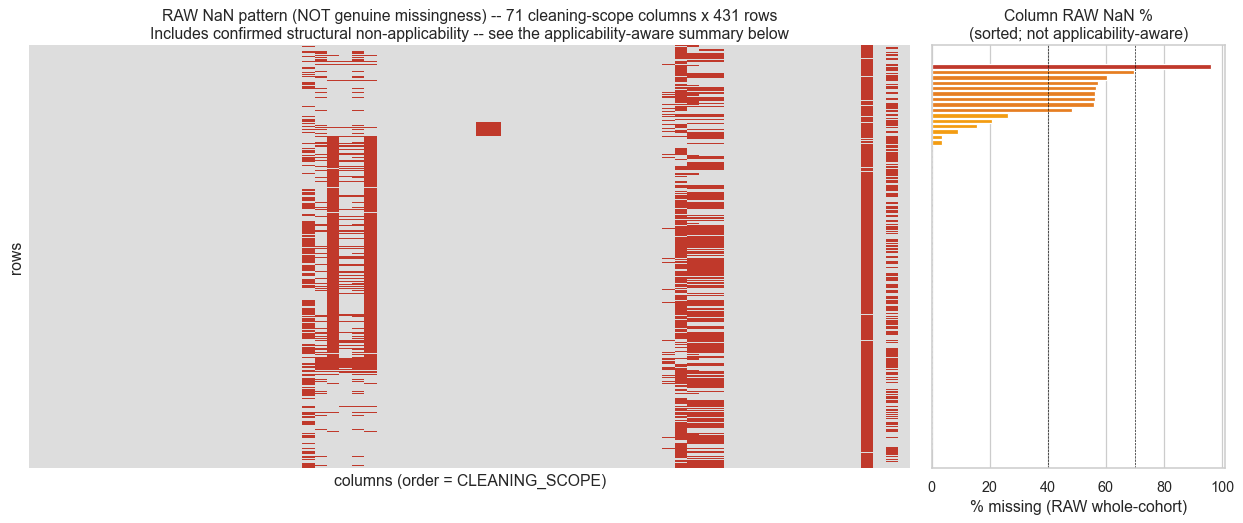

RAW NaN visualization (cleaning scope, at this point in the pipeline) -- raw whole-
cohort NaN presence, NOT genuine missingness: includes confirmed structural non-
applicability (e.g. endometrioma_size_clean NaN for endometrioma==0). See the
Section B4 column-level missingness log (clean-b-s04-column) for the genuine-vs-raw
split per column, and the Section B4 row-level cell (clean-b-s04-row) for the genuine
row-level denominator used below.
  Columns with 0% RAW missing    : 56
  Columns with <40% RAW missing  : 6
  Columns with 40-70% RAW missing: 8
  Columns with >=70% RAW missing : 1

  Max row missingness (applicability-aware, matches Section B4 row-level cell): 11.6%
  Rows > 10% missing (applicability-aware, matches Section B4 row-level cell): 7
  Rows > 25% missing (applicability-aware, matches Section B4 row-level cell): 0
  Rows > 50% missing (applicability-aware, matches Section B4 row-level cell): 0

  [RAW diagnostic only, not used in any recommendation] Max row RAW NaN %

In [14]:
# ── Broad missingness review: matrix/heatmap + row/column summaries ───────────
# The heatmap and per-column bar chart below are a RAW NaN visualization only:
# they include confirmed structural non-applicability (STRUCTURAL_NAN_COLS),
# which is not genuine data-quality missingness and must not be read as a
# missingness burden. Every scientific row-level statistic in this cell reuses
# the same applicability-aware _row_missing_frac computed in the Section B4
# row-level cell (clean-b-s04-row); a raw figure, where kept for audit
# curiosity, is explicitly labeled RAW and never substituted for the genuine
# metric.
_miss_matrix = df_clean[CLEANING_SCOPE].isna()

_fig, _axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [3, 1]})

sns.heatmap(_miss_matrix, cbar=False, yticklabels=False, xticklabels=False,
            cmap=["#dddddd", "#c0392b"], ax=_axes[0])
_axes[0].set_title(
    f"RAW NaN pattern (NOT genuine missingness) -- {len(CLEANING_SCOPE)} cleaning-scope "
    f"columns x {len(df_clean)} rows\nIncludes confirmed structural non-applicability -- "
    "see the applicability-aware summary below"
)
_axes[0].set_xlabel("columns (order = CLEANING_SCOPE)")
_axes[0].set_ylabel("rows")

_col_miss_pct = (_miss_matrix.mean() * 100).sort_values(ascending=True)
_colors = ["#2ecc71" if v == 0 else ("#f39c12" if v < 40 else ("#e67e22" if v < 70 else "#c0392b"))
           for v in _col_miss_pct.values]
_axes[1].barh(range(len(_col_miss_pct)), _col_miss_pct.values, color=_colors)
_axes[1].set_yticks([])
_axes[1].set_xlabel("% missing (RAW whole-cohort)")
_axes[1].set_title("Column RAW NaN %\n(sorted; not applicability-aware)")
_axes[1].axvline(40, color="black", linewidth=0.5, linestyle="--")
_axes[1].axvline(70, color="black", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

print("RAW NaN visualization (cleaning scope, at this point in the pipeline) -- raw whole-")
print("cohort NaN presence, NOT genuine missingness: includes confirmed structural non-")
print("applicability (e.g. endometrioma_size_clean NaN for endometrioma==0). See the")
print("Section B4 column-level missingness log (clean-b-s04-column) for the genuine-vs-raw")
print("split per column, and the Section B4 row-level cell (clean-b-s04-row) for the genuine")
print("row-level denominator used below.")
print(f"  Columns with 0% RAW missing    : {int((_col_miss_pct==0).sum())}")
print(f"  Columns with <40% RAW missing  : {int(((_col_miss_pct>0)&(_col_miss_pct<40)).sum())}")
print(f"  Columns with 40-70% RAW missing: {int(((_col_miss_pct>=40)&(_col_miss_pct<70)).sum())}")
print(f"  Columns with >=70% RAW missing : {int((_col_miss_pct>=70).sum())}")

# ── Scientific row-level missingness summary: SAME applicability-aware ───────
# metric as the Section B4 row-level cell (clean-b-s04-row, _row_missing_frac) -- never an independently recomputed
# blanket _miss_matrix.mean(axis=1) figure used as the scientific decision
# metric.
print(f"\n  Max row missingness (applicability-aware, matches Section B4 row-level cell): "
      f"{round(float(_row_missing_frac.max())*100, 1)}%")
for _thr in [0.10, 0.25, 0.50]:
    _n_thr = int((_row_missing_frac > _thr).sum())
    print(f"  Rows > {int(_thr*100)}% missing (applicability-aware, matches Section B4 row-level cell): {_n_thr}")

# RAW row-missingness figure retained ONLY as a labeled audit-curiosity
# diagnostic -- never used in any recommendation.
_row_miss_pct_RAW_DIAGNOSTIC_ONLY = _miss_matrix.mean(axis=1) * 100
print(f"\n  [RAW diagnostic only, not used in any recommendation] Max row RAW NaN %: "
      f"{round(float(_row_miss_pct_RAW_DIAGNOSTIC_ONLY.max()),1)}%")
print(f"  [RAW diagnostic only, not used in any recommendation] Rows >50% RAW NaN: "
      f"{int((_row_miss_pct_RAW_DIAGNOSTIC_ONLY>50).sum())}")

# Missingness by classification group. The group mean below is RAW
# whole-cohort NaN prevalence (it includes structural non-applicability); an
# applicability-aware GENUINE-missingness-by-group summary follows immediately,
# reusing genuine_missing_within_applicable_pct from the Section B4 column-level
# log.
_group_of = {
    _c: (
        "predictor_allowed" if _c in PREDICTOR_ALLOWED_COLS
        else "secondary_near_delivery_predictor" if _c in SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS
        else "intrapartum_predictor_exclude_from_prelabor_model" if _c in INTRAPARTUM_PREDICTOR_EXCLUDE_COLS
        else "intrapartum_candidate_pending_timing_confirmation"
    )
    for _c in CLEANING_SCOPE
}
_group_series = pd.Series(_group_of)
_by_group_raw = pd.DataFrame({
    "raw_missing_%": _col_miss_pct,
    "group": _group_series.reindex(_col_miss_pct.index),
})
print("\n  Mean column RAW NaN % by classification group (whole-cohort prevalence; includes "
      "structural non-applicability -- see genuine-missingness table below):")
print(_by_group_raw.groupby("group")["raw_missing_%"].mean().round(1).to_string())

_genuine_pct_by_col = {r["column"]: r["genuine_missing_within_applicable_pct"] for r in missingness_log}
_by_group_genuine = pd.DataFrame({
    "genuine_missing_within_applicable_%": pd.Series(_genuine_pct_by_col).reindex(_col_miss_pct.index),
    "group": _group_series.reindex(_col_miss_pct.index),
})
print("\n  Mean GENUINE within-applicable missingness % by classification group "
      "(applicability-aware; preferred for data-quality interpretation, from the Section B4 column-level log):")
print(_by_group_genuine.groupby("group")["genuine_missing_within_applicable_%"].mean().round(1).to_string())

# ── Subgroup applicability report ──────────────────────────────────────────
# adhesions, surgical_site_infection, etc. are outside CLEANING_SCOPE and are
# never touched by the missingness handling above. Reported here separately,
# using SUBGROUP_APPLICABLE_COLS (Section B1), with each entry's own subgroup
# denominator (not the full-cohort denominator, and not as ordinary
# missingness). Most entries use the cesarean subgroup; age_at_neonatal_death
# uses the neonatal_death==1 subgroup -- the mask is looked up per entry by
# subgroup_label.
#
# Small-cell disclosure protection: a subgroup with a protected small
# denominator (e.g. neonatal_death==1, n=1) never has its raw within-subgroup
# value distribution printed. Reuses the shared small-cell convention
# (analysis/eda/notebook_build/eda_shared/share_safe.py,
# DEFAULT_DISCLOSURE_THRESHOLD=5). The internal null-check on non-applicable
# rows is unaffected -- only the raw value distribution is suppressed.
_ss_spec = importlib.util.spec_from_file_location(
    "share_safe", _root / "analysis" / "eda" / "notebook_build" / "eda_shared" / "share_safe.py",
)
share_safe = importlib.util.module_from_spec(_ss_spec)
_ss_spec.loader.exec_module(share_safe)
_SMALL_CELL_THRESHOLD = share_safe.DEFAULT_DISCLOSURE_THRESHOLD

print("\n  Subgroup applicability report (not part of CLEANING_SCOPE):")
_subgroup_masks_report = {
    "intrapartum_cesarean": df["type_of_CS"].isin([2, 3]),
    "neonatal_death": df["neonatal_death"] == 1,
}
for _sg_col, _sg_meta in SUBGROUP_APPLICABLE_COLS.items():
    _sg_label_report = _sg_meta["subgroup_label"]
    _sg_mask_report = _subgroup_masks_report[_sg_label_report]
    _n_sg_report = int(_sg_mask_report.sum())
    _sg_n_outside_non_null = int(df.loc[~_sg_mask_report, _sg_col].notna().sum())
    if 0 < _n_sg_report < _SMALL_CELL_THRESHOLD:
        _sg_display = (
            f"protected small subgroup (n={_n_sg_report}<{_SMALL_CELL_THRESHOLD}); raw value "
            "distribution suppressed for disclosure protection"
        )
    else:
        _sg_display = df.loc[_sg_mask_report, _sg_col].value_counts(dropna=False).to_dict()
    print(f"    {_sg_col}: subgroup={_sg_label_report} "
          f"(denominator n={_n_sg_report}, expected {_sg_meta['expected_applicable_denominator']}) "
          f"-> within-subgroup counts={_sg_display} | "
          f"non-subgroup non-null (expected 0, structural not ordinary missing)={_sg_n_outside_non_null}")

## Section B4d — Missingness-Mechanism Screen

For each scope column with missingness, its missingness indicator is tested for
association against a small, defensible reference-variable set chosen by a
**deterministic, per-variable, horizon-tiered selection rule** — near-complete
(< 5% missing) `CLEANING_SCOPE` variables only, capped per type, in
`CLEANING_SCOPE` order. This is a rule that selects among eligible variables
each run, not a hardcoded list of names.

**Horizon tiering.** The reference-eligible pool is not one fixed set shared by
every screened column. A screened column's own predictor-classification stage
bounds which reference variables may explain *its* missingness, matching the
cumulative modeling-horizon contract: a Stage-1 (`predictor_allowed`) column's
screen uses Stage-1 references only; a Stage-2
(`secondary_near_delivery_predictor`) column's screen uses Stage 1+2
references; a Stage-3 (`intrapartum_predictor_exclude_from_prelabor_model`)
column's screen uses Stage 1+2+3 references. A column that is never a predictor
at any stage (e.g. `leakage_exclude`, `intrapartum_or_post_delivery_exclude`,
`source_or_text_audit_exclude`) has no earlier-stage model to protect and draws
from the full pool for its descriptive screen. `intrapartum_or_post_delivery_exclude`
columns and the target are never reference-eligible at any tier. Tiering — not a
name-specific ban — is what prevents a later-horizon variable from leaking into
an earlier-horizon screen. The mechanism labels are **descriptive screening
labels only**:

- **no strong evidence of association with the tested observed variables**
- **missingness associated with observed variables; MCAR unlikely / compatible with MAR**
- **structural / subgroup missingness (confirmed code-enforced gate); MCAR/MAR
  mechanism inference not applicable; variable-specific handling documented
  separately** — this label does **not** by itself mean the variable has an
  open clinical-review decision; each variable's specific status is documented
  in its own Section B5-family paragraph.

### Tests
- Indicator vs. each **continuous** reference variable: **Kolmogorov–Smirnov** (two-sample)
- Indicator vs. each **categorical/binary** reference variable: **chi-square**, or
  **Fisher exact** for sparse 2×2 tables (any expected cell count <5)
- For a categorical/binary reference variable with more than 2 levels (a
  contingency table larger than 2×2), sparse expected counts can still make
  the asymptotic chi-square test unreliable even though Fisher's exact test is
  not used for tables of that shape here. A conservative, documented rule
  (more than 20% of cells with expected count <5, or any cell with expected
  count <1) is applied: if materially violated, that specific test is
  **skipped** (`skipped_sparse_contingency_table`) rather than reporting an
  unsupported asymptotic p-value. No category collapsing or Monte-Carlo/exact
  test is introduced to force a result. Skipped tests are excluded from that
  column's BH-FDR family.
- Where a missing variable is tested against more than one reference variable,
  **Benjamini–Hochberg FDR** correction is applied across that variable's own
  *valid* test family (never including skipped tests) before deciding
  significance (q<0.05), so a large number of raw p-values is not misread as
  independent evidence.

### Confirmed-structural and row-specific applicability gated variables
`gestational_age_at_PPROM_days` and `indication_for_induction_clean` (row-
specific applicability gated) and the confirmed-structural columns in
`STRUCTURAL_NAN_COLS` (`endometrioma_size_clean`, `endometrioma_place_clean`,
`endometrioma_laterality`, `endo_surgery_adhesiolysis`) are all tested within
their own applicable subset only (e.g. `PPROM==1`, `induction_any_bin==1`,
`endometrioma==1`, `endometriosis_surgery==1`) — not-applicable rows are
excluded from the test entirely, never counted as "present" or "missing".
Below 5 applicable-missing cases, no test is run; the result is reported as
`"insufficient applicable missing cases for a meaningful mechanism test"`
rather than an unstable p-value. `endo_surgery_adhesiolysis` currently has
zero genuinely missing applicable cases and therefore receives no mechanism
test.

### No target / outcome diagnostic is computed here
This section does **not** compute, report, or store any missingness-vs-target
association. Data Cleaning B is a target-blind cleaning stage: `TARGET_COL` is
never read in Section B2 (extreme-value audit) or Section B4/B4d (missingness
assessment). The mechanism label depends **only** on KS / chi-square / Fisher
tests against safe observed reference variables from the screened column's own
horizon-stage pool, BH-FDR corrected per column. Any outcome-aware sensitivity
analysis, if ever wanted, belongs downstream in modeling.

### Critical interpretation rule
These tests do **not** prove MCAR, MAR, or MNAR. A significant association after
FDR correction means missingness is associated with the observed variables
tested here — evidence against MCAR, potentially compatible with MAR — **never**
evidence of MNAR. MNAR concerns dependence on values that are themselves
unobserved and cannot be established from observed-data association tests
alone. Results here are intended to guide manual review and later modeling
decisions; any actual missing-value handling decision requires clinical/
statistical approval before implementation.

In [15]:
# ── Sparse contingency-table rule ───────────────────────────────────────────
# Conventional (Cochran's) rule for asymptotic chi-square reliability: no more
# than 20% of cells may have expected count <5, and no cell may have expected
# count <1. Documented here explicitly rather than left implicit -- applies
# only to tables LARGER than 2x2 (2x2 tables already fall back to Fisher's
# exact test below whenever any expected cell count is <5, so they never reach
# this rule).
_SPARSE_MAX_FRACTION_LOW_EXPECTED = 0.20
_SPARSE_MIN_EXPECTED_ABSOLUTE = 1.0
_SPARSE_LOW_EXPECTED_THRESHOLD = 5.0


def _expected_counts_acceptable(table):
    expected = stats.chi2_contingency(table, correction=False)[3]
    n_cells = expected.size
    n_low = int((expected < _SPARSE_LOW_EXPECTED_THRESHOLD).sum())
    n_below_min = int((expected < _SPARSE_MIN_EXPECTED_ABSOLUTE).sum())
    return (n_low / n_cells) <= _SPARSE_MAX_FRACTION_LOW_EXPECTED and n_below_min == 0


def _chi2_or_fisher(indicator, categorical_var):
    # Returns (p_value_or_None, status). status is one of:
    #   'chi2'    -- valid chi-square test performed
    #   'fisher'  -- valid Fisher exact test performed (sparse 2x2 only)
    #   'skipped_sparse_contingency_table' -- table >2x2 with materially
    #        violated expected-count assumptions; NOT reported as an
    #        unsupported asymptotic p-value, and excluded from BH-FDR
    #   'not_testable' -- fewer than 2 observed levels in the indicator or the
    #        reference variable after pairwise-complete dropna; not a sparse
    #        table, simply not enough variation to test at all
    pair = pd.DataFrame({"ind": indicator, "v": categorical_var}).dropna()
    if pair["ind"].nunique() < 2 or pair["v"].nunique() < 2:
        return None, "not_testable"
    table = pd.crosstab(pair["ind"], pair["v"])
    if table.shape == (2, 2):
        if (stats.chi2_contingency(table, correction=False)[3] < 5).any():
            _, p = stats.fisher_exact(table)
            return float(p), "fisher"
        _, p, _, _ = stats.chi2_contingency(table, correction=False)
        return float(p), "chi2"
    # Larger than 2x2: do not silently accept an unreliable asymptotic
    # chi-square result. No category collapsing and no Monte-Carlo/exact-test
    # dependency is introduced here -- the test is skipped and the reason is
    # recorded instead.
    if not _expected_counts_acceptable(table):
        return None, "skipped_sparse_contingency_table"
    _, p, _, _ = stats.chi2_contingency(table, correction=False)
    return float(p), "chi2"


def _ks_test(indicator, continuous_var):
    grp_missing = continuous_var[indicator == 1].dropna()
    grp_present = continuous_var[indicator == 0].dropna()
    if len(grp_missing) < 5 or len(grp_present) < 5:
        return None, "not_testable"
    _, p = stats.ks_2samp(grp_missing, grp_present)
    return float(p), "ks"


def _bh_fdr(pvals):
    # Standard Benjamini-Hochberg FDR correction (step-up), returned in the
    # same order as the input p-values. No extra dependency required.
    m = len(pvals)
    if m == 0:
        return []
    ranked = sorted(range(m), key=lambda i: pvals[i])  # ascending p-value order
    q = [0.0] * m
    running_min = 1.0
    for rank in range(m, 0, -1):
        idx = ranked[rank - 1]
        adj = pvals[idx] * m / rank
        running_min = min(running_min, adj)
        q[idx] = running_min
    return q


# ── Defensible reference-variable SELECTION RULE (not a literal fixed list) ───
# Near-complete (<5% missing themselves) clinical/predictor variables, in
# deterministic (CLEANING_SCOPE) order, capped to keep each missing-variable's
# own test family small and interpretable rather than testing against dozens
# of columns. This is a RULE that selects among currently-eligible
# CLEANING_SCOPE variables each run -- not a single hardcoded named list.
_MAX_REFERENCE_VARS_PER_TYPE = 3
_MECHANISM_REF_MAX_MISSING = 0.05

# ── Per-variable horizon tiers ─────────────────────────────────────────────
# Mirrors modeling_core.py's HORIZON_ALLOWED_CLASSIFICATIONS cumulative
# contract exactly: Stage 1 = predictor_allowed; Stage 2 = Stage 1 +
# secondary_near_delivery_predictor; Stage 3 = Stage 2 +
# intrapartum_predictor_exclude_from_prelabor_model. intrapartum_or_post_delivery_exclude
# columns and the target are never reference-eligible at any tier.
HORIZON_STAGE1_COLS = set(PREDICTOR_ALLOWED_COLS)
HORIZON_STAGE2_COLS = HORIZON_STAGE1_COLS | set(SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS)
HORIZON_STAGE3_COLS = HORIZON_STAGE2_COLS | set(INTRAPARTUM_PREDICTOR_EXCLUDE_COLS)


def _reference_eligible_cols_for(col):
    # A screened column's OWN stage bounds which reference variables may be
    # used to explain its missingness -- a Stage-1 variable's screen must
    # never be informed by a Stage-2/Stage-3 reference. A column with no
    # horizon-tier classification at all (never a predictor at any stage) has
    # no earlier-stage predictor model to protect, so it gets the full
    # Stage-1+2+3 pool for its descriptive/audit screen.
    if col in PREDICTOR_ALLOWED_COLS:
        return HORIZON_STAGE1_COLS
    if col in SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS:
        return HORIZON_STAGE2_COLS
    if col in INTRAPARTUM_PREDICTOR_EXCLUDE_COLS:
        return HORIZON_STAGE3_COLS
    return HORIZON_STAGE3_COLS


# Near-complete numeric/categorical CLEANING_SCOPE columns, in deterministic
# order, WITHOUT any stage filtering yet -- stage filtering is applied
# per-screened-column below via _reference_eligible_cols_for, not once
# globally, so the same candidate list can serve every horizon tier correctly.
_ALL_CONTINUOUS_REF_CANDIDATES = [
    c for c in CLEANING_SCOPE
    if infer_var_type(df_clean[c]) == "numeric"
    and df_clean[c].isna().mean() < _MECHANISM_REF_MAX_MISSING
]
_ALL_CATEGORICAL_REF_CANDIDATES = [
    c for c in CLEANING_SCOPE
    if infer_var_type(df_clean[c]) in ("binary", "categorical")
    and df_clean[c].isna().mean() < _MECHANISM_REF_MAX_MISSING
]


def _reference_vars_for(col):
    _eligible = _reference_eligible_cols_for(col)
    _cont = [c for c in _ALL_CONTINUOUS_REF_CANDIDATES if c in _eligible and c != col][:_MAX_REFERENCE_VARS_PER_TYPE]
    _cat = [c for c in _ALL_CATEGORICAL_REF_CANDIDATES if c in _eligible and c != col][:_MAX_REFERENCE_VARS_PER_TYPE]
    return _cont, _cat

# Row-specific applicability gated variables (gestational_age_at_PPROM_days,
# indication_for_induction_clean) AND confirmed-structural variables
# (STRUCTURAL_NAN_COLS: endometrioma_size_clean/place_clean/laterality,
# endo_surgery_adhesiolysis) are tested against this reference set only within
# their own applicable subset -- never the whole cohort, and never with
# not-applicable rows counted as either "missing" or "present". Both tiers
# share the SAME unified gate lookup already built in the Section B4 row-level cell (clean-b-s04-row; Section B4's
# row-level cell, `_all_row_applicability_gates`) instead of a second,
# independently-maintained applicability calculation. Below this many
# applicable-missing cases, an inferential test would be unstable and
# misleading, so testing is skipped and reported explicitly instead.
_MIN_APPLICABLE_MISSING_FOR_TESTING = 5

print("Reference-variable pools are per-screened-column and horizon-tiered "
      "-- see _reference_vars_for(col); the pool differs by the screened "
      f"column's own stage. Stage-1 pool size={len(HORIZON_STAGE1_COLS)}, "
      f"Stage-2 pool size={len(HORIZON_STAGE2_COLS)}, Stage-3 pool size={len(HORIZON_STAGE3_COLS)}.")

# ── Honest test-count tally ──────────────────────────────────────────────────
_test_tally = {
    "attempted": 0, "valid_chi2_or_ks": 0,
    "skipped_sparse_contingency_table": 0, "skipped_not_testable": 0,
}

mechanism_rows = []
mechanism_detail_rows = []  # audit-only: every individual test performed, kept for the CSV export
for col in CLEANING_SCOPE:
    if col not in df_clean.columns:
        continue

    # Unified applicability gate lookup: reuses the same
    # _all_row_applicability_gates built in the Section B4 row-level cell
    # (clean-b-s04-row) -- ROW_APPLICABILITY_GATES (PPROM/induction) unioned
    # with the confirmed-structural columns' gates from the shared
    # structural_missingness_registry. This is the one consistent applicability
    # mechanism used for both the row-specific-gated and the
    # confirmed-structural tiers.
    _is_gated = col in _all_row_applicability_gates
    if _is_gated:
        # Applicability gate (row-specific OR confirmed-structural): mechanism
        # testing concerns ONLY the applicable subset (gate condition holds)
        # and the genuinely missing applicable cases -- not-applicable rows
        # are excluded entirely, not counted as "present" or "missing".
        _gate = _all_row_applicability_gates[col]
        _applicable_mask_col = df_clean[_gate["gate_column"]] == _gate["applicable_value"]
        _test_df = df_clean.loc[_applicable_mask_col]
        _n_applicable = int(_applicable_mask_col.sum())
        _n_applicable_missing = int(_test_df[col].isna().sum())
        miss_pct = round(_n_applicable_missing / _n_applicable * 100, 1) if _n_applicable else 0.0
        if _n_applicable_missing < _MIN_APPLICABLE_MISSING_FOR_TESTING:
            mechanism_rows.append({
                "column": col,
                "missing_%": miss_pct,
                "n_observed_variable_tests": 0,
                "n_significant_after_fdr": 0,
                "mechanism_heuristic": (
                    "insufficient applicable missing cases for a meaningful mechanism test "
                    f"(applicable_missing_n={_n_applicable_missing}, applicable_n={_n_applicable}, "
                    f"gate={_gate['gate_column']}=={_gate['applicable_value']})"
                ),
                "reference_vars_used": "(not computed - insufficient applicable cases)",
            })
            continue
        indicator = _test_df[col].isna().astype(int)
    else:
        miss_pct = float(df_clean[col].isna().mean() * 100)
        if miss_pct == 0:
            continue
        indicator = df_clean[col].isna().astype(int)
        _test_df = df_clean

    # No target / outcome diagnostic is computed here -- Data Cleaning B never
    # reads TARGET_COL in this section. The mechanism label below depends only
    # on the safe observed reference variables selected next.

    # Per-column, horizon-tiered reference pool: computed fresh for THIS
    # screened column's own stage, not a single global pool shared by every
    # column. The horizon-stage pools (HORIZON_STAGE1/2/3_COLS) are
    # classification-derived predictor sets and structurally never contain the
    # outcome column.
    _col_continuous_refs, _col_categorical_refs = _reference_vars_for(col)
    assert not (set(_col_continuous_refs) | set(_col_categorical_refs)) & set(INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS), (
        f"Horizon-safety violation: an intrapartum_or_post_delivery_exclude column was "
        f"selected as a reference for {col!r}."
    )
    if col in PREDICTOR_ALLOWED_COLS:
        assert not (set(_col_continuous_refs) | set(_col_categorical_refs)) - HORIZON_STAGE1_COLS, (
            f"Horizon-safety violation: Stage-1 column {col!r}'s screen selected a "
            "later-horizon reference variable."
        )
    elif col in SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS:
        assert not (set(_col_continuous_refs) | set(_col_categorical_refs)) - HORIZON_STAGE2_COLS, (
            f"Horizon-safety violation: Stage-2 column {col!r}'s screen selected a "
            "Stage-3 reference variable."
        )

    _test_pvals, _test_labels = [], []
    for _ref in _col_continuous_refs:
        if _ref == col:
            continue
        _test_tally["attempted"] += 1
        p, _status = _ks_test(indicator, _test_df[_ref])
        if _status == "ks":
            _test_tally["valid_chi2_or_ks"] += 1
            _test_pvals.append(p); _test_labels.append(f"KS_vs_{_ref}")
            mechanism_detail_rows.append({
                "column": col, "test": f"KS_vs_{_ref}", "status": _status, "p_value": round(p, 4),
            })
        else:
            _test_tally["skipped_not_testable"] += 1
            mechanism_detail_rows.append({
                "column": col, "test": f"KS_vs_{_ref}", "status": _status, "p_value": None,
            })
    for _ref in _col_categorical_refs:
        if _ref == col:
            continue
        _test_tally["attempted"] += 1
        p, _status = _chi2_or_fisher(indicator, _test_df[_ref])
        if _status in ("chi2", "fisher"):
            _test_tally["valid_chi2_or_ks"] += 1
            _test_pvals.append(p); _test_labels.append(f"{_status}_vs_{_ref}")
            mechanism_detail_rows.append({
                "column": col, "test": f"chi2_or_fisher_vs_{_ref}", "status": _status, "p_value": round(p, 4),
            })
        elif _status == "skipped_sparse_contingency_table":
            _test_tally["skipped_sparse_contingency_table"] += 1
            mechanism_detail_rows.append({
                "column": col, "test": f"chi2_or_fisher_vs_{_ref}", "status": _status, "p_value": None,
            })
        else:  # not_testable
            _test_tally["skipped_not_testable"] += 1
            mechanism_detail_rows.append({
                "column": col, "test": f"chi2_or_fisher_vs_{_ref}", "status": _status, "p_value": None,
            })

    if not _test_pvals:
        mechanism = "review (not testable against the reference variable set)"
        n_sig_fdr = 0
    else:
        _qvals = _bh_fdr(_test_pvals)
        n_sig_fdr = sum(q < 0.05 for q in _qvals)
        mechanism = (
            "missingness associated with observed variables; MCAR unlikely / compatible with MAR"
            if n_sig_fdr > 0
            else "no strong evidence of association with the tested observed variables"
        )

    # Structural override applies to CONFIRMED structural columns only, never
    # the pending tier. APPLICABILITY_LINKED_NO_PREPROCESSING_MASK columns get their real
    # computed mechanism label above and are annotated (not relabeled) as
    # row-applicability gated -- a provenance annotation meaning no
    # code-enforced preprocessing gate exists, not a statement about whether
    # the variable's handling is resolved (each variable's own status is in its
    # Section B5-family paragraph).
    if col in STRUCTURAL_NAN_COLS:
        # A confirmed code-enforced gate means MCAR/MAR mechanism inference is
        # not applicable (the gate, not chance, explains the NaN pattern). It
        # says nothing about whether that variable's handling is resolved --
        # see its Section B5-family paragraph.
        mechanism = (
            "structural/subgroup missingness (confirmed code-enforced gate); "
            "MCAR/MAR mechanism inference not applicable; variable-specific "
            "handling documented separately"
        )
    elif col in APPLICABILITY_LINKED_NO_PREPROCESSING_MASK_COLS:
        mechanism = mechanism + (
            " (empirically row-applicability gated; no preprocessing-enforced "
            "mask -- see Section B4 header for this variable's specific "
            "applicability/handling status)"
        )

    mechanism_rows.append({
        "column": col,
        "missing_%": round(miss_pct, 1),
        "n_observed_variable_tests": len(_test_pvals),
        "n_significant_after_fdr": n_sig_fdr,
        "mechanism_heuristic": mechanism,
        "reference_vars_used": ", ".join(_col_continuous_refs + _col_categorical_refs) or "(none)",
    })

mechanism_df = pd.DataFrame(mechanism_rows).sort_values("missing_%", ascending=False) \
    if mechanism_rows else pd.DataFrame()
mechanism_detail_df = pd.DataFrame(mechanism_detail_rows) if mechanism_detail_rows else pd.DataFrame()
print("\nMissingness mechanism assessment (per-column horizon-tiered reference pools, "
      "up to 3 continuous + 3 categorical reference variable(s) each, BH-FDR corrected per column):")
if len(mechanism_df):
    print(mechanism_df.to_string(index=False))
    # attach mechanism back into the missingness log for export
    _mech_map = dict(zip(mechanism_df["column"], mechanism_df["mechanism_heuristic"]))
    for row in missingness_log:
        row["mechanism_heuristic"] = _mech_map.get(row["column"], "n/a (no missing)")
else:
    print("  No columns with missingness in scope.")
print("\nCRITICAL: a significant association after FDR correction means missingness is")
print("associated with observed variables (MCAR unlikely / compatible with MAR) -- it does NOT")
print("establish MNAR, which concerns dependence on unobserved values and cannot be shown by")
print("these tests. No target/outcome association is computed in this target-blind cleaning")
print("stage. Heuristic only -- no imputation performed in this section.")

# ── Honest test-count reporting ──────────────────────────────────────────────
# attempted = every KS/chi2-or-fisher call made; valid = a usable p-value was
# produced; the two skip reasons are mutually exclusive and both excluded from
# every column's BH-FDR family above (only _test_pvals entries -- 'valid'
# tests -- ever reach _bh_fdr()).
print(f"\nTest-count summary (all reference-variable tests across all tested columns):")
print(f"  attempted                       : {_test_tally['attempted']}")
print(f"  valid/completed (chi2/fisher/KS) : {_test_tally['valid_chi2_or_ks']}")
print(f"  skipped_sparse_contingency_table : {_test_tally['skipped_sparse_contingency_table']}")
print(f"  skipped_not_testable (<2 levels or insufficient group size) : {_test_tally['skipped_not_testable']}")
assert (
    _test_tally["valid_chi2_or_ks"]
    + _test_tally["skipped_sparse_contingency_table"]
    + _test_tally["skipped_not_testable"]
    == _test_tally["attempted"]
), "Test-count tally does not reconcile -- attempted must equal valid + both skip reasons."

Reference-variable pools are per-screened-column and horizon-tiered -- see _reference_vars_for(col); the pool differs by the screened column's own stage. Stage-1 pool size=60, Stage-2 pool size=66, Stage-3 pool size=71.

Missingness mechanism assessment (per-column horizon-tiered reference pools, up to 3 continuous + 3 categorical reference variable(s) each, BH-FDR corrected per column):
                                column  missing_%  n_observed_variable_tests  n_significant_after_fdr                                                                                                                                                                                                            mechanism_heuristic                            reference_vars_used
                             BMI_after     57.300                          2                        1                                                                                                                                        

In [16]:
# ── Dry-run missingness decision table (documentation only) ──────────────────
# This table records review candidates and allowed actions. It does not apply
# row deletion, column deletion, imputation, new indicators, Unknown levels,
# transformations, target changes, preprocessing changes, or EDA C changes.
# The scientific predictor-scope row-missingness metric reuses the same
# applicability-aware _row_missing_frac from the Section B4 row-level cell
# (clean-b-s04-row) -- not an independently recomputed blanket
# df_clean[...].isna().mean(axis=1) figure.
row_missingness_gt_50_predictor_scope_n = int((_row_missing_frac > 0.50).sum())

# RAW diagnostic only (every df_clean column, including TARGET_COL,
# _row_key_delivery_id, and BMI_after where present) -- retained purely as an
# audit-curiosity figure, explicitly labeled, and NEVER used in
# row_deletion_recommended or any other recommendation field below.
_all_col_missing_frac_RAW_DIAGNOSTIC_ONLY = df_clean.isna().mean(axis=1)
row_missingness_gt_50_all_columns_n_RAW_DIAGNOSTIC_ONLY = int(
    (_all_col_missing_frac_RAW_DIAGNOSTIC_ONLY > 0.50).sum()
)

row_deletion_recommended = False
row_deletion_applied = False

print("Dry-run row-level missingness summary:")
print(f"  row_missingness_gt_50_predictor_scope_n (applicability-aware, matches Section B4 row-level cell) "
      f"= {row_missingness_gt_50_predictor_scope_n}")
print("  [RAW diagnostic only, not used in row_deletion_recommended or any other "
      f"recommendation] row_missingness_gt_50_all_columns_n_RAW = "
      f"{row_missingness_gt_50_all_columns_n_RAW_DIAGNOSTIC_ONLY}")
print(f"  row_deletion_recommended = {row_deletion_recommended}")
print(f"  row_deletion_applied = {row_deletion_applied}")


def _scope_or_role(col):
    if col in STRUCTURAL_NAN_COLS:
        return "structural/subgroup documented (confirmed gate)"
    if col in ROW_APPLICABILITY_GATES:
        return "row-specific applicability gated (empirically confirmed, no code-enforced gate)"
    if col in classification_df.index:
        return str(classification_df.loc[col, "classification"])
    return "cleaning_scope"


def _missingness_band(missing_pct):
    if missing_pct >= 70:
        return ">=70%"
    if missing_pct >= 40:
        return "40%-70%"
    if missing_pct > 0:
        return "<40%"
    return "0%"


def _structural_status(col):
    if col in STRUCTURAL_NAN_COLS:
        return "structural/subgroup documented (confirmed gate)"
    if col in ROW_APPLICABILITY_GATES:
        return "row-specific applicability gated (empirically confirmed, no code-enforced gate)"
    return "not structural based on available metadata"


def _proposed_status(row):
    col = row["column"]
    tier = row["tier"]
    if tier == "structural":
        # A confirmed code-enforced gate is not itself an open clinical decision.
        return (
            "structural/subgroup missingness (confirmed code-enforced gate); "
            "variable-specific handling documented separately"
        )
    if col in ROW_APPLICABILITY_GATES:
        # Each registered gated variable's residual applicable-missing rows have
        # an approved deterministic representation -- variable-specific, not a
        # single generic "pending clinical review".
        if col == "adenomyosis_sonographic_features_clean":
            return (
                "not-applicable rows excluded from the denominator by design; "
                "genuinely missing applicable rows are represented explicitly "
                "by the adenomyosis multi-hot family (adenomyosis_feature_1..11 "
                "+ adenomyosis_features_unknown, Section B5f) -- resolved, not pending"
            )
        if col == "gestational_age_at_PPROM_days":
            return (
                "not-applicable rows excluded from the denominator by design; "
                "genuinely missing applicable rows are represented explicitly by "
                "the fold-safe gestational_age_at_PPROM_days_timing_status "
                "(PPROM_timing_unknown category, Section B5b) -- resolved, not "
                "pending; only the category-cutpoint fitting location is deferred "
                "to modeling"
            )
        if col == "indication_for_induction_clean":
            return (
                "not-applicable rows excluded from the denominator by design; "
                "genuinely missing applicable rows are represented explicitly by "
                "indication_for_induction_status (induction_indication_unknown "
                "category, Section B5h) -- resolved, not pending"
            )
        return (
            "not-applicable rows excluded from the denominator by design; residual "
            "applicable-missing cases pending clinical/partner review before any imputation"
        )
    if tier in [">=70%", "40-70%"]:
        return "manual review before any exclusion/imputation"
    if tier == "<40%":
        return "candidate for later modeling-pipeline handling only after approval"
    return "no missingness action needed"


def _decision_notes(row):
    col = row["column"]
    tier = row["tier"]
    if col in ROW_APPLICABILITY_GATES:
        return (
            "row-specific applicability gate confirmed empirically against the current "
            "cohort (zero rows inconsistent with the gate); tier/missing_% above reflect "
            "the applicable subset only, not the raw whole-cohort % -- counting "
            "not-applicable rows in the denominator would misrepresent this variable; "
            "see Section B4b for the full breakdown"
        )
    if tier == "structural":
        return "structural or subgroup-specific missingness (confirmed gate); keep meaningful NaN unless approved otherwise"
    if tier == "40-70%":
        return "high-intermediate missingness; do not exclude, recode, or impute without manual approval"
    if tier == "<40%":
        return "lower missingness; later modeling-pipeline handling only after approved mechanism review"
    return "no missingness detected"


missingness_decision_rows = []
for _, row in missingness_df.sort_values("missing_%", ascending=False).iterrows():
    tier = row["tier"]
    requires_decision = bool(tier != "0%")
    # Logical classification uses the boolean membership test directly
    # (col in STRUCTURAL_NAN_COLS), never the display-only status string.
    _is_confirmed_structural = bool(row["column"] in STRUCTURAL_NAN_COLS)
    missingness_decision_rows.append({
        "variable": row["column"],
        "missing_n": int(df_clean[row["column"]].isna().sum()) if row["column"] in df_clean.columns else None,
        "missing_pct": row["missing_%"],
        "missingness_band": _missingness_band(row["missing_%"]),
        "variable_scope_or_role": _scope_or_role(row["column"]),
        "structural_or_subgroup_missingness_status": _structural_status(row["column"]),
        "is_confirmed_structural": _is_confirmed_structural,
        "existing_handling": row["recommendation"],
        "proposed_status": _proposed_status(row),
        "action_allowed_now": "documentation only",
        "requires_manual_decision": requires_decision,
        "notes": _decision_notes(row),
    })

missingness_decision_df = pd.DataFrame(missingness_decision_rows)
_decision_view = missingness_decision_df[missingness_decision_df["requires_manual_decision"]]
print("\nDry-run missingness decision table (documentation only):")
if len(_decision_view):
    _n_structural = int(_decision_view["is_confirmed_structural"].sum())
    _gated_cols_present = [c for c in ROW_APPLICABILITY_GATES if c in _decision_view["variable"].values]
    print(f"  {len(_decision_view)} scope column(s) have any missingness (missing_% > 0): "
          f"{_n_structural} confirmed structural/subgroup, {len(_gated_cols_present)} "
          "row-applicability-gated with an approved deterministic representation, "
          f"{len(_decision_view) - _n_structural - len(_gated_cols_present)} other.")
    print(
        "  Variable-specific final treatments are documented in Sections B5-B6. The "
        "decision-support table above is retained in memory (missingness_decision_df) "
        "for auditability; no unresolved Data Cleaning B treatment decision is implied "
        "by this display."
    )
    if _gated_cols_present:
        _final_location = {
            "adenomyosis_sonographic_features_clean":
                "adenomyosis_feature_1..11 + adenomyosis_features_unknown (Section B5f)",
            "gestational_age_at_PPROM_days":
                "gestational_age_at_PPROM_days_timing_status (Section B5b)",
            "indication_for_induction_clean":
                "indication_for_induction_status (Section B5h)",
        }
        _gated_table = pd.DataFrame({
            "variable": _gated_cols_present,
            "applicable_missingness_status": ["row-applicability gated (confirmed)"] * len(_gated_cols_present),
            "final_B_representation": [_final_location.get(c, "documented in Sections B5-B6") for c in _gated_cols_present],
        })
        print("\n  Row-applicability-gated variables -- final representation:")
        print(_gated_table.to_string(index=False))
else:
    print("  (none -- every scope column is 0% missing or already resolved)")

_structural_summary_df = (
    missingness_decision_df
    .groupby("missingness_band", dropna=False)
    .agg(
        number_of_columns=("variable", "count"),
        number_structural_or_subgroup_documented=("is_confirmed_structural", "sum"),
        column_names=("variable", lambda s: ", ".join(s)),
    )
    .reset_index()
)
_structural_summary_df["number_not_structural_or_unclear"] = (
    _structural_summary_df["number_of_columns"]
    - _structural_summary_df["number_structural_or_subgroup_documented"]
)
_structural_summary_df["percentage_structural_or_subgroup_among_band"] = (
    _structural_summary_df["number_structural_or_subgroup_documented"]
    / _structural_summary_df["number_of_columns"] * 100
).round(1)
print("\nDry-run structural/subgroup missingness summary by band:")
print(_structural_summary_df.to_string(index=False))

missingness_documentation_audit_entry = {
    "issue_type": "missingness_documentation_review",
    "action_taken": "documentation_only",
    "reason": "safer missingness mechanism wording and dry-run decision table; no data changes",
    "rows_removed": 0,
    "columns_removed": 0,
    "values_set_to_na": 0,
    "values_imputed": 0,
    "indicators_created": 0,
    "row_count_changed": False,
    "target_distribution_changed": False,
    "requires_manual_decision_before_data_change": True,
}
print("\nDocumentation-only missingness audit entry:")
print(missingness_documentation_audit_entry)

print("\nNot performed in this task/section:")
print("  no rows were removed")
print("  no columns were removed")
print("  no imputation was performed")
print("  no learned imputation or kNN imputation was performed")
print("  no new missing indicators were created")
print("  no Unknown category was created")
print("  no transformations were applied")
print("  target definition was unchanged")
print("  preprocessing was not modified")
print("  EDA C was not modified")

Dry-run row-level missingness summary:
  row_missingness_gt_50_predictor_scope_n (applicability-aware, matches Section B4 row-level cell) = 0
  [RAW diagnostic only, not used in row_deletion_recommended or any other recommendation] row_missingness_gt_50_all_columns_n_RAW = 0
  row_deletion_recommended = False
  row_deletion_applied = False

Dry-run missingness decision table (documentation only):
  15 scope column(s) have any missingness (missing_% > 0): 4 confirmed structural/subgroup, 3 row-applicability-gated with an approved deterministic representation, 8 other.
  Variable-specific final treatments are documented in Sections B5-B6. The decision-support table above is retained in memory (missingness_decision_df) for auditability; no unresolved Data Cleaning B treatment decision is implied by this display.

  Row-applicability-gated variables -- final representation:
                              variable       applicable_missingness_status                                           

## Section B5a — Binary Type Normalization

Sections B5a–B5h build the final derived / model-facing representations. This
first step applies only **deterministic, value-preserving** type conversion:
a column whose observed values are already a subset of `{0, 1}` is cast to a
clean nullable `Int64` 0/1 dtype.

### Rules
- Only deterministic, safe conversions here — no distribution decision, no
  imputation.
- Missingness-percentage decisions belong to Section B4 alone; this section
  does not recompute or act on a column's missingness percentage.
- Outcome / post-delivery / leakage variables are outside the cleaning scope
  and never touched.
- Skewness and continuous power-transform review are done target-blind in
  Section B3, not here.

Every derived `<col>_cat` / status column created in B5c/B5e/B5f is recorded in
`feature_dictionary`.

In [17]:
# B5a: deterministic binary-dtype normalization only. A column whose observed
# values are already a subset of {0, 1} is cast to a nullable Int64 0/1 dtype
# -- a value-preserving type conversion, not a distribution or transformation
# decision.
binary_normalised = []

for col in list(CLEANING_SCOPE):
    if col not in df_clean.columns:
        continue
    var_type = infer_var_type(df_clean[col])

    # Normalise clean binaries to Int 0/1 (deterministic, safe)
    if var_type == "binary":
        observed = set(df_clean[col].dropna().unique())
        if observed.issubset({0, 1, 0.0, 1.0}):
            df_clean[col] = df_clean[col].astype("Float64").astype("Int64")
            binary_normalised.append(col)
            column_actions_log.append({
                "column": col, "stage": "B5a_type",
                "action": "normalise_binary_int", "detail": "cast to nullable Int64 0/1",
            })

print(f"Binary columns normalised to Int 0/1: {len(binary_normalised)}")
print("Descriptive skew / continuous power-transform review: see Section B3.")

Binary columns normalised to Int 0/1: 49
Descriptive skew / continuous power-transform review: see Section B3.


## Section B5b — Fold-Safe-Deferred Categorical Representations
### (`weight_in_pregnancy`, `BMI_after`, `gestational_age_at_PPROM_days` timing)

For these three variables the modeling representation's category boundaries
are learned from the observed-data distribution (an observed-value tertile
split, or an observed-timing median split). Data Cleaning B closes the
**representation decision** — the category vocabulary, the split concept, and
which raw column it applies to — but does **not** fit the numeric cutpoint.
The `q33` / `q67` / median values are fitted **training-fold-only** by a
fold-safe transformer at modeling time
(`analysis/modeling/final_modeling/modeling_core.py`), never from the full
431-row cohort and never here. (This differs from `endometrioma_size_status`'s
fixed 30 mm clinical cutoff and the adenomyosis structural / lossless
categories, which involve no data-derived cutpoint and are fully materialized
in B — Sections B5c / B5f.)

This section therefore creates **no dataframe columns** for `BMI_after_cat`,
`weight_in_pregnancy_cat`, or the PPROM-timing status. It records a
documented-representation-only `feature_dictionary` entry for each
(`materialized_in_B=False`, `cutpoint_source="fold_safe_training_only"`), and
tags each of the three raw source columns
`model_entry_mode="transform_source_only"` — a raw column may feed its
fold-safe transformer internally but may never independently enter a design
matrix as a plain predictor. EDA C and modeling both enforce this tag.

- **`weight_in_pregnancy`** — kept as a continuous
  `secondary_near_delivery_predictor` in the export, passed through unchanged:
  original NaNs preserved, no median / kNN imputation, no missingness
  indicator. Its missingness is carried by the `not_documented` bucket of the
  fold-safe `weight_in_pregnancy_cat` representation, constructed at modeling
  time, so a standalone binary indicator would be redundant.
- **`BMI_after`** — `secondary_near_delivery_predictor`, carved into `df_clean`
  like any other secondary predictor, passed through unchanged (NaNs
  preserved, no imputation, no indicator).
- **`BMI_after_cat`** (documented representation only) — four nominal
  categories: `low_observed` / `mid_observed` / `high_observed`
  (observed-value tertiles) plus `not_documented`. `BMI_after` is never
  imputed; `not_documented` carries the missingness. One-hot encoded at
  modeling time (never an ordinal integer). Raw `BMI_after` and `BMI_after_cat`
  never co-enter a model because `build_preprocessor()` routes a
  `transform_source_only` column only through its fold-safe transformer.
- **`gestational_age_at_PPROM_days` timing status** (documented representation
  only) — `no_PPROM` (structural, `PPROM==0`), `PPROM_earlier` / `PPROM_later`
  (observed-timing median split within the `PPROM==1` applicable subgroup),
  `PPROM_timing_unknown` (the 1 genuinely missing applicable case). The raw
  binary `PPROM` column stays independently selectable
  (`model_entry_mode="direct"`) but is registered `redundant_with` the timing
  status, so the two are never simultaneously co-selected.
  `gestational_age_at_PPROM_days` itself is `transform_source_only`.

In [18]:
# weight_in_pregnancy_cat, BMI_after_cat, and the PPROM-timing status are
# DOCUMENTED REPRESENTATION ONLY in this section: B decides the category
# vocabulary and which raw column each applies to, but computes no dataframe
# column and no numeric cutpoint. The q33/q67/median values are fitted
# training-fold-only by a fold-safe transformer at modeling time. (Fixed
# clinical thresholds such as endometrioma's 30 mm cutoff, and
# structural/lossless categories such as the adenomyosis multi-hot family,
# involve no cutpoint-fitting question and are fully materialized in B.)
print("B5b: weight_in_pregnancy -- approved representation is fold-safe "
      "observed-value tertiles (low/mid/high_observed + not_documented), "
      "not materialized as a df_clean column here; cutpoints fitted "
      "training-fold-only in modeling. weight_in_pregnancy itself stays "
      "continuous with its original NaNs and gets no standalone missingness "
      "indicator -- the fold-safe categorical's own not_documented bucket "
      "carries that information.")

feature_dictionary.append(new_feature_dictionary_entry(
    new_column="weight_in_pregnancy",
    source_column="weight_in_pregnancy",
    creation_rule=(
        "raw source column, passed through unchanged (no imputation, no formula "
        "completion). May feed the modeling-stage fold-safe weight_in_pregnancy_cat "
        "transformer internally as a transform dependency; must never independently "
        "enter a design matrix as a plain numeric predictor."
    ),
    timing="same_as_source", leakage_status="no", intended_use="review",
    creation_section="B5b", domain="anthropometric", clinical_timing="pregnancy",
    predictor_classification="secondary_near_delivery_predictor", stage="2",
    redundancy_group="weight_in_pregnancy_representation",
    materialized_in_B=True, model_entry_mode="transform_source_only",
))
feature_dictionary.append(new_feature_dictionary_entry(
    new_column="weight_in_pregnancy_cat",
    source_column="weight_in_pregnancy",
    creation_rule=(
        "DOCUMENTED REPRESENTATION ONLY -- not computed as a df_clean column in Data "
        "Cleaning B. B decides: four nominal categories low_observed/mid_observed/"
        "high_observed (observed-value tertiles of weight_in_pregnancy) plus "
        "not_documented for missing rows. The actual q33/q67 cutpoints are fitted "
        "training-fold-only by a fold-safe transformer at modeling time -- never from "
        "the full cohort, never here in B."
    ),
    timing="same_as_source", leakage_status="no", intended_use="review",
    creation_section="B5b", domain="anthropometric", clinical_timing="pregnancy",
    predictor_classification="secondary_near_delivery_predictor", stage="2",
    redundancy_group="weight_in_pregnancy_representation",
    materialized_in_B=False, model_entry_mode="direct",
    cutpoint_source="fold_safe_training_only",
))

# ── BMI_after: NaN preserved, no formula completion ─────────────────────────
# BMI_after is a secondary_near_delivery_predictor carved into df_clean
# (Section B1). This section does not complete it via weight_in_pregnancy /
# height -- that would put derived backfilled values into a raw-named column.
# Logged below for audit-trail parity with the not-imputed entries for
# weight_before_pregnancy / height / Hb_before_delivery in Section B5d.
_n_bmi_after_missing = int(df_clean["BMI_after"].isna().sum())
column_actions_log.append({
    "column": "BMI_after", "stage": "B5b_no_imputation_raw_source",
    "action": "no_imputation_nan_preserved",
    "detail": f"{_n_bmi_after_missing} rows left as NaN (not imputed, not formula-completed)",
    "issue_type": "n/a", "action_taken": "none", "base_variable": "BMI_after",
    "reason": (
        f"BMI_after had {_n_bmi_after_missing} missing "
        f"({round(_n_bmi_after_missing/len(df_clean)*100,1)}%). BMI_after is in "
        "CLEANING_SCOPE as a secondary near-delivery predictor. No "
        "weight_in_pregnancy/height-based deterministic completion is performed. "
        "NaN preserved on the raw "
        "source column; the missingness question is answered for MODELING purposes "
        "by the documented (not materialized) BMI_after_cat representation below, "
        "computed by a fold-safe transformer at modeling time -- the raw column "
        "itself is never imputed and never independently enters a model "
        "(model_entry_mode=transform_source_only). "
        "See docs/clinical_decisions/manual_decisions_log.md."
    ),
    "rows_removed": 0, "row_count_changed": False, "target_distribution_changed": False,
    "imputation_performed": False, "new_indicators_created": 0,
    "unknown_categories_created": 0, "requires_manual_decision_before_reversal": True,
})
feature_dictionary.append(new_feature_dictionary_entry(
    new_column="BMI_after",
    source_column="BMI_after",
    creation_rule=(
        "raw source column, passed through unchanged (no imputation). May feed the "
        "modeling-stage fold-safe BMI_after_cat transformer internally as a transform "
        "dependency; must never independently enter a design matrix as a plain "
        "numeric predictor, nor alongside its mathematical source family "
        "(height, weight_in_pregnancy)."
    ),
    timing="same_as_source", leakage_status="no", intended_use="review",
    creation_section="B5b", domain="anthropometric", clinical_timing="pregnancy",
    predictor_classification="secondary_near_delivery_predictor", stage="2",
    redundancy_group="BMI_after_representation",
    materialized_in_B=True, model_entry_mode="transform_source_only",
))
feature_dictionary.append(new_feature_dictionary_entry(
    new_column="BMI_after_cat",
    source_column="BMI_after",
    creation_rule=(
        "DOCUMENTED REPRESENTATION ONLY -- not computed as a df_clean column in Data "
        "Cleaning B. B decides: four nominal categories low_observed/mid_observed/"
        "high_observed (observed-value tertiles of BMI_after) plus not_documented for "
        "missing rows. The actual q33/q67 cutpoints are fitted training-fold-only by a "
        "fold-safe transformer at modeling time -- never from the full cohort, never "
        "here in B. No imputation of BMI_after is performed anywhere."
    ),
    timing="same_as_source", leakage_status="no", intended_use="review",
    creation_section="B5b", domain="anthropometric", clinical_timing="pregnancy",
    # predictor_classification inherits BMI_after's secondary_near_delivery_
    # predictor timing horizon (Stage 1 ineligible, Stage 2/3 eligible), like
    # the raw source column.
    predictor_classification="secondary_near_delivery_predictor", stage="2",
    redundancy_group="BMI_after_representation",
    materialized_in_B=False, model_entry_mode="direct",
    cutpoint_source="fold_safe_training_only",
))

# ── PPROM timing: documented representation only ────────────────────────────
# gestational_age_at_PPROM_days is applicability-gated (PPROM==1) in Section
# B4/B4d; this entry documents its deferred categorical representation without
# materializing it.
_n_pprom_applicable = int((df_clean["PPROM"] == 1).sum())
_n_pprom_timing_missing_applicable = int(
    df_clean.loc[df_clean["PPROM"] == 1, "gestational_age_at_PPROM_days"].isna().sum()
)
feature_dictionary.append(new_feature_dictionary_entry(
    new_column="gestational_age_at_PPROM_days",
    source_column="gestational_age_at_PPROM_days",
    creation_rule=(
        "raw source column, passed through unchanged (no imputation). May feed the "
        "modeling-stage fold-safe PPROM-timing transformer internally as a transform "
        "dependency (together with the raw binary PPROM gate column); must never "
        "independently enter a design matrix as a plain numeric predictor."
    ),
    timing="same_as_source", leakage_status="no", intended_use="review",
    creation_section="B5b", domain="obstetric", clinical_timing="antepartum",
    predictor_classification="secondary_near_delivery_predictor", stage="2",
    redundancy_group="pprom_timing_representation",
    materialized_in_B=True, model_entry_mode="transform_source_only",
))
feature_dictionary.append(new_feature_dictionary_entry(
    new_column="PPROM",
    source_column="PPROM",
    creation_rule=(
        "raw binary source column, passed through unchanged. Remains independently "
        "selectable as an ordinary predictor on its own clinical merits "
        "(model_entry_mode=direct) -- it is NOT a transform-source-only column. It also "
        "acts as the applicability gate the fold-safe PPROM-timing transformer needs "
        "internally (no_PPROM vs. applicable-subgroup timing) as a dependency, "
        "independent of whether PPROM is itself selected as a feature. Because it is "
        "exactly redundant with the timing representation it gates (no_PPROM already "
        "encodes PPROM==0/1), the two must never be SIMULTANEOUSLY selected together -- "
        "enforced via the pprom_timing_representation redundancy group, not by "
        "forbidding PPROM's independent use altogether."
    ),
    timing="same_as_source", leakage_status="no", intended_use="review",
    creation_section="B5b", domain="obstetric", clinical_timing="antepartum",
    predictor_classification="secondary_near_delivery_predictor", stage="2",
    redundancy_group="pprom_timing_representation",
    materialized_in_B=True, model_entry_mode="direct",
    redundant_with="gestational_age_at_PPROM_days_timing_status",
))
feature_dictionary.append(new_feature_dictionary_entry(
    new_column="gestational_age_at_PPROM_days_timing_status",
    source_column="gestational_age_at_PPROM_days, PPROM",
    creation_rule=(
        "DOCUMENTED REPRESENTATION ONLY -- not computed as a df_clean column in Data "
        "Cleaning B. B decides: four nominal categories -- no_PPROM (structural, "
        "PPROM==0), PPROM_earlier / PPROM_later (observed-timing median split within "
        f"the PPROM==1 applicable subgroup, n_applicable={_n_pprom_applicable}), "
        "PPROM_timing_unknown (genuinely missing applicable timing, "
        f"n={_n_pprom_timing_missing_applicable}). The actual median cutpoint is "
        "fitted training-fold-only by a fold-safe transformer at modeling time -- "
        "never from the full cohort, never here in B, and never derived from "
        "gestational_age_at_delivery_days (Stage-3-only; would leak into this "
        "Stage-2 representation)."
    ),
    timing="same_as_source", leakage_status="no", intended_use="review",
    creation_section="B5b", domain="obstetric", clinical_timing="antepartum",
    predictor_classification="secondary_near_delivery_predictor", stage="2",
    redundancy_group="pprom_timing_representation",
    materialized_in_B=False, model_entry_mode="direct",
    cutpoint_source="fold_safe_training_only",
))
print(f"\nPPROM timing (documented representation only): applicable_n={_n_pprom_applicable}, "
      f"genuinely_missing_applicable_n={_n_pprom_timing_missing_applicable}. "
      "No dataframe column created here; fold-safe transformer computes it at modeling time.")
print("\nB5b complete: weight_in_pregnancy_cat, BMI_after_cat, and "
      "gestational_age_at_PPROM_days_timing_status are all documented-representation-"
      "only entries (materialized_in_B=False) -- no dataframe columns created for any "
      "of them in this notebook.")

B5b: weight_in_pregnancy -- approved representation is fold-safe observed-value tertiles (low/mid/high_observed + not_documented), not materialized as a df_clean column here; cutpoints fitted training-fold-only in modeling. weight_in_pregnancy itself stays continuous with its original NaNs and gets no standalone missingness indicator -- the fold-safe categorical's own not_documented bucket carries that information.

PPROM timing (documented representation only): applicable_n=17, genuinely_missing_applicable_n=1. No dataframe column created here; fold-safe transformer computes it at modeling time.

B5b complete: weight_in_pregnancy_cat, BMI_after_cat, and gestational_age_at_PPROM_days_timing_status are all documented-representation-only entries (materialized_in_B=False) -- no dataframe columns created for any of them in this notebook.


## Section B5c — Endometrioma Size Status + Presence / Laterality

Two deterministic full-cohort categorical phenotype variables are built.
Structural not-applicable coding is applied first (`endometrioma == 0`); within
the `endometrioma == 1` applicable subgroup, genuinely unresolved size or
laterality is kept as an explicit unknown category, **not** full-cohort
imputed — this keeps "not applicable" distinct from "documented endometrioma
with unknown detail". No imputation is performed for either variable.

### endometrioma_size_status
- `no_endometrioma` (structural, `endometrioma == 0`),
  `endometrioma_less_than_30mm`, `endometrioma_30mm_or_more`,
  `endometrioma_size_unknown`.
- Among `endometrioma == 1` rows, documented size is split at the
  clinically-sourced 30 mm cutoff; genuinely unknown / unusable size is the
  explicit `endometrioma_size_unknown` state.

### endometrioma_presence_laterality
- `none`, `unilateral`, `bilateral`, `laterality_unknown`.
- Derived from `endometrioma_laterality`, cross-checked against
  `endometrioma_place_clean` wherever both are present (raises an error on
  disagreement).
- The 5 `endometrioma == 1` rows with genuinely unresolved laterality are the
  explicit `laterality_unknown` category. **The final column has 0 missing
  values** — `laterality_unknown` is a disclosed unknown state, not a guessed
  or imputed value; no full-cohort mode imputation is performed.
- Right vs. left is intentionally collapsed to `unilateral`: no clinical
  hypothesis in this project supports a side-specific effect on intrapartum
  CS risk, and `endometrioma_place_clean` / `endometrioma_laterality` are
  ≈ 0.997 Cramér's V redundant (laterality is a deterministic function of
  place).

### Export
`endometrioma_size_clean`, `endometrioma_place_clean`,
`endometrioma_laterality`, and their `__missing_ind` columns are excluded from
the Batch19 export (Section B7) — superseded by the two derived variables
above. `endometrioma` itself is retained unchanged; the raw detail columns
remain in the preprocessing output.

In [19]:
# -- endometrioma_size_status: structural status + explicit unknown-size state --
_endo = df_clean["endometrioma"]
_size = df_clean["endometrioma_size_clean"]
_place = df_clean["endometrioma_place_clean"]
_lat = df_clean["endometrioma_laterality"]

_n0 = int((_endo == 0).sum())
_n1 = int((_endo == 1).sum())
_size_missing_n1 = int(_size[_endo == 1].isna().sum())
_size_present_n1 = int(_size[_endo == 1].notna().sum())
print("Endometrioma size -- structural status representation:")
print(f"  endometrioma == 0 (structural / not applicable): {_n0}")
print(f"  endometrioma == 1 (applicable subgroup)       : {_n1}")
print(f"  within applicable subgroup, size missing: {_size_missing_n1} "
      f"({round(_size_missing_n1/_n1*100,1)}%)")
print(f"  within applicable subgroup, size present: {_size_present_n1}")
print(f"  explicit unknown-size category: "
      f"{_size_missing_n1}/{len(df_clean)} = {round(_size_missing_n1/len(df_clean)*100,1)}%; "
      "no size imputation is performed.")

SIZE_STATUS_CUTOFF_MM = 30.0
endometrioma_size_status = pd.Series(pd.NA, index=df_clean.index, dtype="string")
endometrioma_size_status[_endo == 0] = "no_endometrioma"
_e1_mask = _endo == 1
endometrioma_size_status[_e1_mask & _size.notna() & (_size < SIZE_STATUS_CUTOFF_MM)] = "endometrioma_less_than_30mm"
endometrioma_size_status[_e1_mask & _size.notna() & (_size >= SIZE_STATUS_CUTOFF_MM)] = "endometrioma_30mm_or_more"
endometrioma_size_status[_e1_mask & _size.isna()] = "endometrioma_size_unknown"
df_clean["endometrioma_size_status"] = endometrioma_size_status

_size_status_allowed = {
    "no_endometrioma",
    "endometrioma_less_than_30mm",
    "endometrioma_30mm_or_more",
    "endometrioma_size_unknown",
}
_counts = df_clean["endometrioma_size_status"].value_counts(dropna=False).to_dict()
_n_missing_status = int(df_clean["endometrioma_size_status"].isna().sum())
if _n_missing_status != 0:
    raise AssertionError(
        f"endometrioma_size_status POSTCONDITION FAILED: expected 0 missing after "
        f"deterministic status construction, got {_n_missing_status}"
    )
if not set(df_clean["endometrioma_size_status"].dropna().unique()).issubset(_size_status_allowed):
    raise AssertionError("endometrioma_size_status POSTCONDITION FAILED: unexpected category label.")
_contradict_no_endo = int(((_endo == 0) & (df_clean["endometrioma_size_status"] != "no_endometrioma")).sum())
if _contradict_no_endo != 0:
    raise AssertionError(
        f"endometrioma_size_status POSTCONDITION FAILED: {_contradict_no_endo} no-endometrioma "
        "row(s) received a known/unknown endometrioma-size category."
    )
print("\nendometrioma_size_status finalized "
      "(no_endometrioma, endometrioma_less_than_30mm, endometrioma_30mm_or_more, "
      f"endometrioma_size_unknown; no size imputation). Counts: {_counts}")

feature_dictionary.append(new_feature_dictionary_entry(
    new_column="endometrioma_size_status",
    source_column="endometrioma, endometrioma_size_clean",
    creation_rule=(
        "categorical full-cohort status: no_endometrioma when endometrioma==0; "
        "endometrioma_less_than_30mm when endometrioma==1 and documented size <30mm; "
        "endometrioma_30mm_or_more when endometrioma==1 and documented size >=30mm; "
        "endometrioma_size_unknown when endometrioma==1 and size is genuinely missing/unusable. "
        "No size imputation is performed; structural not-applicable and genuine unknown are distinguished."
    ),
    timing="same_as_source",
    leakage_status="no",
    intended_use="review",
    creation_section="B5c",
    domain="endometriosis_phenotype",
    # clinical_timing is "pre_pregnancy": both direct sources (endometrioma,
    # endometrioma_size_clean) are diagnostic/history characteristics from
    # imaging/surgical findings, the same kind of information that feeds the
    # sibling endometrioma_presence_laterality.
    clinical_timing="pre_pregnancy",
    # Approved pre-labor predictor. Source-faithful representation of
    # endometrioma size/presence status, reusing the clinically-sourced 30 mm
    # cutoff.
    predictor_classification="predictor_allowed",
    stage="1",
    redundancy_group="endometrioma_size_status_representation",
))
column_actions_log.append({
    "column": "endometrioma_size_status",
    "stage": "B5c_endometrioma_derived",
    "action": "deterministic_categorical_status_no_imputation",
    "detail": f"counts={_counts}; cutoff={SIZE_STATUS_CUTOFF_MM}mm; imputation=none",
    "issue_type": "n/a",
    "action_taken": "deterministic_categorical_status_no_imputation",
    "base_variable": "endometrioma",
    "reason": (
        "endometrioma==0 is structurally no_endometrioma. Within endometrioma==1, documented size is "
        "classified using the 30mm clinical cutoff and genuinely missing/unusable size is represented as "
        "endometrioma_size_unknown rather than being imputed into a known size category. No size "
        "imputation is performed."
    ),
    "rows_removed": 0,
    "row_count_changed": False,
    "target_distribution_changed": False,
    "imputation_performed": False,
    "new_indicators_created": 0,
    "unknown_categories_created": int(_size_missing_n1 > 0),
    "requires_manual_decision_before_reversal": True,
})

# Classification-lineage: register endometrioma_size_status (approved
# pre-labor predictor). This snapshot feeds EDA C's screening/eligibility.
dcb_classification_snapshot, dcb_type_schema_snapshot = classification_lineage.register_feature(
    "endometrioma_size_status", "categorical", "predictor_allowed",
    "Approved pre-labor predictor representation for endometrioma size/presence "
    "status (Decision 84) -- source-faithful replacement for the retired, "
    "KNN-imputed endometrioma_size_severity; no size imputation, genuinely "
    "unknown size kept as an explicit endometrioma_size_unknown category.",
    df=df_clean, classification_df=dcb_classification_snapshot, type_schema_df=dcb_type_schema_snapshot,
)

# ── endometrioma_presence_laterality: categorical presence/laterality handling ──
_both_present = _lat.notna() & _place.notna()
_place_says_bilateral = _place == 3
_lat_says_bilateral = _lat == 2
_inconsistent_bilateral = int((_both_present & (_place_says_bilateral != _lat_says_bilateral)).sum())
if _inconsistent_bilateral != 0:
    raise ValueError(
        f"STRUCTURAL DERIVATION ABORTED -- {_inconsistent_bilateral} row(s) have "
        "endometrioma_laterality and endometrioma_place_clean disagreeing on bilateral "
        "status. Cannot safely derive endometrioma_presence_laterality -- re-audit before implementing."
    )
print(f"\nendometrioma_presence_laterality precondition check: 0 laterality/place bilateral "
      f"disagreements found among {int(_both_present.sum())} rows with both present.")

_lat_missing_flag = (_lat.isna() & (_endo == 1)).astype(int)
_n_lat_missing = int(_lat_missing_flag.sum())
print(f"\n{_n_lat_missing} unresolved applicable rows (endometrioma==1 laterality/place "
      "genuinely missing) -- represented as the explicit laterality_unknown category. "
      "No upstream imputation is performed. See Section B4d for the applicability-aware "
      "mechanism testing.")

MECHANISM_LABEL_BILATERAL = (
    f"{_n_lat_missing} unresolved applicable rows represented as the explicit "
    "laterality_unknown category (no upstream imputation). See Section B4d for the "
    "canonical mechanism screen."
)

# Unresolved applicable rows are the explicit laterality_unknown category (the
# final column has 0 missing). No upstream imputation: laterality_unknown is a
# disclosed unknown state, not a guessed/imputed value.
endometrioma_presence_laterality = pd.Series(pd.NA, index=df_clean.index, dtype="string")
endometrioma_presence_laterality[_endo == 0] = "none"
endometrioma_presence_laterality[(_endo == 1) & (_lat == 1)] = "unilateral"
endometrioma_presence_laterality[(_endo == 1) & (_lat == 2)] = "bilateral"
endometrioma_presence_laterality[(_endo == 1) & _lat.isna()] = "laterality_unknown"
df_clean["endometrioma_presence_laterality"] = endometrioma_presence_laterality

_presence_counts = df_clean["endometrioma_presence_laterality"].value_counts(dropna=False).to_dict()
_n_missing_presence_laterality = int(df_clean["endometrioma_presence_laterality"].isna().sum())
if _n_missing_presence_laterality != 0:
    raise AssertionError(
        "endometrioma_presence_laterality POSTCONDITION FAILED: expected 0 missing "
        f"(unresolved rows must be the laterality_unknown category), got "
        f"{_n_missing_presence_laterality}"
    )
_n_laterality_unknown = int((df_clean["endometrioma_presence_laterality"] == "laterality_unknown").sum())
if _n_laterality_unknown != _n_lat_missing:
    raise AssertionError(
        "endometrioma_presence_laterality POSTCONDITION FAILED: expected "
        f"{_n_lat_missing} laterality_unknown rows, got {_n_laterality_unknown}"
    )
_allowed_presence_laterality = {"none", "unilateral", "bilateral", "laterality_unknown"}
_invalid_presence_laterality = sorted(
    set(df_clean["endometrioma_presence_laterality"].dropna().unique()) - _allowed_presence_laterality
)
if _invalid_presence_laterality:
    raise AssertionError(
        "endometrioma_presence_laterality POSTCONDITION FAILED: invalid categories "
        f"{_invalid_presence_laterality}"
    )
print(f"\nendometrioma_presence_laterality finalized (categorical, 0 missing, "
      f"no upstream imputation). Counts: {_presence_counts}")
print("Right vs. left intentionally collapsed to unilateral: no current clinical "
      "hypothesis supports a side-specific effect on intrapartum CS risk, and "
      "place_clean/laterality are highly redundant (Cramer's V ~ 0.997; laterality is in fact "
      "a deterministic function of place_clean).")

# source_column names the columns the derivation reads directly (endometrioma,
# endometrioma_laterality); endometrioma_place_clean is upstream lineage only
# (endometrioma_laterality was derived from it in preprocessing).
feature_dictionary.append(new_feature_dictionary_entry(
    new_column="endometrioma_presence_laterality",
    source_column="endometrioma, endometrioma_laterality",
    upstream_lineage="endometrioma_place_clean (endometrioma_laterality was derived from it in preprocessing)",
    creation_rule=(
        "Categorical representation: none if endometrioma==0; unilateral if "
        "endometrioma==1 and laterality/location indicates right/left/unilateral; "
        "bilateral if endometrioma==1 and laterality/location indicates bilateral; "
        "laterality_unknown if endometrioma==1 and laterality/location is genuinely "
        "unresolved (explicit category, not true NaN -- final column has 0 missing). "
        "No upstream mode imputation is performed."
    ),
    timing="same_as_source",
    leakage_status="no",
    intended_use="review",
    creation_section="B5c",
    predictor_classification="predictor_allowed",
    stage="1",
    clinical_timing="pre_pregnancy",
    domain="endometriosis_phenotype",
    redundancy_group="endometrioma_presence_laterality_representation",
))
column_actions_log.append({
    "column": "endometrioma_presence_laterality",
    "stage": "B5c_endometrioma_derived",
    "action": "categorical_presence_laterality_no_upstream_imputation",
    "detail": f"counts={_presence_counts}; unresolved_missing={_n_missing_presence_laterality}",
    "issue_type": "n/a",
    "action_taken": "categorical_presence_laterality_no_upstream_imputation",
    "base_variable": "endometrioma",
    "reason": (
        "Canonical categorical representation of endometrioma presence plus laterality: "
        "none/unilateral/bilateral/laterality_unknown. Genuinely unresolved "
        "endometrioma==1 laterality rows are the explicit laterality_unknown category, "
        "not true missing -- the final column has 0 missing; no downstream categorical "
        "imputation is needed or performed for these rows. It replaces the "
        "full-cohort mode-imputed binary alias endometrioma_bilateral_any."
    ),
    "rows_removed": 0,
    "row_count_changed": False,
    "target_distribution_changed": False,
    "imputation_performed": False,
    "new_indicators_created": 0,
    "unknown_categories_created": 0,
    "requires_manual_decision_before_reversal": True,
})

# Classification-lineage: register endometrioma_presence_laterality (approved).
dcb_classification_snapshot, dcb_type_schema_snapshot = classification_lineage.register_feature(
    "endometrioma_presence_laterality", "categorical", "predictor_allowed",
    "Approved pre-labor predictor representation combining endometrioma presence and laterality.",
    df=df_clean, classification_df=dcb_classification_snapshot, type_schema_df=dcb_type_schema_snapshot,
)

ENDOMETRIOMA_DETAIL_EXCLUDE_FROM_EXPORT = [
    "endometrioma_size_clean", "endometrioma_place_clean", "endometrioma_laterality",
    "endometrioma_size_clean__missing_ind", "endometrioma_place_clean__missing_ind",
    "endometrioma_laterality__missing_ind",
]
print(f"\nColumns to exclude from final batch19 export (superseded by endometrioma "
      f"derived variables): {ENDOMETRIOMA_DETAIL_EXCLUDE_FROM_EXPORT}")

Endometrioma size -- structural status representation:
  endometrioma == 0 (structural / not applicable): 238
  endometrioma == 1 (applicable subgroup)       : 193
  within applicable subgroup, size missing: 22 (11.4%)
  within applicable subgroup, size present: 171
  explicit unknown-size category: 22/431 = 5.1%; no size imputation is performed.

endometrioma_size_status finalized (no_endometrioma, endometrioma_less_than_30mm, endometrioma_30mm_or_more, endometrioma_size_unknown; no size imputation). Counts: {'no_endometrioma': 238, 'endometrioma_30mm_or_more': 104, 'endometrioma_less_than_30mm': 67, 'endometrioma_size_unknown': 22}

endometrioma_presence_laterality precondition check: 0 laterality/place bilateral disagreements found among 188 rows with both present.

5 unresolved applicable rows (endometrioma==1 laterality/place genuinely missing) -- represented as the explicit laterality_unknown category. No upstream imputation is performed. See Section B4d for the applicability-awa

## Section B5d — Anthropometry Family and Hb_before_delivery: NaN Preserved

### No global imputation
`weight_before_pregnancy`, `height`, and `Hb_before_delivery` are **not
imputed** anywhere in Data Cleaning B. A global, full-cohort imputation fit
once before any train/CV split is an imputation-leakage risk — a held-out
fold's rows could influence the values imputed into training rows once these
columns are used in a cross-validated model. Original NaNs are preserved
unchanged in the export; the approved method (ordinary median imputation) is
fitted only within each modeling training fold, respecting each variable's
Stage 1/2/3 horizon eligibility.

### BMI_before — deterministic formula recompute (observed inputs only)
`BMI_before == weight_before_pregnancy / (height/100)**2` to within ordinary
floating-point precision (preprocessing treats `BMI_before` as an
independently-sourced raw field, with no formula derivation). `BMI_before` is
missing if and only if `weight_before_pregnancy` and/or `height` is missing —
zero rows have BMI present with weight or height missing, and zero rows have
both inputs present with BMI missing; its missingness is fully explained by
the anthropometry pair. The code cell below verifies this formula agreement
**dynamically, every run** against the loaded cohort (floating-point
tolerance, not bit-exact equality).

`BMI_before` is then deterministically **recomputed only for rows where both
`weight_before_pregnancy` and `height` are observed** — never from an imputed
input. Rows where either input is missing keep `BMI_before` as NaN; an
already-observed `BMI_before` is never overwritten. This resolves only the
subset recoverable from already-observed data — a deterministic formula rule,
not structural-zero handling, and it never assigns 0 for a genuinely missing
value. Downstream, when `BMI_before` is selected for modeling with an input
still missing, `modeling_core.py`'s `FoldSafeRecomputedBMITransformer`
fold-safe-medians `height` / `weight_before_pregnancy` internally
(training-fold-only) and recomputes `BMI_before`; `BMI_before` itself is never
independently imputed.

### BMI_after
`secondary_near_delivery_predictor`, carved into `df_clean` (Section B1). This
section does **not** complete it from `weight_in_pregnancy` / `height` (that
would put derived backfilled values into a raw-named column). `BMI_after` is
exported with its original NaNs preserved; its modeling representation is the
fold-safe `BMI_after_cat` (Section B5b).

`target_intrapartum_cs` and all leakage / delivery-outcome variables are never
read in this section — enforced by an explicit code-level guard.

In [20]:
# ── weight_before_pregnancy, height, Hb_before_delivery: NaN preserved ────────
# No imputation of any kind is performed here (no KNN, no scaling, no median
# fallback). Original missingness is measured for audit and left unchanged;
# median imputation is fitted inside each grouped (subject_number) training
# fold in modeling -- never here, never in EDA C.
_n_weight_missing_before = int(df_clean["weight_before_pregnancy"].isna().sum())
_n_height_missing_before = int(df_clean["height"].isna().sum())
_n_hb_missing_before = int(df_clean["Hb_before_delivery"].isna().sum())
_n_bmi_missing_before = int(df_clean["BMI_before"].isna().sum())
print("weight_before_pregnancy / height / Hb_before_delivery -- missingness "
      "(NOT imputed here, NaN preserved):")
print(f"  weight_before_pregnancy: {_n_weight_missing_before} missing "
      f"({round(_n_weight_missing_before/len(df_clean)*100,1)}%)")
print(f"  height                 : {_n_height_missing_before} missing "
      f"({round(_n_height_missing_before/len(df_clean)*100,1)}%)")
print(f"  Hb_before_delivery     : {_n_hb_missing_before} missing "
      f"({round(_n_hb_missing_before/len(df_clean)*100,1)}%)")
print(f"  BMI_before (pre-recompute): {_n_bmi_missing_before} missing "
      f"({round(_n_bmi_missing_before/len(df_clean)*100,1)}%)")

WEIGHT_BEFORE_IMPUTATION_METHOD = (
    "none -- NaN preserved; median imputation fitted training-fold-only in modeling"
)
HEIGHT_IMPUTATION_METHOD = WEIGHT_BEFORE_IMPUTATION_METHOD
HB_IMPUTATION_METHOD = WEIGHT_BEFORE_IMPUTATION_METHOD

_n_weight_missing_after = int(df_clean["weight_before_pregnancy"].isna().sum())
_n_height_missing_after = int(df_clean["height"].isna().sum())
_n_hb_missing_after = int(df_clean["Hb_before_delivery"].isna().sum())
if (_n_weight_missing_after != _n_weight_missing_before
        or _n_height_missing_after != _n_height_missing_before
        or _n_hb_missing_after != _n_hb_missing_before):
    raise AssertionError(
        "NaN-PRESERVATION POSTCONDITION FAILED: weight_before_pregnancy/height/"
        "Hb_before_delivery missingness must be exactly unchanged by this "
        f"section -- before={_n_weight_missing_before}/{_n_height_missing_before}/"
        f"{_n_hb_missing_before}, after={_n_weight_missing_after}/"
        f"{_n_height_missing_after}/{_n_hb_missing_after}"
    )
print("weight_before_pregnancy / height / Hb_before_delivery: missingness "
      "unchanged -- no imputation performed.")

# ── BMI_before formula-exact relationship: dynamic verification ─────────────
# Computes the current complete-case count and the formula agreement every
# run, against whatever cohort is loaded -- audit only, no value is read from
# or written to df_clean here.
_bmi_verify_mask = (
    df_clean["weight_before_pregnancy"].notna()
    & df_clean["height"].notna()
    & df_clean["BMI_before"].notna()
)
_bmi_verify_n = int(_bmi_verify_mask.sum())
_bmi_verify_formula = (
    df_clean.loc[_bmi_verify_mask, "weight_before_pregnancy"]
    / ((df_clean.loc[_bmi_verify_mask, "height"] / 100) ** 2)
)
_bmi_verify_diff = (_bmi_verify_formula - df_clean.loc[_bmi_verify_mask, "BMI_before"]).abs()
_bmi_verify_max_diff = float(_bmi_verify_diff.max()) if _bmi_verify_n else float("nan")
_bmi_verify_mean_diff = float(_bmi_verify_diff.mean()) if _bmi_verify_n else float("nan")
_BMI_VERIFY_ATOL = 1e-6
_bmi_verify_consistent = bool(
    _bmi_verify_n == 0
    or np.allclose(_bmi_verify_formula, df_clean.loc[_bmi_verify_mask, "BMI_before"], atol=_BMI_VERIFY_ATOL)
)
if not _bmi_verify_consistent:
    raise AssertionError(
        f"BMI_before FORMULA-CONSISTENCY CHECK FAILED: max absolute difference "
        f"{_bmi_verify_max_diff} exceeds tolerance {_BMI_VERIFY_ATOL} across "
        f"{_bmi_verify_n} complete-case rows -- re-audit before proceeding."
    )
print(f"BMI_before formula-exact relationship -- LIVE verification against the "
      f"current cohort ({_bmi_verify_n} rows with weight_before_pregnancy, height, "
      f"and BMI_before all observed):")
print(f"  max absolute difference: {_bmi_verify_max_diff:.3e}")
print(f"  mean absolute difference: {_bmi_verify_mean_diff:.3e}")
print(f"  numerically consistent within floating-point tolerance "
      f"(atol={_BMI_VERIFY_ATOL}): {_bmi_verify_consistent}")
_bmi_verify_bmi_present_but_wh_missing = int(
    (df_clean["BMI_before"].notna()
     & (df_clean["weight_before_pregnancy"].isna() | df_clean["height"].isna())).sum()
)
_bmi_verify_wh_present_but_bmi_missing = int(
    (df_clean["weight_before_pregnancy"].notna() & df_clean["height"].notna()
     & df_clean["BMI_before"].isna()).sum()
)
print(f"  rows with BMI_before present but weight/height missing (expected 0): "
      f"{_bmi_verify_bmi_present_but_wh_missing}")
print(f"  rows with weight+height present but BMI_before missing (expected 0, "
      f"before this section's recompute below): {_bmi_verify_wh_present_but_bmi_missing}")

# ── BMI_before: deterministic recompute, only from OBSERVED weight+height ─────
# Not structural-zero handling -- never assigns 0 for a genuinely missing
# value. Rows where weight or height remain missing keep BMI_before as NaN in
# the exported Batch19; this step resolves only what is recoverable from
# already-observed data. When BMI_before is selected for modeling with an
# input still missing, modeling_core.py's FoldSafeRecomputedBMITransformer
# fold-safe-medians weight_before_pregnancy / height internally
# (training-fold-only) and recomputes BMI_before from those.
_bmi_recompute_mask = (
    df_clean["BMI_before"].isna()
    & df_clean["weight_before_pregnancy"].notna()
    & df_clean["height"].notna()
)
_n_bmi_recomputed = int(_bmi_recompute_mask.sum())
_bmi_recomputed_vals = df_clean["weight_before_pregnancy"] / ((df_clean["height"] / 100) ** 2)
df_clean.loc[_bmi_recompute_mask, "BMI_before"] = _bmi_recomputed_vals.loc[_bmi_recompute_mask]

_n_bmi_missing_after = int(df_clean["BMI_before"].isna().sum())
_expected_bmi_missing_after = int(
    (df_clean["weight_before_pregnancy"].isna() | df_clean["height"].isna()).sum()
)
if _n_bmi_missing_after > _expected_bmi_missing_after:
    raise AssertionError(
        f"BMI_before POSTCONDITION FAILED: {_n_bmi_missing_after} missing after "
        f"recompute, expected at most {_expected_bmi_missing_after} (rows where "
        "weight and/or height is still missing)."
    )
print(f"BMI_before: {_n_bmi_recomputed} row(s) recomputed via "
      "weight_before_pregnancy/(height/100)^2 from observed inputs only "
      f"(formula-exact, live-verified above against {_bmi_verify_n} observed rows). "
      f"{_n_bmi_missing_after} still missing (weight and/or height not observed).")
# BMI_after is not processed in this cell (this section is BMI_before-only) --
# see Section B5b for its not-imputed audit-log entry.

# ── Audit log: not-imputed (NaN preserved) vs. deterministic formula recompute ──
for _col, _n_before in [
    ("weight_before_pregnancy", _n_weight_missing_before),
    ("height", _n_height_missing_before),
    ("Hb_before_delivery", _n_hb_missing_before),
]:
    column_actions_log.append({
        "column": _col, "stage": "B5d_missing_data_architecture_correction",
        "action": "no_imputation_nan_preserved", "detail": f"{_n_before} rows left as NaN (not imputed)",
        "issue_type": "n/a", "action_taken": "none", "base_variable": _col,
        "reason": (
            f"{_col} had {_n_before} missing ({round(_n_before/len(df_clean)*100,1)}%). Data "
            "Cleaning B preserves the original NaN and performs no learned imputation "
            "itself. A full-cohort imputer fit before any train/CV split would be an "
            "imputation-leakage risk. The approved method is ordinary median imputation, "
            "with the median statistic fitted training-fold-only in modeling, within each "
            "grouped (subject_number) training fold (SimpleImputer, "
            "analysis/modeling/final_modeling/modeling_core.py). This is an APPROVED, "
            "closed treatment, not an open or if-any downstream decision. See "
            "docs/clinical_decisions/manual_decisions_log.md."
        ),
        "rows_removed": 0, "row_count_changed": False, "target_distribution_changed": False,
        "imputation_performed": False, "new_indicators_created": 0,
        "unknown_categories_created": 0, "requires_manual_decision_before_reversal": True,
    })

for _col, _n_recomputed, _n_before in [
    ("BMI_before", _n_bmi_recomputed, _n_bmi_missing_before),
]:
    column_actions_log.append({
        "column": _col, "stage": "B5d_missing_data_architecture_correction",
        "action": "formula_recompute", "detail": f"{_n_recomputed} of {_n_before} originally-missing rows resolved via deterministic formula (observed inputs only)",
        "issue_type": "n/a", "action_taken": "formula_recompute", "base_variable": _col,
        "reason": (
            f"{_col} recomputed via weight_before_pregnancy/(height/100)^2 (formula-exact) "
            "only for rows where both formula inputs are observed -- never from an imputed "
            "input, since neither weight_before_pregnancy nor height is imputed in Data "
            "Cleaning B. Deterministic formula rule, not structural-zero handling and not "
            "learned imputation; remaining missingness (weight and/or height still missing) "
            "is left as NaN in the exported Batch19. When BMI_before is selected downstream, "
            "modeling_core.py's FoldSafeRecomputedBMITransformer fits training-fold-only "
            "medians for height and weight_before_pregnancy and recomputes BMI_before from "
            "those -- confirmed-implemented, not hypothetical. BMI_before itself is never "
            "independently median-imputed."
        ),
        "rows_removed": 0, "row_count_changed": False, "target_distribution_changed": False,
        "imputation_performed": False, "new_indicators_created": 0,
        "unknown_categories_created": 0, "requires_manual_decision_before_reversal": True,
    })

weight_before_pregnancy / height / Hb_before_delivery -- missingness (NOT imputed here, NaN preserved):
  weight_before_pregnancy: 89 missing (20.6%)
  height                 : 68 missing (15.8%)
  Hb_before_delivery     : 39 missing (9.0%)
  BMI_before (pre-recompute): 114 missing (26.5%)
weight_before_pregnancy / height / Hb_before_delivery: missingness unchanged -- no imputation performed.
BMI_before formula-exact relationship -- LIVE verification against the current cohort (317 rows with weight_before_pregnancy, height, and BMI_before all observed):
  max absolute difference: 4.974e-09
  mean absolute difference: 2.204e-09
  numerically consistent within floating-point tolerance (atol=1e-06): True
  rows with BMI_before present but weight/height missing (expected 0): 0
  rows with weight+height present but BMI_before missing (expected 0, before this section's recompute below): 0
BMI_before: 0 row(s) recomputed via weight_before_pregnancy/(height/100)^2 from observed inputs only (fo

## Section B5e — PET Family: Categorical + not_documented

`severe_PET` and `any_PET` are **not** imputed. Each is converted to a
categorical representation with string labels `"absent"` / `"present"` /
`"not_documented"` — deliberately not `0/1/2` numeric codes, so no downstream
tool mistakes it for an ordinal variable. `not_documented` is a separate,
undocumented state, **not** equivalent to "PET absent". The categorical
variables replace their raw counterparts in the export.

The missingness-mechanism screen (Section B4d) finds a significant association
with `AGE` for both — evidence against MCAR and compatible with MAR, but not by
itself proof of MNAR or that ordinary imputation is impossible. The explicit
`not_documented` representation is a labeling choice for high-missingness
categorical data, with the mechanism screen as supporting evidence rather than
its sole justification.

`diagnosis_year` is not processed in this section: it is
`source_or_text_audit_exclude` (a calendar-time-of-diagnosis field, never
predictor-eligible), so it is outside the cleaning scope entirely and remains
only in the preprocessing output for audit purposes.

**Classification (Decision 94, 2026-09-01):** `severe_PET_cat` / `any_PET_cat`
are approved standalone `predictor_allowed` / Stage 1 predictors, inherited
from their raw sources' own classification and clinical timing -- retiring
the prior `manual_review_pending`/`UNSET` state (Decision 71). This is a
classification/eligibility change only; the representation above (string
labels, `not_documented` as a valid non-imputed category) is unchanged.

In [21]:
NOT_DOCUMENTED_LABEL = "not_documented"

# diagnosis_year is not processed here: it is source_or_text_audit_exclude, so
# it is outside CLEANING_SCOPE and not present in df_clean (like diagnosis_date).
# No diagnosis_year__missing_ind or diagnosis_year_cat is created.

# ── severe_PET / any_PET -> _cat (categorical, not imputed) ───────────────────
PET_CAT_SOURCE_COLS = ["severe_PET", "any_PET"]
_PET_APPROVED_BINARY_DOMAIN = {0, 1, 0.0, 1.0}
pet_cat_created = []
for _pet_col in PET_CAT_SOURCE_COLS:
    _n_pet_missing = int(df_clean[_pet_col].isna().sum())
    _cat_name = f"{_pet_col}_cat"
    # Fail loud on any unexpected observed value BEFORE the absent/present
    # mapping. The mapping below sends any non-1, non-NaN value to "absent";
    # without this guard a stray 2, a negative, or a text token would be
    # silently absorbed as "absent". A future data revision that violates the
    # approved binary domain must surface here explicitly.
    _pet_observed = set(df_clean[_pet_col].dropna().unique())
    _pet_unexpected = _pet_observed - _PET_APPROVED_BINARY_DOMAIN
    if _pet_unexpected:
        raise ValueError(
            f"{_pet_col} -> {_cat_name} ABORTED -- observed value(s) outside the approved "
            f"binary domain {{0, 1}}: {sorted(_pet_unexpected, key=str)}. Data Cleaning B does "
            "not silently coerce an unexpected PET value to 'absent'; re-audit preprocessing "
            "before this categorical can be built."
        )
    df_clean[_cat_name] = df_clean[_pet_col].apply(
        lambda v: NOT_DOCUMENTED_LABEL if pd.isna(v) else ("present" if v == 1 else "absent")
    ).astype("object")
    pet_cat_created.append(_cat_name)
    _pet_counts = df_clean[_cat_name].value_counts(dropna=False).to_dict()
    print(f"{_pet_col} -> {_cat_name}: {_n_pet_missing} missing rows -> '{NOT_DOCUMENTED_LABEL}'. "
          f"Counts: {_pet_counts}")

    feature_dictionary.append(new_feature_dictionary_entry(
        new_column=_cat_name,
        source_column=_pet_col,
        creation_rule=(
            "'absent'/'present'/'not_documented' string labels -- NOT 0/1/2 numeric codes, so this "
            "is never mistaken for an ordinal/numeric variable downstream. 'not_documented' is a "
            f"distinct state, not equivalent to 'absent'. Mechanism screen found missingness "
            "associated with observed data (MCAR unlikely) -- not silently imputed."
        ),
        timing="same_as_source", leakage_status="no", intended_use="review",
        creation_section="B5e",
        # Approved standalone predictors (Decision 94):
        # severe_PET_cat / any_PET_cat are deterministic categorical
        # relabelings of their raw source columns (severe_PET / any_PET),
        # which are themselves classified predictor_allowed / Stage 1 in
        # outputs/preprocessing/audit/variable_classification_minimal.csv
        # ("Available before labor begins"). Domain/clinical_timing mirror
        # the raw sources' own analysis/model_variable_readiness/config.py
        # DOMAIN_MAP/TIMING_MAP entries ("pregnancy_complication"/
        # "pregnancy") -- the categorical relabeling changes representation
        # only, never availability timing. See
        # docs/clinical_decisions/manual_decisions_log.md Decision 94.
        predictor_classification="predictor_allowed",
        stage="1",
        domain="pregnancy_complication",
        clinical_timing="pregnancy",
        redundancy_group="hypertension_pet_family",
    ))
    column_actions_log.append({
        "column": _pet_col, "stage": "B5e_categorical_unknown",
        "action": "categorical_not_documented_conversion",
        "detail": f"+{_cat_name}; {_n_pet_missing} rows -> not_documented; counts={_pet_counts}",
        "issue_type": "n/a", "action_taken": "categorical_not_documented_conversion",
        "base_variable": _pet_col,
        "reason": (
            f"{_pet_col} had {_n_pet_missing} missing ({round(_n_pet_missing/len(df_clean)*100,1)}%), "
            "<40%, mechanism screen found a significant association with AGE -- evidence against "
            "MCAR, compatible with MAR (not, by itself, proof of MNAR or proof that ordinary "
            "imputation is impossible). Per the project's approved Decision 27 handling, converted "
            "to categorical (absent/present/not_documented) instead of ordinary binary imputation, "
            "with the mechanism screen as supporting/descriptive evidence for that decision. "
            "not_documented is explicitly NOT coded as PET-absent. Raw column excluded from final "
            "export. See docs/clinical_decisions/manual_decisions_log.md Decision 27."
        ),
        "rows_removed": 0, "row_count_changed": False, "target_distribution_changed": False,
        "imputation_performed": False, "new_indicators_created": 0, "unknown_categories_created": 1,
        "requires_manual_decision_before_reversal": True,
    })

    # Classification-lineage: register severe_PET_cat / any_PET_cat as
    # predictor_allowed (Decision 94) -- approved standalone
    # predictors, retiring the prior manual_review_pending/UNSET state
    # (Decision 71). This snapshot feeds EDA C's screening/eligibility (the
    # active downstream consumer of the classification-lineage chain).
    dcb_classification_snapshot, dcb_type_schema_snapshot = classification_lineage.register_feature(
        _cat_name, "categorical", "predictor_allowed",
        "Approved standalone pre-labor predictor (Decision 94) -- deterministic "
        "categorical relabeling of the raw source column, itself predictor_allowed/"
        "Stage 1; values/representation unchanged (present/absent/not_documented).",
        df=df_clean, classification_df=dcb_classification_snapshot, type_schema_df=dcb_type_schema_snapshot,
    )

CAT_UNKNOWN_EXCLUDE_FROM_EXPORT = list(PET_CAT_SOURCE_COLS)
print(f"\nColumns excluded from the Batch19 export (represented by the "
      f"categorical + not_documented versions): {CAT_UNKNOWN_EXCLUDE_FROM_EXPORT}")

severe_PET -> severe_PET_cat: 15 missing rows -> 'not_documented'. Counts: {'absent': 414, 'not_documented': 15, 'present': 2}
any_PET -> any_PET_cat: 15 missing rows -> 'not_documented'. Counts: {'absent': 406, 'not_documented': 15, 'present': 10}

Columns excluded from the Batch19 export (represented by the categorical + not_documented versions): ['severe_PET', 'any_PET']


## Section B5f — Adenomyosis Sonographic Features: Multi-Hot Representation

### Why multi-hot rather than a combination categorical
A single categorical that treats every observed code combination as its own
level (e.g. `"1,3,4"` as one opaque label) cannot express partial overlap
between combinations — a model could never learn "code 3 matters" independently
of exactly which other codes co-occurred with it in this cohort — and produces
a high-cardinality, sparse category space. The representation used here is
**direct multi-hot**: one binary indicator per approved sonographic-feature
code (1–11), plus a separate explicit unknown-state indicator.

### Structural vs. genuine missingness
`adenomyosis_sonographic_features_clean`'s raw whole-cohort missingness
(301 of 431 = 69.8%) conflates structural non-applicability (`adenomyosis == 0`,
262 rows — the field cannot describe a sonographic feature of a disease the
patient does not have) with genuine undocumented detail within the applicable
`adenomyosis == 1` subgroup (169 rows: 130 observed, 39 genuinely missing =
23.1% applicable-subset missingness). Prior manual clinical review had already
confirmed that some adenomyosis-positive free text supports adenomyosis
generally without describing a sufficiently specific sonographic feature to
code — consistent with genuine (not structural) missingness within the
applicable subgroup.

### `adenomyosis_feature_1` … `adenomyosis_feature_11`
One binary indicator per approved sonographic-feature code (codes 1-11 only
— code 0 is not a feature, codes 12/13 do not exist):
- `1` = the specific feature is **documented as present** for this row.
- `0` = the specific feature is **not documented as present** — this is not
  asserted as guaranteed clinical absence, only that it was not among the
  codes recorded.
- `adenomyosis == 0` rows: all 11 indicators are `0` (no redundant
  `no_adenomyosis` category is created here — the existing binary
  `adenomyosis` variable already represents disease absence).
- `adenomyosis == 1` and the source feature is genuinely missing: all 11
  indicators are `0` (nothing documented present) — distinguished from
  disease absence only via `adenomyosis` itself and `adenomyosis_features_unknown`
  below, never conflated with it.
- `adenomyosis == 1` and the source feature is observed: each documented code
  in the comma-separated source string sets its corresponding indicator to
  `1`; this is **lossless** — a source value of `"1,3,4"` sets
  `adenomyosis_feature_1`, `adenomyosis_feature_3`, and `adenomyosis_feature_4`
  to `1`, all other indicators to `0`.

### `adenomyosis_features_unknown`
Binary indicator: `1` when `adenomyosis == 1` and no specific positive
sonographic feature is documented (source genuinely missing); `0` otherwise
(including all `adenomyosis == 0` rows). No feature imputation, no assignment
to a common combination, no patient-specific guessing.

### Parser safety
The upstream preprocessing parser (`normalize_multi_code_string`) rejects a
non-integer-valued token (e.g. `"3.4"`) rather than silently truncating it.
This section's own token-to-code parsing is a second, defensive layer over the
already-cleaned string: any token outside the approved 1–11 range triggers a
loud `ValueError` rather than being silently dropped or coerced.

### Export
`adenomyosis_sonographic_features_clean` (the raw source column) is excluded
from the Batch19 export — superseded by the multi-hot indicators. It remains
available in the preprocessing output.

In [22]:
# -- adenomyosis multi-hot representation -----------------------------------
ADENOMYOSIS_FEATURE_CODES = list(range(1, 12))  # codes 1-11 only

_adeno = df_clean["adenomyosis"]
_adeno_src = df_clean["adenomyosis_sonographic_features_clean"]

_n_adeno0 = int((_adeno == 0).sum())
_n_adeno1 = int((_adeno == 1).sum())
_adeno_src_missing_a1 = int(_adeno_src[_adeno == 1].isna().sum())
_adeno_src_observed_a1 = int(_adeno_src[_adeno == 1].notna().sum())
print("Adenomyosis sonographic features -- multi-hot representation:")
print(f"  adenomyosis == 0 (structural / not applicable): {_n_adeno0}")
print(f"  adenomyosis == 1 (applicable subgroup)        : {_n_adeno1}")
print(f"  within applicable subgroup, feature observed  : {_adeno_src_observed_a1}")
print(f"  within applicable subgroup, feature missing   : {_adeno_src_missing_a1} "
      f"({round(_adeno_src_missing_a1/_n_adeno1*100,1) if _n_adeno1 else 0}%)")

# Precondition: adenomyosis==0 rows must never carry an observed feature
# value. Abort (do not silently overwrite) if violated.
_adeno0_observed = int(((_adeno == 0) & _adeno_src.notna()).sum())
if _adeno0_observed != 0:
    raise ValueError(
        f"STRUCTURAL DERIVATION ABORTED -- {_adeno0_observed} row(s) have adenomyosis==0 "
        "but an observed adenomyosis_sonographic_features_clean value. Cannot safely derive "
        "the adenomyosis multi-hot representation -- re-audit before implementing."
    )
print("\nPrecondition check PASSED: 0 adenomyosis==0 rows have an observed feature value.")

_a1_mask = _adeno == 1
_observed_mask = _a1_mask & _adeno_src.notna()


def _parse_adenomyosis_codes(raw_value):
    # Defensive second layer over the already-cleaned, comma-separated
    # sorted-integer-code string (e.g. "1,3,4") produced upstream in
    # preprocessing. Any token that is not an exact integer in 1-11 fails
    # loud here -- never silently dropped or coerced (mirrors the upstream
    # normalize_multi_code_string contract).
    codes = set()
    for token in str(raw_value).split(","):
        token = token.strip()
        if token == "":
            continue
        if not token.lstrip("-").isdigit():
            raise ValueError(
                f"Adenomyosis multi-hot parsing ABORTED -- non-integer token {token!r} found in "
                f"adenomyosis_sonographic_features_clean value {raw_value!r}. The upstream parser "
                "should already reject this; re-audit preprocessing before proceeding."
            )
        code = int(token)
        if code not in ADENOMYOSIS_FEATURE_CODES:
            raise ValueError(
                f"Adenomyosis multi-hot parsing ABORTED -- code {code} outside the approved 1-11 "
                f"range found in adenomyosis_sonographic_features_clean value {raw_value!r}."
            )
        codes.add(code)
    return codes


_adeno_parsed_codes = _adeno_src.loc[_observed_mask].apply(_parse_adenomyosis_codes)

# Defensive non-empty-observed-code invariant. This section relies on the
# upstream contract that any non-missing adenomyosis_sonographic_features_clean
# value contains at least one approved 1-11 code (an empty parsed code list is
# mapped to NaN in preprocessing). If that contract is ever violated, an
# observed row parsing to the EMPTY set would silently become "all 11 feature
# indicators = 0 AND adenomyosis_features_unknown = 0" -- indistinguishable
# from a documented row with no positive features. Fail loud instead.
_adeno_empty_observed = int((_adeno_parsed_codes.map(len) == 0).sum())
if _adeno_empty_observed != 0:
    raise ValueError(
        f"Adenomyosis multi-hot ABORTED -- {_adeno_empty_observed} row(s) have "
        "adenomyosis==1 and a NON-MISSING adenomyosis_sonographic_features_clean value "
        "that parses to zero approved 1-11 codes. The upstream parser should have mapped "
        "such a value to NaN (genuinely-missing), routing it to adenomyosis_features_unknown; "
        "re-audit preprocessing before proceeding rather than silently producing an "
        "all-zero row that is neither a documented feature set nor the explicit unknown state."
    )

ADENOMYOSIS_MULTIHOT_COLS = []
for _code in ADENOMYOSIS_FEATURE_CODES:
    _col_name = f"adenomyosis_feature_{_code}"
    _col = pd.Series(0, index=df_clean.index, dtype="int64")
    _has_code_mask = pd.Series(False, index=df_clean.index)
    _has_code_mask.loc[_observed_mask] = _adeno_parsed_codes.apply(lambda codes, c=_code: c in codes)
    _col[_has_code_mask] = 1
    df_clean[_col_name] = _col
    ADENOMYOSIS_MULTIHOT_COLS.append(_col_name)

adenomyosis_features_unknown = pd.Series(0, index=df_clean.index, dtype="int64")
adenomyosis_features_unknown[_a1_mask & _adeno_src.isna()] = 1
df_clean["adenomyosis_features_unknown"] = adenomyosis_features_unknown

# ── Postconditions ─────────────────────────────────────────────────────────
_multihot_frame = df_clean[ADENOMYOSIS_MULTIHOT_COLS]
_row_sum = _multihot_frame.sum(axis=1)

# adenomyosis==0 rows: all 11 indicators 0, unknown 0.
_contradict_no_adeno = int(((_adeno == 0) & ((_row_sum != 0) | (df_clean["adenomyosis_features_unknown"] != 0))).sum())
if _contradict_no_adeno != 0:
    raise AssertionError(
        f"Adenomyosis multi-hot POSTCONDITION FAILED: {_contradict_no_adeno} adenomyosis==0 "
        "row(s) have a non-zero feature indicator or unknown flag."
    )
# adenomyosis==1 & feature missing: all 11 indicators 0, unknown 1.
_missing_a1_mask = _a1_mask & _adeno_src.isna()
_contradict_unknown = int(((_missing_a1_mask) & ((_row_sum != 0) | (df_clean["adenomyosis_features_unknown"] != 1))).sum())
if _contradict_unknown != 0:
    raise AssertionError(
        f"Adenomyosis multi-hot POSTCONDITION FAILED: {_contradict_unknown} adenomyosis==1/"
        "feature-missing row(s) do not have unknown=1 with all feature indicators 0."
    )
# adenomyosis==1 & feature observed: unknown 0, and at least 1 indicator set
# (every parsed code set is non-empty by construction upstream), and the
# indicator set exactly matches the parsed codes (lossless round-trip check).
_contradict_observed_unknown = int((_observed_mask & (df_clean["adenomyosis_features_unknown"] != 0)).sum())
if _contradict_observed_unknown != 0:
    raise AssertionError(
        f"Adenomyosis multi-hot POSTCONDITION FAILED: {_contradict_observed_unknown} "
        "feature-observed row(s) incorrectly have adenomyosis_features_unknown=1."
    )
_roundtrip_mismatches = 0
for _idx in df_clean.index[_observed_mask]:
    _expected_codes = _adeno_parsed_codes.loc[_idx]
    _actual_codes = {c for c in ADENOMYOSIS_FEATURE_CODES if df_clean.at[_idx, f"adenomyosis_feature_{c}"] == 1}
    if _expected_codes != _actual_codes:
        _roundtrip_mismatches += 1
if _roundtrip_mismatches != 0:
    raise AssertionError(
        f"Adenomyosis multi-hot POSTCONDITION FAILED: {_roundtrip_mismatches} row(s) failed the "
        "lossless round-trip check (parsed source codes != set indicators)."
    )
# No indicator column may contain a value outside {0, 1}.
for _col_name in ADENOMYOSIS_MULTIHOT_COLS + ["adenomyosis_features_unknown"]:
    _bad_values = sorted(set(df_clean[_col_name].unique()) - {0, 1})
    if _bad_values:
        raise AssertionError(f"{_col_name} POSTCONDITION FAILED: unexpected values {_bad_values}")

_adeno_multihot_counts = {c: int(df_clean[f"adenomyosis_feature_{c}"].sum()) for c in ADENOMYOSIS_FEATURE_CODES}
_n_unknown = int(df_clean["adenomyosis_features_unknown"].sum())
print("\nPostcondition checks PASSED (adenomyosis==0 -> all indicators 0; adenomyosis==1 & "
      "feature missing -> unknown=1, all indicators 0; adenomyosis==1 & feature observed -> "
      "unknown=0, indicators exactly match parsed source codes -- lossless round-trip verified).")
print(f"Per-code counts (adenomyosis_feature_1..11): {_adeno_multihot_counts}")
print(f"adenomyosis_features_unknown count: {_n_unknown}")

for _code in ADENOMYOSIS_FEATURE_CODES:
    feature_dictionary.append(new_feature_dictionary_entry(
        new_column=f"adenomyosis_feature_{_code}",
        source_column="adenomyosis, adenomyosis_sonographic_features_clean",
        creation_rule=(
            f"binary indicator: 1 when adenomyosis==1 and code {_code} is documented present in "
            "adenomyosis_sonographic_features_clean's comma-separated code string; 0 otherwise "
            "(including all adenomyosis==0 rows and adenomyosis==1 rows where the feature is "
            "genuinely undocumented). 0 is not asserted as guaranteed clinical absence, only "
            "that the code was not documented as present. Lossless multi-hot replacement for the "
            "retired adenomyosis_sonographic_features_status combination-level categorical."
        ),
        timing="same_as_source",
        leakage_status="no",
        intended_use="review",
        creation_section="B5f",
        domain="endometriosis_phenotype",
        clinical_timing="pre_pregnancy",
        predictor_classification="predictor_allowed",
        stage="1",
        # No redundancy_group: a positive-disease binary flag and its
        # granular sub-feature multi-hot indicators are not mutually
        # exclusive, so these 11 code indicators must not be grouped with the
        # plain adenomyosis binary (EDA C's redundancy-group scoring would
        # otherwise demote them). Matches the endo_resection_* precedent,
        # which is unregistered for the same reason.
    ))
feature_dictionary.append(new_feature_dictionary_entry(
    new_column="adenomyosis_features_unknown",
    source_column="adenomyosis, adenomyosis_sonographic_features_clean",
    creation_rule=(
        "binary indicator: 1 when adenomyosis==1 and no specific positive sonographic feature "
        "is documented (source genuinely missing); 0 otherwise. No feature imputation, no "
        "assignment to a common combination."
    ),
    timing="same_as_source",
    leakage_status="no",
    intended_use="review",
    creation_section="B5f",
    domain="endometriosis_phenotype",
    clinical_timing="pre_pregnancy",
    predictor_classification="predictor_allowed",
    stage="1",
    # No redundancy_group -- see the matching comment above the code-indicator
    # loop for why (endo_resection_* precedent, not disclosure-only).
))
column_actions_log.append({
    "column": "adenomyosis_feature_1..11, adenomyosis_features_unknown",
    "stage": "B5f_adenomyosis_multihot",
    "action": "deterministic_multihot_no_imputation",
    "detail": f"per_code_counts={_adeno_multihot_counts}; unknown_count={_n_unknown}; imputation=none",
    "issue_type": "n/a",
    "action_taken": "deterministic_multihot_no_imputation",
    "base_variable": "adenomyosis",
    "reason": (
        "Multi-hot representation of the documented sonographic features, so a model can learn "
        "each documented feature's association independently rather than only whole opaque "
        "combinations. adenomyosis==0 is structurally all-zero. Within adenomyosis==1, each "
        "documented code sets its own indicator losslessly; genuinely missing feature detail is "
        "represented by adenomyosis_features_unknown rather than imputed. See "
        "docs/clinical_decisions/manual_decisions_log.md."
    ),
    "rows_removed": 0,
    "row_count_changed": False,
    "target_distribution_changed": False,
    "imputation_performed": False,
    "new_indicators_created": 12,
    "unknown_categories_created": int(_adeno_src_missing_a1 > 0),
    "requires_manual_decision_before_reversal": True,
})

for _code in ADENOMYOSIS_FEATURE_CODES:
    dcb_classification_snapshot, dcb_type_schema_snapshot = classification_lineage.register_feature(
        f"adenomyosis_feature_{_code}", "binary", "predictor_allowed",
        f"Approved pre-labor predictor: binary indicator for documented adenomyosis sonographic "
        f"feature code {_code}. Lossless multi-hot replacement for the retired "
        "adenomyosis_sonographic_features_status combination-level categorical.",
        df=df_clean, classification_df=dcb_classification_snapshot, type_schema_df=dcb_type_schema_snapshot,
    )
dcb_classification_snapshot, dcb_type_schema_snapshot = classification_lineage.register_feature(
    "adenomyosis_features_unknown", "binary", "predictor_allowed",
    "Approved pre-labor predictor: binary indicator for adenomyosis==1 rows with no specific "
    "positive sonographic feature documented. No feature imputation.",
    df=df_clean, classification_df=dcb_classification_snapshot, type_schema_df=dcb_type_schema_snapshot,
)

# Only the real raw source column needs an export-exclusion entry. The
# combination-level `adenomyosis_sonographic_features_status` categorical is
# never created as a df_clean column by this pipeline; the future-safety guard
# for that name lives in EDA C's `SUPERSEDED_RAW_VARS` check.
ADENOMYOSIS_SONOGRAPHIC_EXCLUDE_FROM_EXPORT = [
    "adenomyosis_sonographic_features_clean",
]
print(f"\nColumns to exclude from final batch19 export (superseded by the adenomyosis "
      f"multi-hot representation): {ADENOMYOSIS_SONOGRAPHIC_EXCLUDE_FROM_EXPORT}")

Adenomyosis sonographic features -- multi-hot representation:
  adenomyosis == 0 (structural / not applicable): 262
  adenomyosis == 1 (applicable subgroup)        : 169
  within applicable subgroup, feature observed  : 130
  within applicable subgroup, feature missing   : 39 (23.1%)

Precondition check PASSED: 0 adenomyosis==0 rows have an observed feature value.

Postcondition checks PASSED (adenomyosis==0 -> all indicators 0; adenomyosis==1 & feature missing -> unknown=1, all indicators 0; adenomyosis==1 & feature observed -> unknown=0, indicators exactly match parsed source codes -- lossless round-trip verified).
Per-code counts (adenomyosis_feature_1..11): {1: 69, 2: 6, 3: 46, 4: 39, 5: 22, 6: 4, 7: 1, 8: 1, 9: 4, 10: 10, 11: 1}
adenomyosis_features_unknown count: 39

Columns to exclude from final batch19 export (superseded by the adenomyosis multi-hot representation): ['adenomyosis_sonographic_features_clean']


## Section B5g — endo_surgery_adhesiolysis: Adhesion Status

Deterministic semantic replacements are created in Data Cleaning B (the same
pattern as `endometrioma_size_status`, `endometrioma_presence_laterality`, and
the adenomyosis multi-hot family). `derived_endo_surgery_adhesion_status` is
one of them; EDA C consumes it through the ordinary `B_CREATED_ANALYSIS_VARS`
pathway.

### Structural / applicable-subgroup split
`endo_surgery_adhesiolysis` is applicable only when `endometriosis_surgery == 1`
(prior endometriosis surgery). Within that applicable subgroup, this field
records whether adhesions were **documented** during that prior surgery — it
does not indicate whether adhesiolysis was **performed**;
`endo_resection_adhesiolysis` is the separate performed-procedure variable.

### derived_endo_surgery_adhesion_status
Three active categories only, because the current cohort has **zero**
genuinely missing rows within the applicable (`endometriosis_surgery == 1`)
subgroup:
- `no_prior_endo_surgery` (`endometriosis_surgery == 0`, structural).
- `prior_surgery_with_documented_adhesions` (`endometriosis_surgery == 1` and
  `endo_surgery_adhesiolysis == 1`).
- `prior_surgery_without_documented_adhesions` (`endometriosis_surgery == 1`
  and `endo_surgery_adhesiolysis == 0`).

No fourth "unknown" category is invented for a case that does not currently
exist in the data — a genuinely missing applicable row would fail loud
(`ValueError`) rather than being silently absorbed into one of the three
categories above, so a future data update that violates this invariant
surfaces explicitly instead of being masked.

### Export
Raw `endo_surgery_adhesiolysis` is excluded from the final export (source
retained upstream in preprocessing for provenance).

In [23]:
# -- derived_endo_surgery_adhesion_status -----------------------------------
_adhesiolysis_status_srcs = ["endometriosis_surgery", "endo_surgery_adhesiolysis"]
_adhesiolysis_status_missing_cols = [c for c in _adhesiolysis_status_srcs if c not in df_clean.columns]
if _adhesiolysis_status_missing_cols:
    raise ValueError(
        "derived_endo_surgery_adhesion_status requires endometriosis_surgery and "
        f"endo_surgery_adhesiolysis; missing: {_adhesiolysis_status_missing_cols}"
    )

_no_endo_surgery = df_clean["endometriosis_surgery"] == 0
_has_endo_surgery = df_clean["endometriosis_surgery"] == 1
_adhesiolysis_src = df_clean["endo_surgery_adhesiolysis"]

# Invariant check FIRST: this notebook only ever creates the 3 active
# categories below. If the current cohort ever has a genuinely missing
# applicable row (endometriosis_surgery==1 & endo_surgery_adhesiolysis NaN),
# fail loud rather than silently inventing/omitting a 4th category.
_n_genuine_missing_applicable = int((_has_endo_surgery & _adhesiolysis_src.isna()).sum())
if _n_genuine_missing_applicable != 0:
    raise ValueError(
        f"derived_endo_surgery_adhesion_status: {_n_genuine_missing_applicable} row(s) have "
        "endometriosis_surgery==1 and genuinely missing endo_surgery_adhesiolysis -- this "
        "invariant (0 genuine missing in the applicable subgroup) no longer holds for the "
        "current cohort. A 4th active category is required before this construction can "
        "proceed; re-audit and update this section rather than silently absorbing these rows "
        "into one of the 3 existing categories."
    )

derived_endo_surgery_adhesion_status = pd.Series(pd.NA, index=df_clean.index, dtype="string")
derived_endo_surgery_adhesion_status[_no_endo_surgery] = "no_prior_endo_surgery"
derived_endo_surgery_adhesion_status[_has_endo_surgery & (_adhesiolysis_src == 0)] = "prior_surgery_without_documented_adhesions"
derived_endo_surgery_adhesion_status[_has_endo_surgery & (_adhesiolysis_src == 1)] = "prior_surgery_with_documented_adhesions"
df_clean["derived_endo_surgery_adhesion_status"] = derived_endo_surgery_adhesion_status

_adhesion_status_allowed = {
    "no_prior_endo_surgery",
    "prior_surgery_with_documented_adhesions",
    "prior_surgery_without_documented_adhesions",
}
_n_missing_adhesion_status = int(df_clean["derived_endo_surgery_adhesion_status"].isna().sum())
if _n_missing_adhesion_status != 0:
    raise AssertionError(
        f"derived_endo_surgery_adhesion_status POSTCONDITION FAILED: expected 0 missing, "
        f"got {_n_missing_adhesion_status}"
    )
if not set(df_clean["derived_endo_surgery_adhesion_status"].dropna().unique()).issubset(_adhesion_status_allowed):
    raise AssertionError("derived_endo_surgery_adhesion_status POSTCONDITION FAILED: unexpected category label.")
_adhesion_status_counts = df_clean["derived_endo_surgery_adhesion_status"].value_counts(dropna=False).to_dict()
print(f"\nderived_endo_surgery_adhesion_status finalized (relocated from EDA C). "
      f"Counts: {_adhesion_status_counts}")

feature_dictionary.append(new_feature_dictionary_entry(
    new_column="derived_endo_surgery_adhesion_status",
    source_column="endometriosis_surgery, endo_surgery_adhesiolysis",
    creation_rule=(
        "categorical full-cohort status: no_prior_endo_surgery when endometriosis_surgery==0 "
        "(structural); prior_surgery_with_documented_adhesions when endometriosis_surgery==1 "
        "and endo_surgery_adhesiolysis==1; prior_surgery_without_documented_adhesions when "
        "endometriosis_surgery==1 and endo_surgery_adhesiolysis==0. Documents adhesion FINDING, "
        "not whether adhesiolysis was performed (see endo_resection_adhesiolysis for the "
        "performed-procedure variable). No 4th 'unknown' category exists because the current "
        "cohort has 0 genuinely missing applicable rows; construction fails loud if that "
        "invariant is ever violated by future data."
    ),
    timing="same_as_source",
    leakage_status="no",
    intended_use="review",
    creation_section="B5g",
    domain="prior_endo_surgery",
    clinical_timing="pre_pregnancy",
    predictor_classification="predictor_allowed",
    stage="1",
    redundancy_group="endo_surgery_adhesion_status_representation",
    # Disclose the deterministic redundancy: this status reconstructs the
    # endometriosis_surgery binary (no_prior_endo_surgery -> 0, else -> 1),
    # exactly as indication_for_induction_status reconstructs induction_any_bin.
    # Both may remain in Batch19; the modeling-stage _REDUNDANT_CO_SELECTION_PAIRS
    # guard (modeling_core.py) prevents simultaneous independent model entry.
    redundant_with="endometriosis_surgery",
))
column_actions_log.append({
    "column": "derived_endo_surgery_adhesion_status",
    "stage": "B5g_endo_surgery_adhesion_status_relocated_from_eda_c",
    "action": "deterministic_categorical_status_no_imputation",
    "detail": f"counts={_adhesion_status_counts}; imputation=none",
    "issue_type": "n/a",
    "action_taken": "deterministic_categorical_status_no_imputation",
    "base_variable": "endo_surgery_adhesiolysis",
    "reason": (
        "Deterministic semantic replacement built in Data Cleaning B (Section B5g). "
        "Only 3 active categories "
        "(0 genuinely missing applicable rows in the current cohort); construction "
        "fails loud if that invariant is ever violated. See "
        "docs/clinical_decisions/manual_decisions_log.md."
    ),
    "rows_removed": 0,
    "row_count_changed": False,
    "target_distribution_changed": False,
    "imputation_performed": False,
    "new_indicators_created": 0,
    "unknown_categories_created": 0,
    "requires_manual_decision_before_reversal": True,
})

# Classification-lineage: register derived_endo_surgery_adhesion_status (approved).
dcb_classification_snapshot, dcb_type_schema_snapshot = classification_lineage.register_feature(
    "derived_endo_surgery_adhesion_status", "categorical", "predictor_allowed",
    "Approved pre-labor predictor representation of documented adhesion status during "
    "prior endometriosis surgery; relocated from EDA C to Data Cleaning B (2026-08-27). "
    "Does not represent whether adhesiolysis was performed.",
    df=df_clean, classification_df=dcb_classification_snapshot, type_schema_df=dcb_type_schema_snapshot,
)

ENDO_SURGERY_ADHESIOLYSIS_EXCLUDE_FROM_EXPORT = ["endo_surgery_adhesiolysis"]
print(f"\nColumns to exclude from final batch19 export (superseded by "
      f"derived_endo_surgery_adhesion_status): {ENDO_SURGERY_ADHESIOLYSIS_EXCLUDE_FROM_EXPORT}")


derived_endo_surgery_adhesion_status finalized (relocated from EDA C). Counts: {'no_prior_endo_surgery': 209, 'prior_surgery_with_documented_adhesions': 136, 'prior_surgery_without_documented_adhesions': 86}

Columns to exclude from final batch19 export (superseded by derived_endo_surgery_adhesion_status): ['endo_surgery_adhesiolysis']


## Section B5h — indication_for_induction_status

### Structural / applicable-subgroup split
`indication_for_induction_clean` is applicable only when `induction_any_bin == 1`.
Within `induction_any_bin == 0` rows the field is structurally not-applicable
(no induction occurred).

### indication_for_induction_status
Three active category types:
- `no_induction` (`induction_any_bin == 0`, structural — 237 rows in the
  current cohort).
- `induction_indication_unknown` (`induction_any_bin == 1` and the indication
  is genuinely missing — 4 rows in the current cohort).
- Otherwise, the observed indication string is preserved **verbatim**,
  including multi-indication combinations (190 rows in the current cohort) —
  not split, grouped, or altered.

### Redundancy with induction_any_bin
`induction_any_bin` is reconstructable from this status
(`no_induction` → 0, anything else → 1) — registered as a redundancy pair so
EDA C/modeling do not automatically co-select both as independent predictors.

### Export
Raw `indication_for_induction_clean` is excluded from the final export
(source retained upstream in preprocessing for provenance).

In [24]:
# -- indication_for_induction_status --------------------------------------
_induction_status_srcs = ["induction_any_bin", "indication_for_induction_clean"]
_induction_status_missing_cols = [c for c in _induction_status_srcs if c not in df_clean.columns]
if _induction_status_missing_cols:
    raise ValueError(
        f"indication_for_induction_status requires {_induction_status_srcs}; "
        f"missing: {_induction_status_missing_cols}"
    )

_no_induction_mask = df_clean["induction_any_bin"] == 0
_has_induction_mask = df_clean["induction_any_bin"] == 1
_indication_src = df_clean["indication_for_induction_clean"]

# Applicability invariant: an indication is only meaningful when an induction
# actually occurred (induction_any_bin==1). A row with induction_any_bin==0 AND
# a non-missing indication_for_induction_clean is a contradiction (0 remain in
# the current cohort). Fail loud rather than silently labelling it
# "no_induction" and discarding the contradictory observed indication.
_contradictory_indication_n = int((_no_induction_mask & _indication_src.notna()).sum())
if _contradictory_indication_n != 0:
    raise ValueError(
        f"indication_for_induction_status ABORTED -- {_contradictory_indication_n} row(s) have "
        "induction_any_bin==0 (no induction) but a non-missing indication_for_induction_clean. "
        "This contradiction must be resolved upstream (as Decision 26 did) before this "
        "categorical can be built; it is not silently absorbed into 'no_induction'."
    )

indication_for_induction_status = pd.Series(pd.NA, index=df_clean.index, dtype="object")
indication_for_induction_status[_no_induction_mask] = "no_induction"
indication_for_induction_status[_has_induction_mask & _indication_src.isna()] = "induction_indication_unknown"
_observed_induction_mask = _has_induction_mask & _indication_src.notna()
indication_for_induction_status.loc[_observed_induction_mask] = _indication_src.loc[_observed_induction_mask]
df_clean["indication_for_induction_status"] = indication_for_induction_status.astype("object")

_n_missing_induction_status = int(df_clean["indication_for_induction_status"].isna().sum())
if _n_missing_induction_status != 0:
    raise AssertionError(
        f"indication_for_induction_status POSTCONDITION FAILED: expected 0 missing, "
        f"got {_n_missing_induction_status}"
    )
_n_no_induction = int((df_clean["indication_for_induction_status"] == "no_induction").sum())
_n_unknown_induction = int((df_clean["indication_for_induction_status"] == "induction_indication_unknown").sum())
_n_observed_induction = int(_observed_induction_mask.sum())
if _n_no_induction != int(_no_induction_mask.sum()):
    raise AssertionError("indication_for_induction_status POSTCONDITION FAILED: no_induction count mismatch.")
if _n_unknown_induction != int((_has_induction_mask & _indication_src.isna()).sum()):
    raise AssertionError("indication_for_induction_status POSTCONDITION FAILED: unknown count mismatch.")
_contradict_observed_preserved = int(
    (df_clean.loc[_observed_induction_mask, "indication_for_induction_status"] != _indication_src.loc[_observed_induction_mask]).sum()
)
if _contradict_observed_preserved != 0:
    raise AssertionError(
        f"indication_for_induction_status POSTCONDITION FAILED: {_contradict_observed_preserved} "
        "observed-indication row(s) were not preserved verbatim."
    )
print(f"\nindication_for_induction_status finalized: no_induction={_n_no_induction}, "
      f"induction_indication_unknown={_n_unknown_induction}, observed_preserved={_n_observed_induction}, "
      f"missing=0")

feature_dictionary.append(new_feature_dictionary_entry(
    new_column="indication_for_induction_status",
    source_column="induction_any_bin, indication_for_induction_clean",
    creation_rule=(
        "categorical full-cohort status: no_induction when induction_any_bin==0 (structural); "
        "induction_indication_unknown when induction_any_bin==1 and indication_for_induction_clean "
        "is genuinely missing; otherwise the observed indication string preserved verbatim "
        "(including multi-indication combinations, unmodified). induction_any_bin is "
        "reconstructable from this status (no_induction -> 0, else -> 1) -- registered as a "
        "redundancy pair, not independently selectable alongside this status."
    ),
    timing="same_as_source",
    leakage_status="no",
    intended_use="review",
    creation_section="B5h",
    domain="labor_induction",
    # "admission_labor" (not "intrapartum") -- matches EDA C's recognized
    # clinical_timing vocabulary (normalize_timing_label() in
    # eda_c_part4_screening.py maps "admission_labor" -> "admission_or_pre_delivery";
    # any unrecognized string silently degrades to "timing_unknown").
    clinical_timing="admission_labor",
    predictor_classification="intrapartum_predictor_exclude_from_prelabor_model",
    stage="3",
    redundancy_group="indication_for_induction_status_representation",
    redundant_with="induction_any_bin",
))
column_actions_log.append({
    "column": "indication_for_induction_status",
    "stage": "B5h_indication_for_induction_status_new",
    "action": "deterministic_categorical_status_no_imputation",
    "detail": (
        f"no_induction={_n_no_induction}, induction_indication_unknown={_n_unknown_induction}, "
        f"observed_preserved={_n_observed_induction}; imputation=none"
    ),
    "issue_type": "n/a",
    "action_taken": "deterministic_categorical_status_no_imputation",
    "base_variable": "indication_for_induction_clean",
    "reason": (
        "Deterministic Stage-3-only categorical representation for "
        "indication_for_induction_clean, following the same applicability-aware "
        "structural/genuine-unknown pattern as adenomyosis/endometrioma/PPROM. "
        "See docs/clinical_decisions/manual_decisions_log.md."
    ),
    "rows_removed": 0,
    "row_count_changed": False,
    "target_distribution_changed": False,
    "imputation_performed": False,
    "new_indicators_created": 0,
    "unknown_categories_created": int(_n_unknown_induction > 0),
    "requires_manual_decision_before_reversal": True,
})

# Classification-lineage: register indication_for_induction_status (approved).
dcb_classification_snapshot, dcb_type_schema_snapshot = classification_lineage.register_feature(
    "indication_for_induction_status", "categorical", "intrapartum_predictor_exclude_from_prelabor_model",
    "New (2026-08-27): Stage-3-only categorical representation of the induction "
    "indication -- structural no_induction, genuine induction_indication_unknown, or "
    "the observed indication preserved verbatim. Redundant with induction_any_bin.",
    df=df_clean, classification_df=dcb_classification_snapshot, type_schema_df=dcb_type_schema_snapshot,
)

INDICATION_FOR_INDUCTION_EXCLUDE_FROM_EXPORT = ["indication_for_induction_clean"]
print(f"\nColumns to exclude from final batch19 export (superseded by "
      f"indication_for_induction_status): {INDICATION_FOR_INDUCTION_EXCLUDE_FROM_EXPORT}")


indication_for_induction_status finalized: no_induction=237, induction_indication_unknown=4, observed_preserved=190, missing=0

Columns to exclude from final batch19 export (superseded by indication_for_induction_status): ['indication_for_induction_clean']


## Section B6 — Imputation Plan

### Modeling-safety rule
Learned imputations (kNN, iterative, model-based) must be **fitted inside the
modeling pipeline / cross-validation training folds**, never globally before
evaluation. Doing it globally leaks information across the train/test boundary.

Therefore this section **only produces an imputation plan**. No learned
imputation, opt-in or otherwise, is performed anywhere in Data Cleaning B --
there is no opt-in kNN preview path of any kind.

### Scope of this plan
This section is **not** silent about downstream treatment. Four distinct
concepts apply, and every row of the plan falls under exactly one of them:

**A. Data Cleaning B itself performs no learned imputation.** No kNN, no
iterative/model-based imputer, no median fit — nothing data-dependent is
fitted here, opt-in or otherwise.

**B. Where an imputation / representation METHOD has already been approved,
this section documents that method explicitly** (via `_EXPLICIT_PLAN_OVERRIDES`
below), rather than deferring it as an unspecified downstream choice. The
approved methods are:
- `height` — median imputation.
- `weight_before_pregnancy` — median imputation.
- `Hb_before_delivery` — median imputation.
- `BMI_after` — fold-safe observed-value tertile categorical representation
  (`low_observed` / `mid_observed` / `high_observed` + `not_documented`).
- `weight_in_pregnancy` — fold-safe observed-value tertile categorical
  representation (same architecture as `BMI_after`).
- `gestational_age_at_PPROM_days` — fold-safe applicability-gated four-state
  timing representation (`no_PPROM` / `PPROM_earlier` / `PPROM_later` /
  `PPROM_timing_unknown`).

**C. For every method in (B), only the learned PARAMETER is fitted downstream,
inside the modeling cross-validation training folds** — a median, the
`q33`/`q67` tertile cutpoints, the PPROM-timing median split. That is a
fitting-LOCATION deferral for leakage safety, never a sign that the method
itself is undecided or "finalized downstream."

**D. For a generic fallback variable with no approved variable-specific
treatment, this section correctly states only that the downstream strategy, if
any, is finalized in modeling** — it does not invent one, and it does not
promise that a missing-indicator column is created anywhere. A source column
having NaN values does **not** by itself guarantee any downstream
missing-indicator column.

In [25]:
# Variables with an explicit, non-generic plan (checked before the generic
# numeric/binary/categorical fallback below). Data Cleaning B closes the
# method/representation decision for every entry; only learned PARAMETER
# FITTING (a median, a quantile cutpoint) is deferred to modeling training
# folds -- a fitting-location detail, not an undecided treatment.
_EXPLICIT_PLAN_OVERRIDES = {
    # height, weight_before_pregnancy, Hb_before_delivery: no global KNN (an
    # imputation-leakage risk); NaN is preserved here and ordinary median
    # imputation is fitted training-fold-only in modeling (SimpleImputer inside
    # modeling_core.py's shared ColumnTransformer).
    "height": (
        "APPROVED: median imputation. Data Cleaning B preserves NaN and "
        "performs no imputation itself -- the median is fitted "
        "training-fold-only in modeling (SimpleImputer, modeling_core.py). "
        "Only the fitting location is deferred.",
        "approved_median_fold_safe_modeling_core",
    ),
    "weight_before_pregnancy": (
        "APPROVED: median imputation. Data Cleaning B preserves NaN and "
        "performs no imputation itself -- the median is fitted "
        "training-fold-only in modeling (SimpleImputer, modeling_core.py). "
        "Only the fitting location is deferred.",
        "approved_median_fold_safe_modeling_core",
    ),
    "Hb_before_delivery": (
        "APPROVED: median imputation. Data Cleaning B preserves NaN and "
        "performs no imputation itself -- the median is fitted "
        "training-fold-only in modeling (SimpleImputer, modeling_core.py). "
        "Only the fitting location is deferred.",
        "approved_median_fold_safe_modeling_core",
    ),
    # BMI_after / weight_in_pregnancy (40-70% missing band): the approved
    # representation is a fold-safe observed-value tertile categorical; an
    # explicit override entry names it here rather than letting these fall
    # through to the vague generic numeric fallback below.
    "BMI_after": (
        "APPROVED: fold-safe observed-value tertile categories "
        "(low_observed/mid_observed/high_observed) plus not_documented for "
        "missing rows -- q33/q67 cutpoints fitted training-fold-only in "
        "modeling (FoldSafeQuantileCategoryTransformer, modeling_core.py). "
        "Data Cleaning B materializes no dataframe column for this "
        "representation (Section B5b); the continuous source value and its "
        "original NaNs are preserved as-is. No numerical imputation of the raw "
        "continuous value is approved -- only the categorical representation. "
        "Only the cutpoint fitting location is deferred.",
        "approved_fold_safe_tertile_deferred_fitting",
    ),
    "weight_in_pregnancy": (
        "APPROVED: fold-safe observed-value tertile categories "
        "(low_observed/mid_observed/high_observed) plus not_documented for "
        "missing rows -- q33/q67 cutpoints fitted training-fold-only in "
        "modeling (FoldSafeQuantileCategoryTransformer, modeling_core.py). "
        "Data Cleaning B materializes no dataframe column for this "
        "representation (Section B5b); the continuous source value and its "
        "original NaNs are preserved as-is. "
        "No separate missingness indicator is created -- the fold-safe "
        "categorical's not_documented bucket carries the missingness "
        "information. No numerical imputation of the raw continuous value is "
        "approved -- only the categorical representation. Only the cutpoint "
        "fitting location is deferred.",
        "approved_fold_safe_tertile_deferred_fitting",
    ),
    # endo_surgery_adhesiolysis (40-70% missing band): the deterministic
    # subgroup-aware representation is created in Data Cleaning B itself
    # (Section B5g).
    "endo_surgery_adhesiolysis": (
        "none for the raw field -- do not apply ordinary most-frequent "
        "imputation. Section B5g creates the deterministic, final "
        "derived_endo_surgery_adhesion_status representation (3 categories: "
        "no_prior_endo_surgery / prior_surgery_without_documented_adhesions / "
        "prior_surgery_with_documented_adhesions) from the "
        "endometriosis_surgery / endo_surgery_adhesiolysis subgroup context. "
        "The raw column is dropped from the final B export (Section B7).",
        "not_applicable_use_derived_subgroup_aware_representation",
    ),
    "gestational_age_at_PPROM_days": (
        "APPROVED: four-state structural/applicability-gated timing "
        "representation -- no_PPROM (PPROM==0, structural), PPROM_earlier / "
        "PPROM_later (PPROM==1, observed timing vs. a training-fold-only "
        "median split of the applicable subgroup), PPROM_timing_unknown "
        "(PPROM==1, genuinely missing timing -- currently 1/17 applicable "
        "rows). Split-point fitted training-fold-only in modeling "
        "(FoldSafeQuantileCategoryTransformer, modeling_core.py); never "
        "derived from gestational_age_at_delivery_days. Data Cleaning B "
        "materializes no dataframe column for this representation "
        "(Section B5b). Only the split-point fitting location is deferred; "
        "the applicable-subgroup denominator (17) and its genuinely-missing "
        "count (1) are structural facts established here (Section B4b).",
        "approved_fold_safe_applicability_gated_split_deferred_fitting",
    ),
    "indication_for_induction_clean": (
        "none for the raw field -- classified "
        "intrapartum_predictor_exclude_from_prelabor_model (Stage 3 / "
        "intrapartum horizon only). Section B5h creates the deterministic, "
        "final indication_for_induction_status representation (no_induction / "
        "induction_indication_unknown / the observed indication string "
        "verbatim); the 4 applicable-missing rows are resolved as "
        "induction_indication_unknown by that representation. The raw column "
        "is dropped from the final B export (Section B7).",
        "not_applicable_use_derived_subgroup_aware_representation",
    ),
}

for col in CLEANING_SCOPE:
    if col not in df_clean.columns:
        continue
    var_type = infer_var_type(df_clean[col])
    miss_pct = float(df_clean[col].isna().mean() * 100)
    is_structural = col in STRUCTURAL_NAN_COLS
    is_pending_structural_unconfirmed = col in APPLICABILITY_LINKED_NO_PREPROCESSING_MASK_COLS
    is_row_gated = col in ROW_APPLICABILITY_GATES
    applicable_missing_pct_if_row_gated = None
    if is_row_gated:
        # missing_% below stays the raw whole-cohort % like every other row in
        # this table; the applicable-subset % is reported separately here so
        # neither number is silently dropped (Section B4b has the full breakdown).
        _rg_gate = ROW_APPLICABILITY_GATES[col]
        _rg_mask = df_clean[_rg_gate["gate_column"]] == _rg_gate["applicable_value"]
        _rg_n_applicable = int(_rg_mask.sum())
        _rg_n_missing = int((_rg_mask & df_clean[col].isna()).sum())
        applicable_missing_pct_if_row_gated = (
            round(_rg_n_missing / _rg_n_applicable * 100, 1) if _rg_n_applicable else None
        )
    is_endometrioma_detail_source = col in (
        "endometrioma_size_clean", "endometrioma_place_clean", "endometrioma_laterality"
    )
    is_adenomyosis_detail_source = col == "adenomyosis_sonographic_features_clean"
    is_cat_unknown_source = col in CAT_UNKNOWN_EXCLUDE_FROM_EXPORT
    # weight_before_pregnancy, height, Hb_before_delivery have an approved
    # method (median imputation, fitted training-fold-only in modeling), so all
    # three are caught by _EXPLICIT_PLAN_OVERRIDES above and do NOT fall through
    # to the generic numeric branch. BMI_before is handled inline here: a
    # deterministic formula recompute (observed inputs only), not imputation.
    is_bmi_before_partial_formula = col == "BMI_before"

    if col in _EXPLICIT_PLAN_OVERRIDES:
        plan, fit_location = _EXPLICIT_PLAN_OVERRIDES[col]
    elif is_endometrioma_detail_source:
        plan = (
        "none -- replaced by endometrioma_size_status / endometrioma_presence_laterality "
            "(Section B5c); no imputation performed; excluded from final export"
        )
        # Raw source column: not imputed, replaced by a deterministic B
        # representation, and excluded from Batch19 -- no learned parameter is
        # ever fitted for it, so a "fitted in modeling CV" location would be a
        # false promise.
        fit_location = "not_applicable_replaced_by_deterministic_representation"
    elif is_adenomyosis_detail_source:
        plan = (
            "none -- row-specific applicability gate (adenomyosis==1), confirmed empirically; "
            "not-applicable rows (adenomyosis==0) are structural and never imputed or "
            "indicated; replaced by the adenomyosis multi-hot representation "
            "(adenomyosis_feature_1..11 + adenomyosis_features_unknown, Section B5f), "
            "which represents genuinely unresolved applicable rows via the explicit "
            "adenomyosis_features_unknown indicator rather than imputing them; "
            "no imputation performed; raw source excluded from final export"
        )
        fit_location = "not_applicable_row_specific_applicability_gate"
    elif is_cat_unknown_source:
        plan = (
            f"none -- replaced by {col}_cat (categorical + not_documented, Section B5e); "
            "no imputation performed; excluded from final export"
        )
        # severe_PET / any_PET raw source columns: not imputed, replaced by the
        # deterministic {col}_cat representation and excluded from Batch19; no
        # learned parameter is fitted anywhere.
        fit_location = "not_applicable_replaced_by_deterministic_representation"
    elif is_bmi_before_partial_formula:
        plan = (
            "Data Cleaning B deterministically recomputes BMI_before = "
            "weight_before_pregnancy/(height/100)^2 only for rows where both "
            "inputs are observed (Section B5d); not a learned imputation. "
            "Rows where either input remains missing keep BMI_before as NaN in "
            "the exported Batch19. At modeling time, if BMI_before is selected, "
            "modeling_core.py's FoldSafeRecomputedBMITransformer fold-safe-medians "
            "height/weight_before_pregnancy (training-fold-only) and recomputes "
            "BMI_before from those -- BMI_before itself is never directly "
            "median-imputed."
        )
        fit_location = "data_cleaning_b_partial_formula_recompute_observed_inputs_only"
    elif miss_pct == 0:
        plan = "none"
        # 0% missing in the current cohort and no learned fit required --
        # nothing is fitted for this column in any training fold.
        fit_location = "not_applicable_no_imputation_needed"
    elif is_structural:
        plan = "not imputed in Data Cleaning B; subgroup-aware NaN is preserved (no standalone missingness indicator retained for this variable -- see Section B4's SUPPRESSED_MISSING_INDICATOR_COLS). Downstream imputation strategy, if any, is finalized in modeling."
        fit_location = "modeling_cv_train_fold_only"
    elif is_pending_structural_unconfirmed:
        plan = (
            "none -- empirically row-applicability gated but not "
            "code-enforced in preprocessing "
            f"(see APPLICABILITY_LINKED_NO_PREPROCESSING_MASK_REASONS['{col}']); raw NaNs "
            "preserved as ordinary missingness; no automatic imputation-plan "
            "approval and no invented indicator/representation in this task; "
            "requires explicit clinical/source confirmation before any handling "
            "decision"
        )
        fit_location = "not_applicable_pending_structural_confirmation"
    elif var_type == "numeric":
        # Generic fallback: NaN preserved as-is. Whether a downstream
        # missing-indicator column is created is a modeling-pipeline detail,
        # not guaranteed or described by this plan.
        plan = "not imputed in Data Cleaning B; NaN preserved as-is. Downstream imputation strategy (if any) is finalized in modeling, fitted only within training folds."
        fit_location = "modeling_cv_train_fold_only"
    elif var_type == "binary":
        plan = "not imputed in Data Cleaning B; NaN preserved as-is. Downstream imputation strategy (if any) is finalized in modeling, fitted only within training folds."
        fit_location = "modeling_cv_train_fold_only"
    else:
        plan = "not imputed in Data Cleaning B; NaN preserved as-is. Downstream categorical encoding/imputation strategy (if any) is finalized in modeling, fitted only within training folds."
        fit_location = "modeling_cv_train_fold_only"

    imputation_plan.append({
        "column": col,
        "type": var_type,
        "missing_%": round(miss_pct, 1),
        "applicable_subset_missing_%": applicable_missing_pct_if_row_gated,
        "structural_nan": is_structural,
        # applicability_linked_no_preprocessing_mask: True means only that no
        # code-enforced preprocessing subgroup gate (set_outside_subgroup_to_na
        # or equivalent) exists for this column -- a statement about
        # preprocessing-gate provenance, not about whether this column's
        # Data Cleaning B handling is unresolved. Each variable's actual status
        # is stated in its own `imputation_plan` text above.
        "applicability_linked_no_preprocessing_mask": is_pending_structural_unconfirmed,
        "imputation_plan": plan,
        "fit_location": fit_location,
    })

# severe_PET_cat / any_PET_cat: not_documented is a valid category, so no
# imputation plan is needed for either.
for col in pet_cat_created:
    imputation_plan.append({
        "column": col,
        "type": "categorical",
        "missing_%": round(float(df_clean[col].isna().mean() * 100), 1),
        "structural_nan": False,
        "imputation_plan": "none -- not_documented is a valid category label, not a missing value",
        # Materialized deterministic representation, 0% missing by
        # construction, no learned parameter fitted anywhere.
        "fit_location": "not_applicable_deterministic_no_fit",
    })

# Derived endometrioma variables: deterministic categorical full-cohort
# representations. Unknown size / laterality states are explicit categories,
# not imputed.
imputation_plan.append({
    "column": "endometrioma_size_status",
    "type": "categorical",
    "missing_%": round(float(df_clean["endometrioma_size_status"].isna().mean() * 100), 1),
    "structural_nan": False,
    "imputation_plan": (
        "not imputed in Data Cleaning B; structural no-endometrioma and genuinely "
        "unknown endometrioma size are represented as explicit categorical states"
    ),
    "fit_location": "not_applicable_deterministic_no_fit",
})
imputation_plan.append({
    "column": "endometrioma_presence_laterality",
    "type": "categorical",
    "missing_%": round(float(df_clean["endometrioma_presence_laterality"].isna().mean() * 100), 1),
    "structural_nan": False,
    "imputation_plan": (
        "not imputed in Data Cleaning B; genuinely unresolved endometrioma==1 laterality "
        "is the explicit laterality_unknown category (0 missing), not true missing and "
        "not imputed"
    ),
    "fit_location": "not_applicable_deterministic_no_fit",
})

# Adenomyosis multi-hot family: one entry per code indicator plus the unknown
# indicator, all 0% missing by construction (binary 0/1, never NaN).
for _adeno_col in ADENOMYOSIS_MULTIHOT_COLS + ["adenomyosis_features_unknown"]:
    imputation_plan.append({
        "column": _adeno_col,
        "type": "binary",
        "missing_%": round(float(df_clean[_adeno_col].isna().mean() * 100), 1),
        "structural_nan": False,
        "imputation_plan": (
            "not imputed in Data Cleaning B; structural no-adenomyosis and genuinely unknown "
            "sonographic-feature detail are represented as explicit 0/1 indicator states"
        ),
        "fit_location": "not_applicable_deterministic_no_fit",
    })

imputation_plan_df = pd.DataFrame(imputation_plan).sort_values("missing_%", ascending=False)
print("Imputation / treatment plan (planning only -- any learned parameter is "
      "fitted inside modeling cross-validation training folds):")
print("  fit_location distribution:", imputation_plan_df["fit_location"].value_counts().to_dict())
# Compact reader-facing view: the variable-specific approved plans (anything
# not routed through a generic fallback). The full 87-row plan for every scope
# column is written to outputs/data_cleaning/audit/cleaning_b_imputation_plan.csv.
_special_plan = imputation_plan_df[
    ~imputation_plan_df["fit_location"].isin(
        ["not_applicable_no_imputation_needed", "not_applicable_deterministic_no_fit"])
]
print(f"\n  Variable-specific plans ({len(_special_plan)} of {len(imputation_plan_df)}):")
print(_special_plan[["column", "type", "missing_%", "fit_location"]].to_string(index=False))
print("  Full plan: outputs/data_cleaning/audit/cleaning_b_imputation_plan.csv")

Imputation / treatment plan (planning only -- any learned parameter is fitted inside modeling cross-validation training folds):
  fit_location distribution: {'not_applicable_no_imputation_needed': 56, 'not_applicable_deterministic_no_fit': 16, 'not_applicable_replaced_by_deterministic_representation': 5, 'approved_median_fold_safe_modeling_core': 3, 'approved_fold_safe_tertile_deferred_fitting': 2, 'not_applicable_use_derived_subgroup_aware_representation': 2, 'approved_fold_safe_applicability_gated_split_deferred_fitting': 1, 'not_applicable_row_specific_applicability_gate': 1, 'data_cleaning_b_partial_formula_recompute_observed_inputs_only': 1}

  Variable-specific plans (15 of 87):
                                column        type  missing_%                                                   fit_location
         gestational_age_at_PPROM_days categorical     96.300  approved_fold_safe_applicability_gated_split_deferred_fitting
adenomyosis_sonographic_features_clean categorical     6

In [26]:
# Data Cleaning B and EDA C implement no learned imputation in any form -- not
# even an opt-in / off-by-default preview. All learned imputation is deferred
# to the modeling pipeline, fitted within each subject-grouped training fold.
print("Learned imputation is not performed in Data Cleaning B. Deferred "
      "entirely to the modeling pipeline, fitted within each subject-grouped "
      "training fold only.")

Learned imputation is not performed in Data Cleaning B. Deferred entirely to the modeling pipeline, fitted within each subject-grouped training fold only.


## Section B7 — Cleaned-Dataset Summary, Consistency Checks, and Export

This section runs in three steps, in this order: (1) assemble the final
cleaned-column list and print a summary, (2) run read-only consistency checks
against that column list (below), and only if every check passes, (3) export
the cleaned dataset and audit logs.

### Default: export for EDA C
`EXPORT_FOR_EDA_C = True` writes the cleaned B dataset and the audit contract that
EDA C validates before continuing.

### When enabled
This section owns **13 artifacts** — 1 patient-level workbook, 1 patient-level
audit CSV, 1 ID-only row-alignment sidecar, and 10 aggregate audit files (no
patient rows):

| File | Location | Patient rows? |
|------|----------|---------------|
| `work_df_batch19_after_data_cleaning_b.xlsx` | `outputs/data_cleaning/processed/` | **Yes — patient-level, gitignored** |
| `cleaning_b_row_actions_patient_level.csv` | `outputs/data_cleaning/audit/` | **Yes — patient-level, gitignored** |
| `cleaning_b_output_delivery_id_key.csv` | audit | **ID-only row-alignment sidecar — gitignored** |
| `cleaning_b_manifest.json` | audit | No |
| `cleaning_b_column_actions.csv` | audit | No |
| `cleaning_b_missingness_handling.csv` | audit | No |
| `cleaning_b_outlier_handling.csv` | audit | No |
| `outlier_extreme_value_final_adjudication.csv` | audit | No |
| `cleaning_b_imputation_plan.csv` | audit | No |
| `cleaning_b_feature_dictionary.csv` | audit | No |
| `cleaning_b_final_numeric_transformation_review.csv` | audit | No |
| `cleaning_b_variable_classification_snapshot.csv` | audit | No |
| `cleaning_b_variable_type_schema_snapshot.csv` | audit | No |

### Hard safety guarantees
- Output goes only under `outputs/data_cleaning/`.
- The code refuses to write anywhere inside `outputs/preprocessing/` or `analysis/preprocessing/`.
- `work_df_batch18.xlsx` is never overwritten.

### Feature dictionary = contract for EDA C
`cleaning_b_feature_dictionary.csv` documents every B-created column with:
`new_column, source_column, creation_rule, timing, leakage_status, intended_use`,
plus centralized-registry metadata columns: `creation_section, upstream_lineage,
predictor_classification, stage, clinical_timing, domain, redundancy_group`
(unresolved values stored as the literal string `"UNSET"`, never guessed).
Row order is deterministic (sorted by `new_column`).
EDA C uses it to allow B-created columns through its controlled validation; any
cleaned-dataset column that is neither in the classification CSV nor in this
dictionary causes EDA C to error.

### Row-specific applicability gated variables: `gestational_age_at_PPROM_days` and `indication_for_induction_clean` are handled DIFFERENTLY
Both have high raw whole-cohort NaN rates because each is applicable only to a
subset of rows, not because most of the cohort is undocumented (see Section
B4b). Their export treatment differs and is documented separately below:
`gestational_age_at_PPROM_days`'s raw column is retained;
`indication_for_induction_clean`'s is not.

**`gestational_age_at_PPROM_days`** — applicable only when `PPROM == 1`; rows
with `PPROM == 0` are not applicable (not "missing," not "documented as
absent"). Among the 17 `PPROM == 1` rows, 16 are observed and 1 is genuinely
missing.

- **The raw source column IS retained** in the cleaned/audit export, with its
  original NaNs preserved (not imputed); `model_entry_mode=transform_source_only`.
- Its retired derived representations `gestational_age_at_PPROM_days__missing_ind`
  and `gestational_age_at_PPROM_days__cat` are excluded from export.
- The documented-only fold-safe four-state timing representation
  (`no_PPROM` / `PPROM_earlier` / `PPROM_later` / `PPROM_timing_unknown`) is
  computed in modeling (Section B5b) -- it is not a physical Batch19 column.
- Classified `secondary_near_delivery_predictor`.
  `eda_c_part1_setup_gate.py`'s `MODEL_CANDIDATE_EXCLUDE_DESPITE_CLASSIFICATION_COLS`
  is empty -- the raw column is admitted to EDA C's `ANALYSIS_VARS`. Its
  PRIMARY (raw whole-cohort) missingness is ~96.3%; the
  structural-applicability-aware figure (~5.9% genuine-missing-within-applicable)
  is a sensitivity/diagnostic view only and does not replace the PRIMARY
  figure or itself determine eligibility -- EDA C's generic high-missingness
  rule has been removed, and high missingness is now a soft diagnostic, not a
  hard-exclusion screen. `model_entry_mode=transform_source_only` means it may
  feed the fold-safe timing transformer internally but must never
  independently enter a design matrix as a plain numeric predictor -- a
  restricted-entry-mode disclosure, not a hard screening exclusion.

**`indication_for_induction_clean`** — applicable only when
`induction_any_bin == 1`; rows with `induction_any_bin == 0` are not
applicable. Among the 194 `induction_any_bin == 1` rows, 190 are observed and
4 are genuinely missing; 237 rows are `induction_any_bin == 0` (no induction /
not applicable).

- **The raw source column is NOT retained** in Batch19. It is represented in
  Batch19 by `indication_for_induction_status` (created in Section B5h), which the export
  drops the raw column in favour of (`INDICATION_FOR_INDUCTION_EXCLUDE_FROM_EXPORT`).
- `indication_for_induction_status` is materialized in B5h with **0 missing**:
  `no_induction` (237), `induction_indication_unknown` (4), or the observed
  indication string preserved verbatim (190).
- Because the raw column is absent from Batch19, it cannot reach EDA C at all
  -- the derived `indication_for_induction_status` is the only EDA C-facing
  representation of this information.
- `indication_for_induction_status` is classified
  `intrapartum_predictor_exclude_from_prelabor_model` (Stage 3 / intrapartum
  horizon only): it enters EDA C's unified Stage 1/2/3 screening universe
  (`ANALYSIS_VARS`) like any other Stage-3-eligible variable, and its
  classification restricts it to the Stage 3 horizon at the modeling boundary,
  not at EDA-C screening. It is **hard-redundant with `induction_any_bin`**
  (`no_induction` ⇔ `induction_any_bin == 0`), registered as a redundancy pair
  so the two are never automatically co-selected as independent predictors at
  modeling entry.

See `docs/clinical_decisions/manual_decisions_log.md` for the decision record.

No rows are removed, no imputation is performed, the target definition is
unchanged, preprocessing is not modified.

In [27]:
# Build the cleaned-dataset column manifest
_original_cols = [TARGET_COL] + [c for c in CLEANING_SCOPE if c in df_clean.columns]
_created_cols = [d["new_column"] for d in feature_dictionary if d["new_column"] in df_clean.columns]
CLEANED_COLUMNS = [c for c in dict.fromkeys(_original_cols + _created_cols)
                   if c in df_clean.columns]

# ── >=70% ordinary missingness: flag / audit only ──────────────────────────
# An ordinary-missingness source column is never automatically deleted from
# the export for crossing the 70% threshold, and no category / derived
# predictor is created for it automatically (Section B4's
# "flag_for_audit_high_missingness_..." recommendation). This descriptive
# audit list feeds the summary print below and has no effect on
# CLEANED_COLUMNS.
_high_missing_ordinary_flagged_for_audit = [
    r["column"] for r in missingness_log
    if r["tier"] == ">=70%" and r["column"] in df_clean.columns
]
for _hm_col in _high_missing_ordinary_flagged_for_audit:
    _hm_miss_pct = round(float(df_clean[_hm_col].isna().mean() * 100), 1)
    column_actions_log.append({
        "column": _hm_col,
        "stage": "B7_export",
        "action": "flagged_for_audit_retained_in_export",
        "detail": (
            f"{_hm_col} has {_hm_miss_pct}% ordinary non-structural missingness (>=70%); "
            "flagged/documented for audit only -- retained in the cleaned analytical "
            "export, not automatically excluded. No missingness indicator, "
            "categorical/not_documented copy, or other derived predictor representation "
            "is created automatically."
        ),
        "issue_type": "ordinary_high_missingness_ge70_flagged_only",
        "action_taken": "flagged_for_audit_retained_in_export",
        "base_variable": _hm_col,
        "related_columns_excluded": "",
        "reason": (
            f"{_hm_col} has {_hm_miss_pct}% ordinary non-structural missingness (>=70%). "
            "The source variable is retained in the cleaned analytical dataset; any "
            "representation decision for this variable is made downstream (EDA C / "
            "modeling), not automatically here."
        ),
        "rows_removed": 0,
        "row_count_changed": False,
        "target_distribution_changed": False,
        "imputation_performed": False,
        "new_indicators_created": 0,
        "unknown_categories_created": 0,
        "requires_manual_decision_before_reversal": True,
    })

# gestational_age_at_PPROM_days: the raw column stays in the cleaned/audit
# export with its original NaNs; only its derived __missing_ind / __cat
# representations are excluded (replaced in Batch19 by the documented-only
# gestational_age_at_PPROM_days_timing_status). The raw column is admitted to
# EDA C's ANALYSIS_VARS, disclosed as model_entry_mode=transform_source_only.
PPROM_TIMING_DERIVED_FAMILY_TO_EXCLUDE = [
    "gestational_age_at_PPROM_days__missing_ind",
    "gestational_age_at_PPROM_days__cat",
]
_pprom_exclusion_requested = list(PPROM_TIMING_DERIVED_FAMILY_TO_EXCLUDE)
_pprom_exclusion_present_before = [
    c for c in _pprom_exclusion_requested if c in df_clean.columns
]
_pprom_exclusion_absent = [
    c for c in _pprom_exclusion_requested if c not in df_clean.columns
]
_pprom_exclusion_removed_from_export = [
    c for c in _pprom_exclusion_requested if c in CLEANED_COLUMNS
]
CLEANED_COLUMNS = [
    c for c in CLEANED_COLUMNS if c not in set(_pprom_exclusion_requested)
]
if "gestational_age_at_PPROM_days" in df_clean.columns and "gestational_age_at_PPROM_days" not in CLEANED_COLUMNS:
    CLEANED_COLUMNS = CLEANED_COLUMNS + ["gestational_age_at_PPROM_days"]

_n_pprom_missing = int(df_clean["gestational_age_at_PPROM_days"].isna().sum()) if "gestational_age_at_PPROM_days" in df_clean.columns else None
column_actions_log.append({
    "column": "gestational_age_at_PPROM_days",
    "stage": "B7_export",
    "action": "retained_in_export_transform_source_only",
    "detail": (
        "Raw column retained in cleaned/audit export with original NaNs (not "
        "imputed); its retired __missing_ind/__cat representations remain "
        "excluded, superseded by the documented-representation-only "
        "gestational_age_at_PPROM_days_timing_status (Section B5b). "
        "The raw column is NOT hard-"
        "excluded from EDA C's model-candidate pool -- "
        "MODEL_CANDIDATE_EXCLUDE_DESPITE_CLASSIFICATION_COLS is empty; EDA C's "
        "generic high-missingness hard-exclusion rule has been removed, so no "
        "missingness threshold gates this column's eligibility. Its PRIMARY "
        "(raw whole-cohort) missingness is 96.3%; the "
        "structural-applicability-aware effective missingness (5.9% "
        "genuine-missing-within-applicable) is a sensitivity/diagnostic figure "
        "only and does not replace the PRIMARY figure. It IS admitted to "
        "ANALYSIS_VARS, tagged "
        "model_entry_mode=transform_source_only -- it may feed the fold-safe "
        "timing transformer internally but must never independently enter a "
        "design matrix as a plain numeric predictor. This is a "
        "restricted-entry-mode disclosure, not a hard exclusion."
    ),
    "issue_type": "structural_applicability_gated_secondary_timing_feature",
    "action_taken": "retained_for_audit_transform_source_only_in_modeling",
    "base_variable": "gestational_age_at_PPROM_days",
    "related_columns_excluded": ", ".join(_pprom_exclusion_removed_from_export),
    "reason": (
        f"gestational_age_at_PPROM_days has {_n_pprom_missing} missing values "
        f"({round(_n_pprom_missing/len(df_clean)*100,1) if _n_pprom_missing is not None else '?'}%) "
        "whole-cohort, structurally explained by PPROM==0 for all but one row "
        "(see docs/clinical_decisions/manual_decisions_log.md and "
        "analysis/eda/notebook_build/eda_shared/structural_missingness_registry.py "
        "for the exact structural-vs-undocumented breakdown: 17 applicable "
        "PPROM==1 rows, 1 genuinely missing -- 5.9% applicability-aware "
        "sensitivity/diagnostic missingness, distinct from and not replacing "
        "the 96.3% PRIMARY raw whole-cohort figure). Retained for audit/PPROM-subgroup analysis; its APPROVED "
        "modeling representation is the four-state fold-safe timing status "
        "(no_PPROM / PPROM_earlier / PPROM_later / PPROM_timing_unknown, "
        "Section B5b) -- the raw column feeds that transformer internally but "
        "must never independently enter a design matrix as a plain numeric "
        "predictor (model_entry_mode=transform_source_only)."
    ),
    "rows_removed": 0,
    "row_count_changed": False,
    "target_distribution_changed": False,
    "imputation_performed": False,
    "new_indicators_created": 0,
    "unknown_categories_created": 0,
    "requires_manual_decision_before_reversal": True,
})

# ── weight_in_pregnancy / BMI_after ────────────────────────────────────────
# Both remain continuous, NaNs preserved, no missingness indicator. Their
# modeling representations are the fold-safe weight_in_pregnancy_cat /
# BMI_after_cat (low_observed/mid_observed/high_observed/not_documented), with
# q33/q67 cutpoints fitted training-fold-only in modeling -- see the Section B7
# export-consistency checks below.

# ── adenomyosis sonographic-features detail: represented by the B5f multi-hot
# family (adenomyosis_feature_1..11 + adenomyosis_features_unknown) ──────────
_adeno_detail_exclusion_requested = list(ADENOMYOSIS_SONOGRAPHIC_EXCLUDE_FROM_EXPORT)
_adeno_detail_exclusion_present_before = [c for c in _adeno_detail_exclusion_requested if c in df_clean.columns]
_adeno_detail_exclusion_removed_from_export = [c for c in _adeno_detail_exclusion_requested if c in CLEANED_COLUMNS]
CLEANED_COLUMNS = [c for c in CLEANED_COLUMNS if c not in set(_adeno_detail_exclusion_requested)]

for _adeno_col in ADENOMYOSIS_SONOGRAPHIC_EXCLUDE_FROM_EXPORT:
    if _adeno_col not in df_clean.columns:
        continue
    column_actions_log.append({
        "column": _adeno_col,
        "stage": "B7_export",
        "action": "column_exclusion",
        "detail": (
            f"Excluded {_adeno_col} from final cleaned/modeling-ready output; "
            "superseded by the adenomyosis multi-hot representation (Section B5f, "
            "adenomyosis_feature_1..11 + adenomyosis_features_unknown)."
        ),
        "issue_type": "structural_missingness_correction_superseded_by_derived_variable",
        "action_taken": "column_exclusion",
        "base_variable": _adeno_col,
        "related_columns_excluded": _adeno_col,
        "reason": (
            "Replaced by the deterministic, lossless multi-hot representation "
            "(adenomyosis_feature_1..11 + adenomyosis_features_unknown) in place of a single "
            "combination-level adenomyosis_sonographic_features_status "
            "categorical, which distinguishes structural no-adenomyosis, genuinely unknown "
            "feature detail, and every documented feature code independently, without "
            "imputation. See docs/clinical_decisions/manual_decisions_log.md."
        ),
        "rows_removed": 0,
        "row_count_changed": False,
        "target_distribution_changed": False,
        "imputation_performed": False,
        "new_indicators_created": 0,
        "unknown_categories_created": 0,
        "requires_manual_decision_before_reversal": True,
    })

# ── endo_surgery_adhesiolysis: represented by derived_endo_surgery_adhesion_status (B5g) ──
_adhesiolysis_exclusion_requested = list(ENDO_SURGERY_ADHESIOLYSIS_EXCLUDE_FROM_EXPORT)
_adhesiolysis_exclusion_present_before = [c for c in _adhesiolysis_exclusion_requested if c in df_clean.columns]
_adhesiolysis_exclusion_removed_from_export = [c for c in _adhesiolysis_exclusion_requested if c in CLEANED_COLUMNS]
CLEANED_COLUMNS = [c for c in CLEANED_COLUMNS if c not in set(_adhesiolysis_exclusion_requested)]

for _adhesiolysis_col in ENDO_SURGERY_ADHESIOLYSIS_EXCLUDE_FROM_EXPORT:
    if _adhesiolysis_col not in df_clean.columns:
        continue
    column_actions_log.append({
        "column": _adhesiolysis_col,
        "stage": "B7_export",
        "action": "column_exclusion",
        "detail": (
            f"Excluded {_adhesiolysis_col} from final cleaned/modeling-ready output; "
            "superseded by derived_endo_surgery_adhesion_status (Section B5g)."
        ),
        "issue_type": "deterministic_replacement_supersedes_raw_source",
        "action_taken": "column_exclusion",
        "base_variable": _adhesiolysis_col,
        "related_columns_excluded": _adhesiolysis_col,
        "reason": (
            "Replaced by derived_endo_surgery_adhesion_status (Section B5g). See "
            "docs/clinical_decisions/manual_decisions_log.md."
        ),
        "rows_removed": 0,
        "row_count_changed": False,
        "target_distribution_changed": False,
        "imputation_performed": False,
        "new_indicators_created": 0,
        "unknown_categories_created": 0,
        "requires_manual_decision_before_reversal": True,
    })

# ── indication_for_induction_clean: represented by indication_for_induction_status (B5h) ──
_induction_exclusion_requested = list(INDICATION_FOR_INDUCTION_EXCLUDE_FROM_EXPORT)
_induction_exclusion_present_before = [c for c in _induction_exclusion_requested if c in df_clean.columns]
_induction_exclusion_removed_from_export = [c for c in _induction_exclusion_requested if c in CLEANED_COLUMNS]
CLEANED_COLUMNS = [c for c in CLEANED_COLUMNS if c not in set(_induction_exclusion_requested)]

for _induction_col in INDICATION_FOR_INDUCTION_EXCLUDE_FROM_EXPORT:
    if _induction_col not in df_clean.columns:
        continue
    column_actions_log.append({
        "column": _induction_col,
        "stage": "B7_export",
        "action": "column_exclusion",
        "detail": (
            f"Excluded {_induction_col} from final cleaned/modeling-ready output; "
            "superseded by indication_for_induction_status (Section B5h)."
        ),
        "issue_type": "deterministic_replacement_supersedes_raw_source",
        "action_taken": "column_exclusion",
        "base_variable": _induction_col,
        "related_columns_excluded": _induction_col,
        "reason": (
            "Replaced by indication_for_induction_status (Section B5h). See "
            "docs/clinical_decisions/manual_decisions_log.md."
        ),
        "rows_removed": 0,
        "row_count_changed": False,
        "target_distribution_changed": False,
        "imputation_performed": False,
        "new_indicators_created": 0,
        "unknown_categories_created": 0,
        "requires_manual_decision_before_reversal": True,
    })

# ── endometrioma detail columns: represented in Batch19 by B5c derived variables ──
# endometrioma_size_clean / endometrioma_place_clean / endometrioma_laterality and
# their __missing_ind indicators are excluded from the final export; endometrioma
# itself, endometrioma_size_status, and endometrioma_presence_laterality (created in
# B5c) are the modeling-bound representation going forward. df_clean itself is
# untouched here.
_endo_detail_exclusion_requested = list(ENDOMETRIOMA_DETAIL_EXCLUDE_FROM_EXPORT)
_endo_detail_exclusion_present_before = [c for c in _endo_detail_exclusion_requested if c in df_clean.columns]
_endo_detail_exclusion_removed_from_export = [c for c in _endo_detail_exclusion_requested if c in CLEANED_COLUMNS]
CLEANED_COLUMNS = [c for c in CLEANED_COLUMNS if c not in set(_endo_detail_exclusion_requested)]

for _endo_col in ("endometrioma_size_clean", "endometrioma_place_clean", "endometrioma_laterality"):
    if _endo_col not in df_clean.columns:
        continue
    column_actions_log.append({
        "column": _endo_col,
        "stage": "B7_export",
        "action": "column_exclusion",
        "detail": (
            f"Excluded {_endo_col} and {_endo_col}__missing_ind from final cleaned/"
            "modeling-ready output; superseded by endometrioma_size_status / "
            "endometrioma_presence_laterality (Section B5c)."
        ),
        "issue_type": "superseded_by_derived_variable",
        "action_taken": "column_exclusion",
        "base_variable": _endo_col,
        "related_columns_excluded": f"{_endo_col}, {_endo_col}__missing_ind",
        "reason": (
            "Replaced by deterministic derived variables endometrioma_size_status "
            "and endometrioma_presence_laterality. No imputation was performed. "
            "See docs/clinical_decisions/manual_decisions_log.md Decision 22."
        ),
        "rows_removed": 0,
        "row_count_changed": False,
        "target_distribution_changed": False,
        "imputation_performed": False,
        "new_indicators_created": 0,
        "unknown_categories_created": 0,
        "requires_manual_decision_before_reversal": True,
    })

# ── severe_PET / any_PET: represented by the _cat versions (B5e) ────────────
# diagnosis_year is NOT part of CAT_UNKNOWN_EXCLUDE_FROM_EXPORT (never was --
# see cleaning_b_part4_transformations_imputation_plan.py's
# CAT_UNKNOWN_EXCLUDE_FROM_EXPORT = list(PET_CAT_SOURCE_COLS)); it is excluded
# from df_clean entirely upstream, at the CLEANING_SCOPE stage
# (source_or_text_audit_exclude).
_catunk_exclusion_requested = list(CAT_UNKNOWN_EXCLUDE_FROM_EXPORT)
_catunk_exclusion_present_before = [c for c in _catunk_exclusion_requested if c in df_clean.columns]
_catunk_exclusion_removed_from_export = [c for c in _catunk_exclusion_requested if c in CLEANED_COLUMNS]
CLEANED_COLUMNS = [c for c in CLEANED_COLUMNS if c not in set(_catunk_exclusion_requested)]

for _catunk_col in CAT_UNKNOWN_EXCLUDE_FROM_EXPORT:
    if _catunk_col not in df_clean.columns:
        continue
    column_actions_log.append({
        "column": _catunk_col,
        "stage": "B7_export",
        "action": "column_exclusion",
        "detail": f"Excluded {_catunk_col} from final export; superseded by {_catunk_col}_cat (Section B5e).",
        "issue_type": "superseded_by_derived_variable",
        "action_taken": "column_exclusion",
        "base_variable": _catunk_col,
        "related_columns_excluded": _catunk_col,
        "reason": (
            f"Replaced by categorical + not_documented derived variable {_catunk_col}_cat. No "
            "ordinary numeric/binary imputation was performed for this column. "
            "See docs/clinical_decisions/manual_decisions_log.md Decision 27."
        ),
        "rows_removed": 0,
        "row_count_changed": False,
        "target_distribution_changed": False,
        "imputation_performed": False,
        "new_indicators_created": 0,
        "unknown_categories_created": 1,
        "requires_manual_decision_before_reversal": True,
    })

# Deterministic order (sorted by new_column) -- registry entries are appended
# throughout this notebook in code-execution order, which is not guaranteed
# stable across future edits; sorting here makes the exported CSV's row
# order deterministic regardless.
feature_dictionary_df = pd.DataFrame(feature_dictionary) if feature_dictionary else pd.DataFrame(
    columns=["new_column", "source_column", "creation_rule", "timing",
             "leakage_status", "intended_use", "creation_section", "upstream_lineage",
             "predictor_classification", "stage", "clinical_timing", "domain", "redundancy_group"])
if len(feature_dictionary_df):
    feature_dictionary_df = feature_dictionary_df.sort_values("new_column").reset_index(drop=True)

print("Cleaning summary")
print(f"  Input rows                : {len(df)}")
print(f"  Cleaned rows              : {len(df_clean)} "
      f"(row exclusions applied: {ROW_EXCLUSIONS_APPLIED})")
print(f"  Scope original columns    : {len(_original_cols)}")
print(f"  B-created columns         : {len(_created_cols)}")
print(f"  Cleaned dataset columns   : {len(CLEANED_COLUMNS)}")
print(f"  B2 extreme-value screen -- values mutated / rows removed / missingness "
      f"created: 0 / 0 / 0 (always)")
print(f"  >=70% ordinary-missing columns flagged for audit (retained in export): "
      f"{_high_missing_ordinary_flagged_for_audit if _high_missing_ordinary_flagged_for_audit else '(none)'}")

# Raw/source columns physically removed from Batch19, each replaced by a
# deterministic B representation. The retired __missing_ind/__cat derived
# representations are a separate exclusion class, not counted here.
_all_removed_raw_source = sorted({
    c for c in (
        _adeno_detail_exclusion_removed_from_export
        + _endo_detail_exclusion_removed_from_export
        + _catunk_exclusion_removed_from_export
        + _adhesiolysis_exclusion_removed_from_export
        + _induction_exclusion_removed_from_export
    )
    if not c.endswith(("__missing_ind", "__cat"))
})
print(f"  Raw/source columns removed from Batch19 (replaced by B "
      f"representations): {len(_all_removed_raw_source)}")
for _rc, _repl in [
    ("adenomyosis_sonographic_features_clean", "adenomyosis_feature_1..11 + adenomyosis_features_unknown (B5f)"),
    ("endometrioma_size_clean / _place_clean / _laterality", "endometrioma_size_status, endometrioma_presence_laterality (B5c)"),
    ("severe_PET / any_PET", "severe_PET_cat, any_PET_cat (B5e)"),
    ("endo_surgery_adhesiolysis", "derived_endo_surgery_adhesion_status (B5g)"),
    ("indication_for_induction_clean", "indication_for_induction_status (B5h)"),
]:
    print(f"    {_rc}  ->  {_repl}")
print(f"    (also excluded: retired PPROM __missing_ind/__cat "
      f"representations: {_pprom_exclusion_removed_from_export or '(none)'})")

print("  weight_before_pregnancy / height / Hb_before_delivery: NaN preserved, "
      "not imputed here; BMI_before deterministically recomputed only where "
      "weight + height are observed (see Section B5d).")
print()

print("Feature dictionary -- B-created columns "
      f"(full 17-column dictionary -> outputs/data_cleaning/audit/cleaning_b_feature_dictionary.csv):")
if len(feature_dictionary_df):
    _fd_cols = [c for c in ["new_column", "creation_section", "predictor_classification",
                            "stage", "materialized_in_B", "model_entry_mode", "leakage_status"]
                if c in feature_dictionary_df.columns]
    print(feature_dictionary_df[_fd_cols].to_string(index=False))
else:
    print("  (none created)")

Cleaning summary
  Input rows                : 431
  Cleaned rows              : 431 (row exclusions applied: False)
  Scope original columns    : 72
  B-created columns         : 22
  Cleaned dataset columns   : 82
  B2 extreme-value screen -- values mutated / rows removed / missingness created: 0 / 0 / 0 (always)
  >=70% ordinary-missing columns flagged for audit (retained in export): (none)
  Raw/source columns removed from Batch19 (replaced by B representations): 8
    adenomyosis_sonographic_features_clean  ->  adenomyosis_feature_1..11 + adenomyosis_features_unknown (B5f)
    endometrioma_size_clean / _place_clean / _laterality  ->  endometrioma_size_status, endometrioma_presence_laterality (B5c)
    severe_PET / any_PET  ->  severe_PET_cat, any_PET_cat (B5e)
    endo_surgery_adhesiolysis  ->  derived_endo_surgery_adhesion_status (B5g)
    indication_for_induction_clean  ->  indication_for_induction_status (B5h)
    (also excluded: retired PPROM __missing_ind/__cat representation

### Consistency Checks (Before Export)

Audit-output only — read-only checks against the about-to-be-exported column
set (`CLEANED_COLUMNS`). No data is modified here. Every check either passes
silently (printed as PASS) or raises `AssertionError` with the exact violation
-- this section never auto-corrects a failure.

In [28]:
_consistency_errors = []


def _check(label, condition_ok, detail=""):
    status = "PASS" if condition_ok else "FAIL"
    print(f"  [{status}] {label}" + (f" -- {detail}" if detail and not condition_ok else ""))
    if not condition_ok:
        _consistency_errors.append(f"{label}: {detail}")


print("Final consistency checks (before export):")

# -- row-key uniqueness / alignment --
_check("_row_key_delivery_id column exists", "_row_key_delivery_id" in df_clean.columns)
if "_row_key_delivery_id" in df_clean.columns:
    _row_key = df_clean["_row_key_delivery_id"]
    _check("_row_key_delivery_id: no missing delivery_id", int(pd.isna(_row_key).sum()) == 0,
           f"{int(pd.isna(_row_key).sum())} missing")
    _check("_row_key_delivery_id: unique per row (1:1 with the canonical source)",
           _row_key.nunique(dropna=False) == len(_row_key),
           f"{len(_row_key)} rows, {_row_key.nunique(dropna=False)} unique values")
_check(f"row count: {EXPECTED_ROWS}", len(df_clean) == EXPECTED_ROWS,
       f"got {len(df_clean)}")

# -- endo_resection_* family --
_endo_res_cols = [c for c in CLEANED_COLUMNS if c.startswith("endo_resection_")
                  and not c.endswith("__missing_ind")]
if _endo_res_cols:
    _check("endo_resection_*: 10 base indicators present", len(_endo_res_cols) == 10,
           f"found {len(_endo_res_cols)}")
    _check("endo_resection_*: zero missingness", int(df_clean[_endo_res_cols].isna().sum().sum()) == 0,
           f"{int(df_clean[_endo_res_cols].isna().sum().sum())} missing cells")
    _endo_res_ind_present = [c for c in CLEANED_COLUMNS if c.startswith("endo_resection_")
                              and c.endswith("__missing_ind")]
    _check("endo_resection_*: no __missing_ind columns in export", len(_endo_res_ind_present) == 0,
           f"found {_endo_res_ind_present}")
    if "endo_resection_no_resection" in df_clean.columns:
        _other_sites = [c for c in _endo_res_cols if c != "endo_resection_no_resection"]
        _viol = int(((df_clean["endo_resection_no_resection"] == 1) &
                      (df_clean[_other_sites] == 1).any(axis=1)).sum())
        _check("endo_resection_*: no_resection mutually exclusive with other sites", _viol == 0,
               f"{_viol} violating rows")
    if "endometriosis_surgery" in df_clean.columns and _endo_res_cols:
        _es = df_clean["endometriosis_surgery"]
        _any_pos = (df_clean[_endo_res_cols] == 1).any(axis=1)
        _v1 = int(((_es == 0) & _any_pos).sum())
        _v2 = int(((_es == 1) & (~_any_pos)).sum())
        _check("endo_resection_*: endometriosis_surgery gate holds both directions",
               _v1 == 0 and _v2 == 0, f"{_v1} surgery=0-but-positive, {_v2} surgery=1-but-all-zero")

# -- endometrioma family --
if "endometrioma_size_status" in df_clean.columns:
    _size_status = df_clean["endometrioma_size_status"]
    _allowed_size_status = {
        "no_endometrioma",
        "endometrioma_less_than_30mm",
        "endometrioma_30mm_or_more",
        "endometrioma_size_unknown",
    }
    _check("endometrioma_size_status: valid categories, no missing",
           set(_size_status.dropna().unique()).issubset(_allowed_size_status)
           and int(_size_status.isna().sum()) == 0,
           f"values={sorted(_size_status.dropna().unique().tolist())} missing={int(_size_status.isna().sum())}")
if "endometrioma_presence_laterality" in df_clean.columns:
    _presence_lat = df_clean["endometrioma_presence_laterality"]
    _check("endometrioma_presence_laterality: valid categories, exactly 5 laterality_unknown, 0 missing "
           "(unresolved applicable rows are the explicit laterality_unknown category)",
           set(_presence_lat.dropna().unique()).issubset({"none", "unilateral", "bilateral", "laterality_unknown"})
           and int(_presence_lat.isna().sum()) == 0
           and int((_presence_lat == "laterality_unknown").sum()) == 5,
           f"values={sorted(_presence_lat.dropna().unique().tolist())} missing={int(_presence_lat.isna().sum())} "
           f"laterality_unknown={int((_presence_lat == 'laterality_unknown').sum())}")
if "endometrioma" in df_clean.columns and "endometrioma_size_status" in df_clean.columns:
    _endo = df_clean["endometrioma"]
    _size_status = df_clean["endometrioma_size_status"]
    _presence_lat = df_clean["endometrioma_presence_laterality"]
    _check("endometrioma==0 implies size_status==no_endometrioma and presence_laterality==none",
           int((((_endo == 0) & (_size_status != "no_endometrioma")) | ((_endo == 0) & (_presence_lat != "none"))).sum()) == 0)
_raw_endo_detail = ["endometrioma_size_clean", "endometrioma_place_clean", "endometrioma_laterality",
                    "endometrioma_size_clean__missing_ind", "endometrioma_place_clean__missing_ind",
                    "endometrioma_laterality__missing_ind"]
_present_raw_endo = [c for c in _raw_endo_detail if c in CLEANED_COLUMNS]
_check("endometrioma raw/detail columns absent from export", len(_present_raw_endo) == 0,
       f"found {_present_raw_endo}")

# -- weight/BMI pregnancy family --
_check("weight_in_pregnancy retained as numeric secondary source",
       "weight_in_pregnancy" in CLEANED_COLUMNS and pd.api.types.is_numeric_dtype(df_clean["weight_in_pregnancy"]))
_check("weight_in_pregnancy values pass through unchanged from raw preprocessing output (NaNs preserved)",
       int((df_clean["weight_in_pregnancy"].fillna(-1) != df["weight_in_pregnancy"].fillna(-1)).sum()) == 0)
_check("weight_in_pregnancy__missing_ind absent from export (no separate indicator -- the "
       "fold-safe weight_in_pregnancy_cat representation's not_documented category carries the "
       "missingness information at modeling time)",
       "weight_in_pregnancy__missing_ind" not in CLEANED_COLUMNS)
_check("weight_in_pregnancy_cat absent from export (documented-representation-only -- "
       "fold-safe cutpoints fitted at modeling time, not materialized in B)",
       "weight_in_pregnancy_cat" not in CLEANED_COLUMNS)
# BMI_after is a secondary_near_delivery_predictor carved into df_clean and
# exported like weight_in_pregnancy above -- passed through unchanged (no
# categorical conversion, no missingness indicator). Its not_documented
# information is carried by the fold-safe BMI_after_cat representation (see
# SUPPRESSED_MISSING_INDICATOR_COLS in Section B4).
_check("BMI_after retained as a numeric secondary transform source",
       "BMI_after" in CLEANED_COLUMNS and pd.api.types.is_numeric_dtype(df_clean["BMI_after"]))
_check("BMI_after values pass through unchanged from raw preprocessing output",
       int((df_clean["BMI_after"].fillna(-1) != df["BMI_after"].fillna(-1)).sum()) == 0)
_check("BMI_after__missing_ind absent from export (no separate indicator -- the fold-safe "
       "BMI_after_cat representation's not_documented category carries the missingness "
       "information at modeling time)",
       "BMI_after__missing_ind" not in CLEANED_COLUMNS)
# BMI_after_cat is a documented representation only: B decides it, the
# fold-safe transformer at modeling time computes the actual column.
_check("BMI_after_cat absent from export (documented-representation-only -- fold-safe "
       "cutpoints fitted at modeling time, not materialized in B)",
       "BMI_after_cat" not in CLEANED_COLUMNS)
# PPROM timing status: documented representation only.
_check("gestational_age_at_PPROM_days_timing_status absent from export "
       "(documented-representation-only -- fold-safe median split fitted at modeling "
       "time, not materialized in B)",
       "gestational_age_at_PPROM_days_timing_status" not in CLEANED_COLUMNS)

# -- adenomyosis multi-hot family (Section B5f) --
_ADENO_MULTIHOT_CHECK_COLS = [f"adenomyosis_feature_{c}" for c in range(1, 12)]
if all(c in df_clean.columns for c in _ADENO_MULTIHOT_CHECK_COLS) and "adenomyosis_features_unknown" in df_clean.columns:
    _adeno_multihot_check = df_clean[_ADENO_MULTIHOT_CHECK_COLS]
    _adeno_unknown_check = df_clean["adenomyosis_features_unknown"]
    _check("adenomyosis multi-hot indicators: values in {0,1} only, no missing",
           bool(_adeno_multihot_check.isin([0, 1]).all().all())
           and int(_adeno_multihot_check.isna().sum().sum()) == 0
           and set(_adeno_unknown_check.dropna().unique()).issubset({0, 1})
           and int(_adeno_unknown_check.isna().sum()) == 0)
    if "adenomyosis" in df_clean.columns:
        _adeno_check = df_clean["adenomyosis"]
        _row_sum_check = _adeno_multihot_check.sum(axis=1)
        _check("adenomyosis==0 implies all adenomyosis_feature_* indicators and "
               "adenomyosis_features_unknown are 0",
               int((((_adeno_check == 0) & ((_row_sum_check != 0) | (_adeno_unknown_check != 0)))).sum()) == 0)
        _check("adenomyosis==1 & adenomyosis_features_unknown==0 implies at least one "
               "adenomyosis_feature_* indicator is 1",
               int((((_adeno_check == 1) & (_adeno_unknown_check == 0) & (_row_sum_check == 0))).sum()) == 0)
_check("adenomyosis_sonographic_features_clean absent from export "
       "(represented in Batch19 by the adenomyosis multi-hot representation, Section B5f)",
       "adenomyosis_sonographic_features_clean" not in CLEANED_COLUMNS)
_check("adenomyosis_sonographic_features_status absent from export "
       "(the combination-level categorical is not created; multi-hot is the representation)",
       "adenomyosis_sonographic_features_status" not in CLEANED_COLUMNS)
_check("adenomyosis_sonographic_features_clean__missing_ind absent from export "
       "(row-applicability gated -- never created)",
       "adenomyosis_sonographic_features_clean__missing_ind" not in CLEANED_COLUMNS)

# -- diagnosis_year family: none of the three may be predictor-eligible.
# diagnosis_year is source_or_text_audit_exclude, outside CLEANING_SCOPE, so
# neither it nor its missingness indicator is created in the cleaned export.
_check("diagnosis_year absent from cleaned export (source_or_text_audit_exclude)",
       "diagnosis_year" not in CLEANED_COLUMNS)
_check("diagnosis_year__missing_ind absent from cleaned export",
       "diagnosis_year__missing_ind" not in CLEANED_COLUMNS)
_check("diagnosis_year_cat absent from export", "diagnosis_year_cat" not in CLEANED_COLUMNS)

# -- induction family --
if "induction_any_bin" in df_clean.columns and "indication_for_induction_clean" in df_clean.columns:
    _anybin = df_clean["induction_any_bin"]
    _ind = df_clean["indication_for_induction_clean"]
    _v = int(((_anybin == 0) & _ind.notna()).sum())
    _check("induction_any_bin==0 with non-missing indication: none remain", _v == 0, f"{_v} rows")

# -- indication_for_induction_status (Section B5h) --
if "indication_for_induction_status" in df_clean.columns:
    _induction_status_check = df_clean["indication_for_induction_status"]
    _check("indication_for_induction_status: no missing", int(_induction_status_check.isna().sum()) == 0,
           f"missing={int(_induction_status_check.isna().sum())}")
    _check("indication_for_induction_status present in export", "indication_for_induction_status" in CLEANED_COLUMNS)
    if "induction_any_bin" in df_clean.columns:
        _anybin_check = df_clean["induction_any_bin"]
        _check("indication_for_induction_status==no_induction iff induction_any_bin==0",
               int(((_anybin_check == 0) != (_induction_status_check == "no_induction")).sum()) == 0)
_check("indication_for_induction_clean absent from export "
       "(represented in Batch19 by indication_for_induction_status, Section B5h)",
       "indication_for_induction_clean" not in CLEANED_COLUMNS)

# -- derived_endo_surgery_adhesion_status (Section B5g) --
if "derived_endo_surgery_adhesion_status" in df_clean.columns:
    _adhesion_status_check = df_clean["derived_endo_surgery_adhesion_status"]
    _allowed_adhesion_status = {
        "no_prior_endo_surgery",
        "prior_surgery_with_documented_adhesions",
        "prior_surgery_without_documented_adhesions",
    }
    _check("derived_endo_surgery_adhesion_status: valid categories, no missing",
           set(_adhesion_status_check.dropna().unique()).issubset(_allowed_adhesion_status)
           and int(_adhesion_status_check.isna().sum()) == 0,
           f"values={sorted(_adhesion_status_check.dropna().unique().tolist())} "
           f"missing={int(_adhesion_status_check.isna().sum())}")
    _check("derived_endo_surgery_adhesion_status present in export", "derived_endo_surgery_adhesion_status" in CLEANED_COLUMNS)
    if "endometriosis_surgery" in df_clean.columns:
        _surg_check = df_clean["endometriosis_surgery"]
        _check("endometriosis_surgery==0 implies derived_endo_surgery_adhesion_status==no_prior_endo_surgery",
               int(((_surg_check == 0) & (_adhesion_status_check != "no_prior_endo_surgery")).sum()) == 0)
_check("endo_surgery_adhesiolysis absent from export "
       "(represented in Batch19 by derived_endo_surgery_adhesion_status, Section B5g)",
       "endo_surgery_adhesiolysis" not in CLEANED_COLUMNS)

# -- nulliparity / P canonical-parity consistency --
# nulliparity is the canonical parity indicator, corrected directly from P in
# preprocessing and consumed as-is here -- Data Cleaning B does not re-derive,
# invert, or rename it, and does not create parity_binary_0_vs_1plus.
_check("nulliparity present in export", "nulliparity" in df_clean.columns)
_check("P present in export", "P" in df_clean.columns)
_check("parity_binary_0_vs_1plus absent from export",
       "parity_binary_0_vs_1plus" not in df_clean.columns)
if "nulliparity" in df_clean.columns:
    _null = df_clean["nulliparity"]
    _check("nulliparity: values in {0, 1, missing}",
           set(_null.dropna().unique()).issubset({0, 1, 0.0, 1.0}),
           f"values={sorted(_null.dropna().unique().tolist())}")
    if "P" in df_clean.columns:
        _p_num = pd.to_numeric(df_clean["P"], errors="coerce")
        _valid_p = _p_num.notna() & (_p_num >= 0) & (_p_num == _p_num.round())
        _mismatch_p0 = int((_valid_p & (_p_num == 0) & (_null != 1)).sum())
        _mismatch_p1 = int((_valid_p & (_p_num >= 1) & (_null != 0)).sum())
        _check("nulliparity consistent with P (valid P==0 -> nulliparity==1)",
               _mismatch_p0 == 0, f"{_mismatch_p0} row(s)")
        _check("nulliparity consistent with P (valid P>=1 -> nulliparity==0)",
               _mismatch_p1 == 0, f"{_mismatch_p1} row(s)")
_check(f"target distribution: 0={EXPECTED_N0}/1={EXPECTED_N1}",
       int((df_clean[TARGET_COL] == 0).sum()) == EXPECTED_N0
       and int((df_clean[TARGET_COL] == 1).sum()) == EXPECTED_N1,
       f"got 0={int((df_clean[TARGET_COL]==0).sum())}/1={int((df_clean[TARGET_COL]==1).sum())}")

# -- general binary-variable validity sweep across the final export column set --
_bad_binary = []
for _c in CLEANED_COLUMNS:
    if _c == TARGET_COL or _c not in df_clean.columns:
        continue
    _s = df_clean[_c].dropna()
    if _s.empty:
        continue
    if _s.nunique() <= 3 and set(_s.unique()).issubset({0, 1, 0.0, 1.0, True, False}) and _s.nunique() <= 2:
        pass  # genuinely binary, already valid by construction of this branch
    elif _s.nunique() <= 2 and not set(_s.unique()).issubset({0, 1, 0.0, 1.0}):
        # looks binary-cardinality but uses non-0/1 codes -- flag for manual review, not auto-failed
        _bad_binary.append((_c, sorted(_s.unique().tolist())))
_check("no unexpected non-0/1 binary-cardinality columns found", len(_bad_binary) == 0, f"{_bad_binary}")

# -- Section B3 transformation-review audit --
_transform_review_target_used = [
    r["variable"] for r in transformation_review_log if r.get("target_used_for_decision")
]
_check("transformation-review audit is target-blind for every reviewed variable",
       len(_transform_review_target_used) == 0, f"{_transform_review_target_used}")
_ALLOWED_TRANSFORM_DECISIONS = {"raw_no_fixed_power_transform", "not_applicable_discrete_count"}
_unexpected_transform_decisions = sorted({
    r["primary_power_transform_decision"] for r in transformation_review_log
} - _ALLOWED_TRANSFORM_DECISIONS)
_check("transformation-review audit contains only approved decision labels",
       len(_unexpected_transform_decisions) == 0, f"{_unexpected_transform_decisions}")
_check("transformation-review audit reviewed at least the 6-variable continuous pool "
       "(AGE, weight_before_pregnancy, height, BMI_before, Hb_before_delivery, "
       "gestational_age_at_delivery_days)",
       {"AGE", "weight_before_pregnancy", "height", "BMI_before", "Hb_before_delivery",
        "gestational_age_at_delivery_days"}.issubset(
           {r["variable"] for r in transformation_review_log
            if r["continuous_or_discrete"] == "continuous"}))
_check("no log/log1p/sqrt/Box-Cox/Yeo-Johnson transform column exists in the export",
       not any(_c.endswith(("_log", "_log1p", "_sqrt", "_boxcox", "_yeojohnson"))
               for _c in CLEANED_COLUMNS))

# -- fail-loud export-contract invariants ------------------------------------
# A. The exported column list must have no duplicate entries.
_check("CLEANED_COLUMNS has no duplicate entries",
       len(CLEANED_COLUMNS) == len(set(CLEANED_COLUMNS)),
       f"{len(CLEANED_COLUMNS)} entries, {len(set(CLEANED_COLUMNS))} unique")

# B. The target column appears exactly once in the exported column list.
_check("target column appears exactly once in CLEANED_COLUMNS",
       CLEANED_COLUMNS.count(TARGET_COL) == 1,
       f"count={CLEANED_COLUMNS.count(TARGET_COL)}")

# C. No patient/technical identifier leaks into the analytical export columns.
# _row_key_delivery_id MUST still exist on df_clean (checked above) -- this is
# strictly an analytical-export-column check, not a df_clean check.
_id_like_in_export = [c for c in ("_row_key_delivery_id", "delivery_id", "subject_number")
                      if c in CLEANED_COLUMNS]
_check("no patient/technical identifier column in the analytical export "
       "(_row_key_delivery_id/delivery_id/subject_number)",
       len(_id_like_in_export) == 0, f"found {_id_like_in_export}")
_check("_row_key_delivery_id still present internally on df_clean "
       "(export-column check above must not have removed it)",
       "_row_key_delivery_id" in df_clean.columns)

# D. The feature dictionary must not register the same new_column twice.
if len(feature_dictionary_df):
    _fd_dupes = int(feature_dictionary_df["new_column"].duplicated().sum())
    _check("feature_dictionary_df has no duplicate new_column entries",
           _fd_dupes == 0, f"{_fd_dupes} duplicate new_column value(s)")

# E. Frozen current Batch19 schema-count regression gate. 82 is the current
# approved Batch19 schema count (431 rows x 82 columns, target 370/61). A
# future approved schema revision may deliberately update this value -- it is
# a frozen-cohort regression gate, not a permanent architectural invariant.
_FROZEN_BATCH19_COLUMN_COUNT = 82
_check(f"CLEANED_COLUMNS matches the frozen Batch19 schema count "
       f"({_FROZEN_BATCH19_COLUMN_COUNT})",
       len(CLEANED_COLUMNS) == _FROZEN_BATCH19_COLUMN_COUNT,
       f"got {len(CLEANED_COLUMNS)}")

print()
if _consistency_errors:
    raise AssertionError(
        "FINAL CONSISTENCY CHECKS FAILED:\n" + "\n".join(f"  - {e}" for e in _consistency_errors)
    )
print(f"All final consistency checks PASSED ({len(CLEANED_COLUMNS)} columns about to be exported).")

Final consistency checks (before export):
  [PASS] _row_key_delivery_id column exists
  [PASS] _row_key_delivery_id: no missing delivery_id
  [PASS] _row_key_delivery_id: unique per row (1:1 with the canonical source)
  [PASS] row count: 431
  [PASS] endo_resection_*: 10 base indicators present
  [PASS] endo_resection_*: zero missingness
  [PASS] endo_resection_*: no __missing_ind columns in export
  [PASS] endo_resection_*: no_resection mutually exclusive with other sites


  [PASS] endo_resection_*: endometriosis_surgery gate holds both directions
  [PASS] endometrioma_size_status: valid categories, no missing
  [PASS] endometrioma_presence_laterality: valid categories, exactly 5 laterality_unknown, 0 missing (unresolved applicable rows are the explicit laterality_unknown category)
  [PASS] endometrioma==0 implies size_status==no_endometrioma and presence_laterality==none
  [PASS] endometrioma raw/detail columns absent from export
  [PASS] weight_in_pregnancy retained as numeric secondary source
  [PASS] weight_in_pregnancy values pass through unchanged from raw preprocessing output (NaNs preserved)
  [PASS] weight_in_pregnancy__missing_ind absent from export (no separate indicator -- the fold-safe weight_in_pregnancy_cat representation's not_documented category carries the missingness information at modeling time)
  [PASS] weight_in_pregnancy_cat absent from export (documented-representation-only -- fold-safe cutpoints fitted at modeling time, not mater

In [29]:
# Output paths (only under outputs/data_cleaning/)
_OUT_BASE = (_root / "outputs" / "data_cleaning") if _root \
    else Path("outputs/data_cleaning")
_OUT_PROCESSED = _OUT_BASE / "processed"
_OUT_AUDIT = _OUT_BASE / "audit"
CLEANED_DATASET_NAME = "work_df_batch19_after_data_cleaning_b.xlsx"
_cleaned_path = _OUT_PROCESSED / CLEANED_DATASET_NAME
_feature_dictionary_path = _OUT_AUDIT / "cleaning_b_feature_dictionary.csv"
_manifest_path = _OUT_AUDIT / "cleaning_b_manifest.json"

# Hard guard: never write inside the preprocessing tree.
_resolved = str(_OUT_BASE.resolve())
if "preprocessing" in _resolved.replace("\\", "/").lower():
    raise RuntimeError(f"SAFETY ABORT: output base resolves into preprocessing tree: {_resolved}")

if not EXPORT_FOR_EDA_C:
    print("EXPORT_FOR_EDA_C = False -> nothing written.")
    # This dry-run inventory lists the complete 13-artifact contract, matching
    # the B7 "When enabled" markdown table above: 1 patient-level workbook, 1
    # patient-level audit CSV, 1 ID-only row-alignment sidecar, and 10
    # aggregate audit files.
    print("Would write (when enabled) -- 13 B-owned artifacts:")
    print(f"  {_rel(_cleaned_path)}  [patient-level, gitignored]")
    print(f"  {_rel(_OUT_AUDIT)}/cleaning_b_row_actions_patient_level.csv  [patient-level, gitignored]")
    print(f"  {_rel(_OUT_AUDIT)}/cleaning_b_output_delivery_id_key.csv  [ID-only row-alignment sidecar, gitignored]")
    print(f"  {_rel(_manifest_path)}")
    print(f"  {_rel(_OUT_AUDIT)}/cleaning_b_column_actions.csv")
    print(f"  {_rel(_OUT_AUDIT)}/cleaning_b_missingness_handling.csv")
    print(f"  {_rel(_OUT_AUDIT)}/cleaning_b_outlier_handling.csv")
    print(f"  {_rel(_OUT_AUDIT)}/outlier_extreme_value_final_adjudication.csv")
    print(f"  {_rel(_OUT_AUDIT)}/cleaning_b_imputation_plan.csv")
    print(f"  {_rel(_feature_dictionary_path)}")
    print(f"  {_rel(_OUT_AUDIT)}/cleaning_b_final_numeric_transformation_review.csv")
    print(f"  {_rel(_OUT_AUDIT)}/cleaning_b_variable_classification_snapshot.csv")
    print(f"  {_rel(_OUT_AUDIT)}/cleaning_b_variable_type_schema_snapshot.csv")
else:
    _OUT_PROCESSED.mkdir(parents=True, exist_ok=True)
    _OUT_AUDIT.mkdir(parents=True, exist_ok=True)

    # Never overwrite the preprocessing source.
    if _cleaned_path.name == SOURCE_BATCH_NAME:
        raise RuntimeError("SAFETY ABORT: cleaned dataset name collides with source batch18.")

    # The row-order sidecar is constructed and its row-count / row-order
    # alignment assertions run BEFORE writing any canonical file, so a broken
    # invariant is caught before either on-disk file is produced.
    #
    # Row-order delivery_id sidecar -- delivery_id is NEVER included in
    # CLEANED_COLUMNS/the cleaned dataset itself (C0 safety rule); this is a
    # separate, id-only file. Built from this SAME df_clean object, in the
    # SAME row order as the cleaned file written below (df_clean[[...]] is a
    # column-only selection either way, so both come from identical rows in
    # identical order). This makes the sidecar's row i correspond to
    # _cleaned_path's row i by construction, regardless of any
    # filter/reorder/merge that may have happened to df_clean anywhere
    # between load (part 1) and here -- delivery_id was attached as a real
    # column at load time and has traveled with each row ever since.
    # EDA C reads this to continue the same guarantee; see
    # eda_c_part1_setup_gate.py.
    _row_key_path = _OUT_AUDIT / "cleaning_b_output_delivery_id_key.csv"
    _row_key_sidecar_df = pd.DataFrame({
        "row_index": range(len(df_clean)),
        "delivery_id": df_clean["_row_key_delivery_id"].to_numpy(),
    })

    # Sidecar row-count / ordering alignment assertions. The sidecar is built
    # from this exact df_clean object, in this exact row order, at this exact
    # point -- but assert it explicitly rather than relying only on that
    # construction guarantee, so any future refactor that breaks the invariant
    # fails loudly here, before a single canonical file is written.
    if len(_row_key_sidecar_df) != len(df_clean):
        raise AssertionError(
            f"ROW-KEY SIDECAR POSTCONDITION FAILED: sidecar has "
            f"{len(_row_key_sidecar_df)} rows, cleaned output has {len(df_clean)} rows."
        )
    if not (_row_key_sidecar_df["delivery_id"].to_numpy() == df_clean["_row_key_delivery_id"].to_numpy()).all():
        raise AssertionError(
            "ROW-KEY SIDECAR POSTCONDITION FAILED: sidecar delivery_id order does not "
            "exactly match df_clean's row order."
        )

    # Assertions passed -- now write the canonical Batch19 workbook, then the
    # sidecar.
    df_clean[CLEANED_COLUMNS].to_excel(_cleaned_path, index=False, engine="openpyxl")
    _row_key_sidecar_df.to_csv(_row_key_path, index=False)
    print(f"  Row-order ID key written: {_rel(_row_key_path)}  [id-only, gitignored] "
          f"({len(_row_key_sidecar_df)} rows, order-verified against df_clean)")

    # Output provenance hash.
    _ho = hashlib.sha256()
    with open(_cleaned_path, "rb") as _fh:
        for _block in iter(lambda: _fh.read(1 << 20), b""):
            _ho.update(_block)
    _output_sha = _ho.hexdigest()

    _n0c = int((df_clean[TARGET_COL] == 0).sum())
    _n1c = int((df_clean[TARGET_COL] == 1).sum())
    manifest = {
        "stage": "data_cleaning_b",
        "created_utc": _dt.now(_tz.utc).isoformat(timespec="seconds"),
        "input_file": SOURCE_BATCH_NAME,
        "input_sha256": INPUT_SHA256,
        "output_file": CLEANED_DATASET_NAME,
        "output_sha256": _output_sha,
        "input_rows": int(len(df)),
        "cleaned_rows": int(len(df_clean)),
        "row_exclusions_applied": bool(ROW_EXCLUSIONS_APPLIED),
        "target_0": _n0c,
        "target_1": _n1c,
        "scope_original_columns": len(_original_cols),
        "b_created_columns": len(_created_cols),
        "cleaned_columns_total": len(CLEANED_COLUMNS),
        # Only the retired derived __missing_ind/__cat representations are
        # excluded from export; the raw gestational_age_at_PPROM_days column is
        # retained for audit and admitted to EDA C's model-candidate pool
        # (ANALYSIS_VARS) tagged model_entry_mode=transform_source_only, so it
        # feeds the fold-safe timing transformer but never enters a design
        # matrix as a plain numeric predictor.
        "pprom_timing_derived_family_excluded_from_export": True,
        "pprom_timing_raw_column_retained_in_export": "gestational_age_at_PPROM_days" in CLEANED_COLUMNS,
        "pprom_timing_feature_family_requested": _pprom_exclusion_requested,
        "pprom_timing_feature_family_present_before_exclusion": _pprom_exclusion_present_before,
        "pprom_timing_feature_family_excluded_from_output": _pprom_exclusion_removed_from_export,
        "pprom_timing_feature_family_absent_before_exclusion": _pprom_exclusion_absent,
        "pprom_timing_feature_family_exclusion_reason": (
            f"gestational_age_at_PPROM_days has {_n_pprom_missing} missing values "
            f"({round(_n_pprom_missing/len(df_clean)*100,1) if _n_pprom_missing is not None else '?'}%) "
            "whole-cohort (PRIMARY figure; structural-applicability-aware "
            "sensitivity/diagnostic missingness is 5.9%: 1/17 applicable "
            "PPROM==1 rows genuinely missing -- diagnostic only, does not "
            "replace the PRIMARY whole-cohort figure). Raw column retained in the cleaned/audit "
            "export and admitted to EDA C's model-candidate pool (ANALYSIS_VARS), "
            "tagged model_entry_mode=transform_source_only -- it may feed the fold-safe "
            "timing transformer internally but must never independently enter a "
            "design matrix as a plain numeric predictor. Retired derived "
            "missingness/Unknown encodings (__missing_ind/__cat) remain excluded "
            "from export, superseded by the documented-only "
            "gestational_age_at_PPROM_days_timing_status. See "
            "structural_missingness_registry.py APPLICABILITY_LINKED_NO_PREPROCESSING_MASK "
            "for the structural-vs-undocumented missingness breakdown."
        ),
        "endo_resection_structural_recode_applied": True,
        "endo_resection_recode_cols": list(ENDO_RESECTION_RECODE_COLS),
        # weight_in_pregnancy is a numeric secondary-family variable: NaNs
        # preserved, no categorical representation materialized in B, and no
        # standalone missingness indicator (the fold-safe weight_in_pregnancy_cat
        # not_documented bucket carries the missingness information).
        # BMI_after_cat is not computed as a df_clean column: its q33/q67
        # cutpoints are fitted training-fold-only by a fold-safe transformer at
        # modeling time, so there is no single full-cohort value to report here.
        "BMI_after_cat_materialized_in_B": False,
        "BMI_after_cat_cutpoint_source": "fold_safe_training_only",
        "weight_in_pregnancy_cat_materialized_in_B": False,
        "weight_in_pregnancy_cat_cutpoint_source": "fold_safe_training_only",
        "gestational_age_at_PPROM_days_timing_status_materialized_in_B": False,
        "gestational_age_at_PPROM_days_timing_status_cutpoint_source": "fold_safe_training_only",
        "gestational_age_at_PPROM_days_timing_status_applicable_n": _n_pprom_applicable,
        "gestational_age_at_PPROM_days_timing_status_genuine_missing_applicable_n": _n_pprom_timing_missing_applicable,
        # Adenomyosis sonographic features are represented as the multi-hot
        # indicator family (below); there is no combination-level categorical
        # and no imputation.
        "adenomyosis_multihot_imputation_method": "none",
        "adenomyosis_multihot_per_code_counts": {
            str(k): v for k, v in _adeno_multihot_counts.items()
        } if "_adeno_multihot_counts" in dir() else {},
        "adenomyosis_features_unknown_count": int(_n_unknown) if "_n_unknown" in dir() else None,
        "adenomyosis_detail_excluded_from_output": _adeno_detail_exclusion_removed_from_export,
        "adenomyosis_detail_exclusion_reason": (
            "adenomyosis_sonographic_features_clean is row-applicability gated "
            "(adenomyosis==1) and replaced in the export by the deterministic, lossless "
            "multi-hot representation (adenomyosis_feature_1..11 + adenomyosis_features_unknown), "
            "in place of a combination-level adenomyosis_sonographic_features_status categorical."
        ),
        "endometrioma_size_status_cutoff_mm": SIZE_STATUS_CUTOFF_MM,
        "endometrioma_size_status_imputation_method": "none",
        "endometrioma_size_status_counts": {
            str(k): v for k, v in df_clean["endometrioma_size_status"].value_counts(dropna=False).to_dict().items()
        },
        "endometrioma_presence_laterality_imputation_method": (
            "none; unresolved laterality is the explicit laterality_unknown category, "
            "not imputed and not true missing"
        ),
        "endometrioma_presence_laterality_counts": {
            str(k): v for k, v in df_clean["endometrioma_presence_laterality"].value_counts(dropna=False).to_dict().items()
        },
        "endometrioma_detail_excluded_from_output": _endo_detail_exclusion_removed_from_export,
        "endometrioma_detail_exclusion_reason": (
            "endometrioma_size_clean, endometrioma_place_clean, and endometrioma_laterality "
            "(and their __missing_ind indicators) are replaced by deterministic derived "
            "variables endometrioma_size_status and endometrioma_presence_laterality. "
            "endometrioma_size_status distinguishes no endometrioma, known <30mm, known >=30mm, "
            "and endometrioma present with genuinely unknown size, without upstream size imputation. "
            "endometrioma_presence_laterality represents genuinely unresolved endometrioma==1 "
            "laterality as the explicit laterality_unknown category "
            "(0 missing) rather than full-cohort mode-imputing it or leaving it as true NaN."
        ),
        "pending_timing_confirmation_classification": "intrapartum_candidate_pending_timing_confirmation",
        "pending_timing_confirmation_columns": list(PENDING_TIMING_CONFIRMATION_COLS),
        "pending_timing_confirmation_exclusion_reason": (
            "Variables known or potentially known during labor whose availability before "
            "the intrapartum cesarean decision has not yet been clinically confirmed. "
            "Data Cleaning B preserves its existing cleaning/audit handling for these "
            "columns, but downstream EDA/modeling must exclude them from primary and "
            "secondary predictor pools pending clinical timing confirmation."
        ),
        # Always 0. Preprocessing owns data-quality sanity gates; the Section B2
        # outlier review is a target-blind descriptive screen that mutates
        # nothing. Retained as a manifest key for backward-compatible schema.
        "values_outside_plausibility_range_flagged_for_review": int(n_outside_plausibility_range),
        # Section B2 outlier-review extreme-value closure invariants -- always
        # these exact values; this section never removes a row, sets a value
        # missing, clips, or winsorizes, and never reads the target column.
        # JSON keys keep a "b4_" prefix for backward-compatible manifest schema.
        "b4_extreme_value_values_mutated": 0,
        "b4_extreme_value_rows_removed": 0,
        "b4_extreme_value_missingness_created": 0,
        "b4_extreme_value_target_used": False,
        # weight_before_pregnancy / height / Hb_before_delivery are not imputed
        # in Data Cleaning B; NaN is preserved and median imputation is fitted
        # training-fold-only in modeling.
        "anthropometry_hb_missing_data_handling": {
            "weight_before_pregnancy": WEIGHT_BEFORE_IMPUTATION_METHOD,
            "height": HEIGHT_IMPUTATION_METHOD,
            "BMI_before": "deterministic recompute from observed weight/height only (formula-exact); NaN preserved otherwise",
            "Hb_before_delivery": HB_IMPUTATION_METHOD,
        },
        "pet_categorical_conversion": {
            "severe_PET_cat": (
                "not imputed; categorical + not_documented (Decision 27); mechanism screen found "
                "significant association with AGE -- evidence against MCAR, compatible with MAR, "
                "not by itself proof of MNAR or that imputation is impossible"
            ),
            "any_PET_cat": (
                "not imputed; categorical + not_documented (Decision 27); mechanism screen found "
                "significant association with AGE -- evidence against MCAR, compatible with MAR, "
                "not by itself proof of MNAR or that imputation is impossible"
            ),
        },
        "diagnosis_year_family_status": (
            "diagnosis_year is classified source_or_text_audit_exclude (a "
            "calendar-time-of-diagnosis field; not predictor-eligible). It is outside "
            "CLEANING_SCOPE and absent from this cleaned export entirely -- "
            "diagnosis_year__missing_ind is not created (its source is out of scope), and "
            "diagnosis_year_cat is not created. None of the three enter this or any "
            "downstream candidate/modeling pool."
        ),
        "execute_learned_imputation": bool(EXECUTE_LEARNED_IMPUTATION),
        "execute_learned_imputation_meaning": (
            "Retired flag, kept only for backward-compatible manifest schema; it has no "
            "operational effect. Data Cleaning B performs no learned imputation in any form. "
            "weight_before_pregnancy, height, and Hb_before_delivery are not imputed here "
            "(NaN preserved); BMI_before is deterministically recomputed only from observed "
            "weight+height. endometrioma_size_status/endometrioma_presence_laterality are not "
            "imputed (Section B5c). The adenomyosis multi-hot representation "
            "(adenomyosis_feature_1..11 + adenomyosis_features_unknown) is not imputed "
            "(Section B5f). severe_PET/any_PET are not imputed -- see "
            "pet_categorical_conversion above; diagnosis_year is not part of this cleaned "
            "export at all (see diagnosis_year_family_status). Any learned imputation "
            "belongs in the modeling pipeline, fitted only within each grouped "
            "(subject_number) training fold."
        ),
        "export_for_eda_c": bool(EXPORT_FOR_EDA_C),
    }
    with open(_manifest_path, "w", encoding="utf-8") as _f:
        json.dump(manifest, _f, indent=2, ensure_ascii=False)

    pd.DataFrame(column_actions_log).to_csv(_OUT_AUDIT / "cleaning_b_column_actions.csv", index=False)
    pd.DataFrame(missingness_log).to_csv(_OUT_AUDIT / "cleaning_b_missingness_handling.csv", index=False)
    pd.DataFrame(outlier_log).to_csv(_OUT_AUDIT / "cleaning_b_outlier_handling.csv", index=False)

    # Compact final target-blind extreme-value adjudication table.
    # Derived deterministically from outlier_log -- every row is a KEEP; the
    # four invariant columns are constant by construction. Human-readable
    # record: docs/finalization/outlier_extreme_value_handling_closure.md
    _adj_rows = []
    for _r in outlier_log:
        _n_ex = _r.get("n_iqr_outliers", 0)
        _adj_rows.append({
            "variable": _r["column"],
            "observed_extreme_summary": (
                f"{_n_ex} value(s) beyond 1.5xIQR fence "
                f"[{_r.get('iqr_lower')}, {_r.get('iqr_upper')}]; "
                f"observed range [{_r.get('min')}, {_r.get('max')}]"
                if _n_ex else "no IQR-flagged value"
            ),
            "screening_method": _r.get("screening_method", "iqr_1p5_descriptive"),
            "source_or_consistency_evidence": _r.get("final_reason", ""),
            "final_decision": _r.get("final_decision", "keep"),
            "final_reason": _r.get("final_reason", ""),
            "data_mutated": False,
            "row_removed": False,
            "created_missingness": False,
            "clinical_dependency_status": _r.get(
                "clinical_dependency_status", "closed_no_consultation_required"),
            "target_used_for_decision": False,
        })
    pd.DataFrame(_adj_rows).to_csv(
        _OUT_AUDIT / "outlier_extreme_value_final_adjudication.csv", index=False)
    pd.DataFrame(imputation_plan).to_csv(_OUT_AUDIT / "cleaning_b_imputation_plan.csv", index=False)
    feature_dictionary_df.to_csv(_feature_dictionary_path, index=False)
    pd.DataFrame(row_actions).to_csv(_OUT_AUDIT / "cleaning_b_row_actions_patient_level.csv", index=False)

    # Section B3 pure continuous transformation-review audit. Every row is
    # target-blind by construction (target_used_for_decision is always
    # False -- asserted in Section B3 itself).
    _transformation_review_path = _OUT_AUDIT / "cleaning_b_final_numeric_transformation_review.csv"
    pd.DataFrame(transformation_review_log).to_csv(_transformation_review_path, index=False)

    # Classification-lineage: save the Data Cleaning B snapshot (fresh copy of
    # the immutable preprocessing files plus exactly the approved DCB
    # registrations above). Never touches the preprocessing files themselves.
    _dcb_cls_snapshot_path, _dcb_schema_snapshot_path = classification_lineage.save_data_cleaning_b_snapshot(
        dcb_classification_snapshot, dcb_type_schema_snapshot, root=_root,
    )
    print(f"Classification-lineage snapshot saved: {_rel(_dcb_cls_snapshot_path)}")
    print(f"                                       {_rel(_dcb_schema_snapshot_path)}")

    print(f"Cleaned dataset written: {_rel(_cleaned_path)}")
    print(f"  SHA-256: {_output_sha[:24]}...  | rows={len(df_clean)} cols={len(CLEANED_COLUMNS)}")
    print(f"Audit logs written to: {_rel(_OUT_AUDIT)}")
    print(f"  Transformation-review audit: {_rel(_transformation_review_path)} "
          f"({len(transformation_review_log)} rows)")
    print("Reminder: patient-level files are gitignored and must never be committed.")

print()
print("=" * 70)
print("B FINAL VERIFICATION (Colab/local, run last)")
print("=" * 70)
_required_files = {
    "work_df_batch19_after_data_cleaning_b.xlsx": _cleaned_path,
    "cleaning_b_feature_dictionary.csv": _feature_dictionary_path,
    "cleaning_b_manifest.json": _manifest_path,
    "variable_classification_minimal.csv (source, not a B output)": Path(CLASSIFICATION_PATH),
}
for _label, _path in _required_files.items():
    print(f"  [{'PASS' if _path.is_file() else 'FAIL'}] {_label} exists ({_rel(_path)})")

print()
# Frozen-cohort baseline centralization: EXPECTED_ROWS/N0/N1 are
# Part 1's own globals (set from preprocessing_config.py's
# CURRENT_APPROVED_COHORT_ROWS/TARGET_N0/TARGET_N1, the single authoritative
# source), reused here rather than independently re-declaring the same
# literal a second time within Data Cleaning B -- same pattern already used
# for CLASSIFICATION_PATH above. This is a CURRENT FROZEN-COHORT REGRESSION
# GATE, not a permanent architectural invariant.
print(f"  Row count       : {len(df_clean)} (expected {EXPECTED_ROWS})")
print(f"  Target 0        : {int((df_clean[TARGET_COL] == 0).sum())} (expected {EXPECTED_N0})")
print(f"  Target 1        : {int((df_clean[TARGET_COL] == 1).sum())} (expected {EXPECTED_N1})")
print()
print("  B output paths:")
print(f"    {_rel(_cleaned_path)}")
print(f"    {_rel(_feature_dictionary_path)}")
print(f"    {_rel(_manifest_path)}")

B_VERIFICATION_PASSED = (
    all(_p.is_file() for _p in [_cleaned_path, _feature_dictionary_path, _manifest_path])
    and len(df_clean) == EXPECTED_ROWS
    and int((df_clean[TARGET_COL] == 0).sum()) == EXPECTED_N0
    and int((df_clean[TARGET_COL] == 1).sum()) == EXPECTED_N1
)
print()
print(f"B_VERIFICATION_PASSED = {B_VERIFICATION_PASSED}")
print("=" * 70)

  Row-order ID key written: outputs/data_cleaning/audit/cleaning_b_output_delivery_id_key.csv  [id-only, gitignored] (431 rows, order-verified against df_clean)
Classification-lineage snapshot saved: outputs/data_cleaning/audit/cleaning_b_variable_classification_snapshot.csv
                                       outputs/data_cleaning/audit/cleaning_b_variable_type_schema_snapshot.csv
Cleaned dataset written: outputs/data_cleaning/processed/work_df_batch19_after_data_cleaning_b.xlsx
  SHA-256: e9cd7a9a88b05c4fa135f9b7...  | rows=431 cols=82
Audit logs written to: outputs/data_cleaning/audit
  Transformation-review audit: outputs/data_cleaning/audit/cleaning_b_final_numeric_transformation_review.csv (11 rows)
Reminder: patient-level files are gitignored and must never be committed.

B FINAL VERIFICATION (Colab/local, run last)
  [PASS] work_df_batch19_after_data_cleaning_b.xlsx exists (outputs/data_cleaning/processed/work_df_batch19_after_data_cleaning_b.xlsx)
  [PASS] cleaning_b_featur

### End of Data Cleaning B

Data Cleaning B took the preprocessing output and produced a derived cleaned
dataset, Batch19, together with a full audit trail. The cohort and the target
are unchanged from preprocessing:

- **431 deliveries retained** — no analytical row was removed, deduplicated, or
  reordered.
- **Target distribution unchanged: 370 vaginal / 61 intrapartum cesarean.**
- Deterministic derived representations were created only where clinically and
  methodologically justified (endometrioma size / laterality status, the
  adenomyosis multi-hot family, PET categoricals, prior-surgery adhesion status,
  induction-indication status).
- Original NaNs were preserved for every variable whose treatment requires
  downstream fold-safe processing.
- **No learned or data-dependent preprocessing parameter was fitted on the full
  cohort.** Learned medians and quantile / timing cutpoints are fitted
  training-fold-only during modeling cross-validation.
- The final Batch19 contains **82 analytical columns**.
- All final consistency checks passed.

Batch19 is the **canonical input to EDA C**
(`04_eda_c_modeling_handoff.ipynb`), which validates every column against the
classification CSV, the feature dictionary, and the manifest written here.